### <font color = green> **IMPORT REQUIRED LIBRARIES**</br></font>

In [2]:
# Creation of output folder for the cleaned CSVs 
from pathlib import Path

# Data Loading & Cleaning 
import pandas as pd
import numpy as np
import re

# Verify Java application in system. Java is required for tabula
import os

# Extract tables from PDF files and convert them into pandas DataFrames 
import tabula

# Read Excel xlsx files 
import openpyxl

### <font color = green> **DATA LOADING, DATA CLEANING and DATA VALIDATION**</br></font>
##### **Step 1. Set-up the data source folder directories, filenames and Java environment**

In [3]:
# Set-up data source folder directories
dataset_folder = '../20 Data Sources/'

# Create Output Folder
output_folder = Path('../30 Cleaned CSVs')
output_folder.mkdir(exist_ok=True)

# Set-up folder directories and filenames for the datasets of Base Variables
# 1. Food Estimates per Capita for Household, Retail & Food Service
food_waste_report_appendix_dir = 'UN EP_Food Waste Index Report/'
food_waste_report_appendix_file = 'food_waste_index_report_appendix_2024.pdf'
food_waste_report_food_service_file = 'food_service_estimates_section_3_2.csv'

# Set-up folder directories and filenames for the datasets of Predictor Variables
# 1. GDP per Capita
gdp_dir = 'World Bank_GDPperCapita/API_NY/'
gdp_file = 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv'

# 2. Temperature
temperature_dir = 'Trading Economics_TemperatureByCountry/'
temperature_file = 'Average Temperature By Country 2024.csv'

# 3. Population Density
population_density_dir = 'World Bank_PopulationDensity/API_EN/'
population_density_file = 'API_EN.POP.DNST_DS2_en_csv_v2_1453.csv'

# 4. Tourism Arrivals
tourism_arrival_dir = 'World Bank_TourismArrivals/API_ST/'
tourism_arrival_file = 'API_ST.INT.ARVL_DS2_en_csv_v2_126984.csv'

# 5. Income Group (KIV)
income_group_dir = 'World Bank_IncomeGroup/'
income_group_file = 'CLASS_2025_10_07.xlsx'

# 6. CO2 Emissions
co2_emissions_dir = 'World Bank_CO2Emissions/API_EN/'
co2_emissions_file = 'API_EN.GHG.CO2.WA.MT.CE.AR5_DS2_en_csv_v2_12756.csv'

# 7. Access to Electricity
access_to_electricity_dir = 'World Bank_Electricity/API_EG/'
access_to_electricity_file = 'API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_127016.csv'

# 8. Population Total
total_population_dir = 'World Bank_Population/API_SP/'
total_population_file = 'API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv'

# Test Input Files
print (f"{dataset_folder}{food_waste_report_appendix_dir}{food_waste_report_appendix_file}")

../20 Data Sources/UN EP_Food Waste Index Report/food_waste_index_report_appendix_2024.pdf


In [3]:
# Check if Java can be accessed from this notebook
!java -version

java version "21.0.11" 2026-04-21 LTS
Java(TM) SE Runtime Environment (build 21.0.11+9-LTS-211)
Java HotSpot(TM) 64-Bit Server VM (build 21.0.11+9-LTS-211, mixed mode, sharing)


In [4]:
# Verify Java path inside Jupyter notebook
print(os.environ.get("JAVA_HOME"))

/Library/Java/JavaVirtualMachines/jdk-21.jdk/Contents/Home


#####  **Step 2. Load the Datasets, Clean and Validate the Data**

**1. FOOD WASTE PER PER-CAPITA BY COUNTRY FOR HOUSEHOLD (UNEP)**

In [5]:
# Step 1: Load the dataset to a dataframe
pdf_path = f"{dataset_folder}{food_waste_report_appendix_dir}{food_waste_report_appendix_file}"

def extract_sector_tables(pdf_path, pages, sector):
    """
    Extract tables from selected PDF pages using tabula.
    lattice=True works better when tables have visible grid lines.
    stream=True is used for household estimates. Instead of detecting lines, Tabula looks at text positions, spacing between words, and alignment of text blocks
    multiple_tables=True allows extraction across multiple pages.
    """

    tables = tabula.read_pdf(
        pdf_path,
        pages=pages,
        #lattice=True,
        stream=True, 
        multiple_tables=True,
        pandas_options={"header": None}
    )

    cleaned_tables = []

    for table in tables:
        # Drop fully empty rows and columns
        table = table.dropna(how="all")
        table = table.dropna(axis=1, how="all")

        # Keep only tables that look like the country estimate table
        if table.shape[1] >= 6:
            cleaned_tables.append(table)

    # Combine all extracted tables for the sector
    df = pd.concat(cleaned_tables, ignore_index=True)

    # Add sector label
    df["sector"] = sector

    return df

# Extract for household sector only
household_estimates = extract_sector_tables(pdf_path, "29-36", "Household")

In [7]:
# Step 2: Retain only the actual data

# Make a copy of the original dataframe
household_temp = household_estimates.copy()

# Remove fully empty rows and columns
household_temp = household_temp.dropna(how="all")
household_temp = household_temp.dropna(axis=1, how="all")

# Reset index after dropping empty rows
household_temp = household_temp.reset_index(drop=True)

# Remove the first 3 rows. Actual data starts on the 4th row.
household_temp = household_temp.iloc[3:].copy()

# Reset index again
household_temp = household_temp.reset_index(drop=True)

household_temp

,0,1,2,3,4,5,6,7,8,sector
0,Australia and New Zealand,NaN,36.0,Australia,NaN,NaN,98.0,"2,559,065",High confidence,Household
1,Australia and New Zealand,NaN,554.0,New Zealand,NaN,NaN,61.0,"316,590",High confidence,Household
2,Central Asia,NaN,398.0,Kazakhstan,NaN,NaN,88.0,"1,708,990",Very Low Confidence,Household
3,Central Asia,NaN,417.0,Kyrgyzstan,NaN,NaN,86.0,"568,288",Very Low Confidence,Household
4,Central Asia,NaN,762.0,Tajikistan,NaN,NaN,86.0,"852,861",Very Low Confidence,Household
...,...,...,...,...,...,...,...,...,...,...
228,Western Europe,438,Liechtenstein,81,"3,235",Low Confidence,NaN,NaN,NaN,Household
229,Western Europe,442,Luxembourg,91,"59,150",Eurostat,NaN,NaN,NaN,Household
230,Western Europe,492,Monaco,81,"3,235",Low Confidence,NaN,NaN,NaN,Household
231,Western Europe,528,Netherlands,59,"1,036,040",Eurostat,NaN,NaN,NaN,Household


In [8]:
# Step 3. Align the data in their proper columns

# Create a new clean dataframe by taking values from the correct possible columns
household_estimates_clean = pd.DataFrame()
sector = "Household"

# Identify rows where the PDF shifted columns
shifted_rows = pd.to_numeric(
    household_temp.iloc[:, 2],
    errors="coerce"
).notna()

# Region is consistently in Column 0
household_estimates_clean["region"] = household_temp.iloc[:, 0]

# M49 code appears either in Column 1 or Column 2 due to shifted columns
household_estimates_clean["m49_code"] = household_temp.iloc[:, 1].combine_first(household_temp.iloc[:, 2])

# Country
household_estimates_clean["country"] = np.where(
    shifted_rows,
    household_temp.iloc[:, 3],  # shifted rows, for the 1st 25 rows
    household_temp.iloc[:, 2]   # normal rows, for the rest of the rows
)

# Household estimate kg/capita/year appears
household_estimates_clean["household_kg_per_capita_year"] = np.where(
    shifted_rows,
    household_temp.iloc[:, 6],  # shifted rows, for the 1st 25 rows
    household_temp.iloc[:, 3]   # normal rows, for the rest of the rows
)

# Household estimate (tonnes/year)
household_estimates_clean["household_tonnes_year"] = np.where(
    shifted_rows,
    household_temp.iloc[:, 7],  # shifted rows, for the 1st 25 rows
    household_temp.iloc[:, 4]   # normal rows, for the rest of the rows
)

# Confidence in estimate
household_estimates_clean["confidence_in_estimate"] = np.where(
    shifted_rows,
    household_temp.iloc[:, 8],
    household_temp.iloc[:, 5]
)

# Add sector label
household_estimates_clean["sector"] = sector

# Add data source and year
household_estimates_clean["source"] = "UNEP Food Waste Index Report 2024"
household_estimates_clean["year"] = 2024

# View the data
household_estimates_clean

,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate,sector,source,year
0,Australia and New Zealand,36.0,Australia,98.0,"2,559,065",High confidence,Household,UNEP Food Waste Index Report 2024,2024
1,Australia and New Zealand,554.0,New Zealand,61.0,"316,590",High confidence,Household,UNEP Food Waste Index Report 2024,2024
2,Central Asia,398.0,Kazakhstan,88.0,"1,708,990",Very Low Confidence,Household,UNEP Food Waste Index Report 2024,2024
3,Central Asia,417.0,Kyrgyzstan,86.0,"568,288",Very Low Confidence,Household,UNEP Food Waste Index Report 2024,2024
4,Central Asia,762.0,Tajikistan,86.0,"852,861",Very Low Confidence,Household,UNEP Food Waste Index Report 2024,2024
...,...,...,...,...,...,...,...,...,...
228,Western Europe,438,Liechtenstein,81,"3,235",Low Confidence,Household,UNEP Food Waste Index Report 2024,2024
229,Western Europe,442,Luxembourg,91,"59,150",Eurostat,Household,UNEP Food Waste Index Report 2024,2024
230,Western Europe,492,Monaco,81,"3,235",Low Confidence,Household,UNEP Food Waste Index Report 2024,2024
231,Western Europe,528,Netherlands,59,"1,036,040",Eurostat,Household,UNEP Food Waste Index Report 2024,2024


In [9]:
# Step 4. Re-order columns
household_estimates_clean = household_estimates_clean[
    [
        "sector",
        "source",
        "year",
        "region",
        "m49_code",
        "country",
        "household_kg_per_capita_year",
        "household_tonnes_year",
        "confidence_in_estimate"
    ]
]

# View the data
household_estimates_clean

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate
0,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36.0,Australia,98.0,"2,559,065",High confidence
1,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554.0,New Zealand,61.0,"316,590",High confidence
2,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,398.0,Kazakhstan,88.0,"1,708,990",Very Low Confidence
3,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,417.0,Kyrgyzstan,86.0,"568,288",Very Low Confidence
4,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,762.0,Tajikistan,86.0,"852,861",Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,81,"3,235",Low Confidence
229,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,91,"59,150",Eurostat
230,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,81,"3,235",Low Confidence
231,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,59,"1,036,040",Eurostat


In [10]:
# Step 5. Validate record and column count based on the UNEP Food Waste Report 2024
# 233 countries & 9 columns (6 from the report + 3 additional columns: sector, source & year)
household_estimates_clean.shape

(233, 9)

In [11]:
# Step 6. Apply correct data format, text cleaning and standardize capitalization

# Format m49_code to integer
household_estimates_clean["m49_code"] = (
    pd.to_numeric(
        household_estimates_clean["m49_code"],
        errors="coerce"
    )
    .astype("Int64")     # Nullable integer type
)

# Format household_kg_per_capita_year to integer
household_estimates_clean["household_kg_per_capita_year"] = (
    pd.to_numeric(
        household_estimates_clean["household_kg_per_capita_year"],
        errors="coerce"
    )
    .astype("Int64")    # Nullable integer type
)

# Remove commas and convert household_tonnes_year to integer
household_estimates_clean["household_tonnes_year"] = (
    household_estimates_clean["household_tonnes_year"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

household_estimates_clean["household_tonnes_year"] = (
    pd.to_numeric(
        household_estimates_clean["household_tonnes_year"],
        errors="coerce"
    )
    .astype("Int64")
)

# For each text column, do a simple text cleaning
text_columns = [
    "region",
    "country",
    "confidence_in_estimate"
]

for col in text_columns:
    household_estimates_clean[col] = (
        household_estimates_clean[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

# Standardize capitalization
household_estimates_clean["confidence_in_estimate"] = (
    household_estimates_clean["confidence_in_estimate"]
    .str.title()
)

household_estimates_clean

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate
0,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,98,2559065,High Confidence
1,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,61,316590,High Confidence
2,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,88,1708990,Very Low Confidence
3,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,86,568288,Very Low Confidence
4,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,86,852861,Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,81,3235,Low Confidence
229,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,91,59150,Eurostat
230,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,81,3235,Low Confidence
231,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,59,1036040,Eurostat


In [13]:
# Step 7. Validate column data types
household_estimates_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   sector                        233 non-null    str   
 1   source                        233 non-null    str   
 2   year                          233 non-null    int64 
 3   region                        233 non-null    string
 4   m49_code                      233 non-null    Int64 
 5   country                       233 non-null    string
 6   household_kg_per_capita_year  233 non-null    Int64 
 7   household_tonnes_year         228 non-null    Int64 
 8   confidence_in_estimate        233 non-null    string
dtypes: Int64(3), int64(1), str(2), string(3)
memory usage: 36.8 KB


In [14]:
# Step 8. View summary statistics
household_estimates_clean.describe(include="all")

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate
count,233,233,233.0,233,233.0,233,233.0,228.0,233
unique,1,1,NaN,17,<NA>,233,<NA>,<NA>,5
top,Household,UNEP Food Waste Index Report 2024,NaN,Sub-Saharan Africa,<NA>,Australia,<NA>,<NA>,Low Confidence
freq,233,233,NaN,51,<NA>,1,<NA>,<NA>,98
mean,NaN,NaN,2024.0,NaN,438.257511,NaN,87.407725,2767371.631579,NaN
std,NaN,NaN,0.0,NaN,251.008265,NaN,24.500727,9586422.447996,NaN
min,NaN,NaN,2024.0,NaN,4.0,NaN,18.0,598.0,NaN
25%,NaN,NaN,2024.0,NaN,226.0,NaN,78.0,48241.75,NaN
50%,NaN,NaN,2024.0,NaN,440.0,NaN,88.0,500473.0,NaN
75%,NaN,NaN,2024.0,NaN,654.0,NaN,92.0,2109093.75,NaN


In [16]:
# Step 9. Validate the values for Region
# Check for spelling errors, invalid regions
household_estimates_clean["region"].value_counts()

region
Sub-Saharan Africa                 51
Latin America and the Caribbean    50
Western Asia                       18
Southern Europe                    16
Northern Europe                    12
South-eastern Asia                 11
Eastern Europe                     10
Polynesia                           9
Southern Asia                       9
Western Europe                      9
Eastern Asia                        7
Micronesia                          7
Northern Africa                     7
Central Asia                        5
Melanesia                           5
Northern America                    5
Australia and New Zealand           2
Name: count, dtype: int64[pyarrow]

In [17]:
# Step 10A. Check uniqueness of M49 codes
# Returns True if all M49 codes are unique
household_estimates_clean["m49_code"].is_unique

# OBSERVATION:
# 1. M49 codes are unique

True

In [18]:
# Step 10B. Show duplicate records of M49 codes, if any
household_estimates_clean[
    household_estimates_clean.duplicated(
        subset=["m49_code"],
        keep=False
    )
].sort_values("m49_code")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate


In [19]:
# Step 11A. Check uniqueness Country
# Returns True if all Country are unique
household_estimates_clean["country"].is_unique

# OBSERVATION:
# 1. Country codes are unique

True

In [20]:
# Step 11B. Show duplicate records of Country, if any
household_estimates_clean[
    household_estimates_clean.duplicated(
        subset=["country"],
        keep=False
    )
].sort_values("country")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate


In [21]:
# Step 12A. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find M49 codes mapped to multiple countries
household_estimates_clean.groupby("m49_code")["country"].nunique()\
    .reset_index(name="country_count")\
    .query("country_count > 1")


# OBSERVATION:
# 1. 1 M49 Code is mapped to only 1 Country 

,m49_code,country_count


In [22]:
# Step 12B. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find countries mapped to multiple M49 codes
household_estimates_clean.groupby("country")["m49_code"].nunique()\
    .reset_index(name="m49_count")\
    .query("m49_count > 1")

# OBSERVATION:
# 1. 1 Country is mapped to only 1 M49 Code 

,country,m49_count


In [23]:
# Step 13. Check for missing values
household_estimates_clean.isna().sum()

sector                          0
source                          0
year                            0
region                          0
m49_code                        0
country                         0
household_kg_per_capita_year    0
household_tonnes_year           5
confidence_in_estimate          0
dtype: int64

In [24]:
# Step 14. Investigate the missing values for household_tonnes_year values
household_estimates_clean[
    household_estimates_clean["household_tonnes_year"].isna()
]

# OBSERVATIONS:
# 1. These 5 countries/territories did not have household food waste tonnage estimates available in the source report and were retained as null values.

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate
45,Household,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,238,Falkland Islands (Malvinas),95,<NA>,Very Low Confidence
56,Household,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,500,Montserrat,95,<NA>,Very Low Confidence
113,Household,UNEP Food Waste Index Report 2024,2024,Polynesia,570,Niue,86,<NA>,Very Low Confidence
115,Household,UNEP Food Waste Index Report 2024,2024,Polynesia,772,Tokelau,86,<NA>,Very Low Confidence
145,Household,UNEP Food Waste Index Report 2024,2024,Southern Europe,336,Holy See,83,<NA>,Very Low Confidence


In [25]:
# Step 15. Check for 0 and negative values
# For household_kg_per_capita_year
household_estimates_clean[
    household_estimates_clean["household_kg_per_capita_year"] <= 0
]

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate


In [26]:
# Step 16. Check for 0 and negative values
# For household_tonnes_year
household_estimates_clean[
    household_estimates_clean["household_tonnes_year"] <= 0
]

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate


In [27]:
# Step 17. Validate the values for Confidence Level 
# Check for spelling errors, invalid values
household_estimates_clean["confidence_in_estimate"].value_counts()

confidence_in_estimate
Low Confidence         98
Medium Confidence      55
Very Low Confidence    42
Eurostat               27
High Confidence        11
Name: count, dtype: int64[pyarrow]

In [28]:
# Step 18: Export to CSV file and save inside output folder
household_estimates_clean.to_csv(
    output_folder / "household_estimates_cleaned.csv",
    index=False
)

**Household Estimates Data Quality Summary**</br>
Source: UNEP Food Waste Index Report 2024</br>
Sector: Household</br>
Records: 233 countries/territories</br>

Duplicate countries: None</br>
Duplicate M49 codes: None</br>

Missing values:</br>
1. Household tonnes/year: 5</br>

Data types standardized:</br>
1. M49 Code → Integer</br>
2. Household kg/capita/year → Integer</br>
3. Household tonnes/year → Integer</br>
4. Confidence categories standardized</br>

Metadata fields added:</br>
1. Sector
2. Source
3. Year

**2. FOOD WASTE PER PER-CAPITA BY COUNTRY FOR FOOD SERVICE (UNEP)**

In [29]:
# Step 1: Load the dataset to a dataframe
food_service_df = pd.read_csv(
    f"{dataset_folder}{food_waste_report_appendix_dir}{food_waste_report_food_service_file}"
)

# View the data
food_service_df

,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate
0,Australia and New Zealand,36,Australia,58,"1,524,669",High Confidence
1,Australia and New Zealand,554,New Zealand,39,"204,552",Very Low Confidence
2,Central Asia,398,Kazakhstan,31,"595,583",Very Low Confidence
3,Central Asia,417,Kyrgyzstan,31,"206,441",Very Low Confidence
4,Central Asia,762,Tajikistan,31,"309,818",Very Low Confidence
...,...,...,...,...,...,...
228,Western Europe,438,Liechtenstein,19,751,Low Confidence
229,Western Europe,442,Luxembourg,14,"9,100",Eurostat
230,Western Europe,492,Monaco,19,751,Low Confidence
231,Western Europe,528,Netherlands,5,"87,800",Eurostat


In [30]:
# Step 2: Add metadata columns
food_service_df.insert(0, "sector", "Food Service")
food_service_df.insert(1, "source", "UNEP Food Waste Index Report 2024")
food_service_df.insert(2, "year", 2024)

# View the data
food_service_df

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate
0,Food Service,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,58,"1,524,669",High Confidence
1,Food Service,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,39,"204,552",Very Low Confidence
2,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,31,"595,583",Very Low Confidence
3,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,31,"206,441",Very Low Confidence
4,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,31,"309,818",Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,19,751,Low Confidence
229,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,14,"9,100",Eurostat
230,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,19,751,Low Confidence
231,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,5,"87,800",Eurostat


In [31]:
# Step 3. Validate record and column count based on the UNEP Food Waste Report 2024
# 233 countries & 9 columns (6 from the report + 3 additional columns: sector, source & year)
food_service_df.shape

(233, 9)

In [32]:
# Step 4. View column data types
food_service_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   sector                           233 non-null    str  
 1   source                           233 non-null    str  
 2   year                             233 non-null    int64
 3   region                           233 non-null    str  
 4   m49_code                         233 non-null    int64
 5   country                          233 non-null    str  
 6   food_service_kg_per_capita_year  233 non-null    int64
 7   food_service_tonnes_year         233 non-null    str  
 8   confidence_in_estimate           233 non-null    str  
dtypes: int64(3), str(6)
memory usage: 38.7 KB


In [33]:
# Step 5. Apply correct data format, text cleaning and standardize capitalization

# Format m49_code to integer
food_service_df["m49_code"] = (
    pd.to_numeric(
        food_service_df["m49_code"],
        errors="coerce"
    )
    .astype("Int64")     # Nullable integer type
)

# Format food_service_kg_per_capita_year to integer
food_service_df["food_service_kg_per_capita_year"] = (
    pd.to_numeric(
        food_service_df["food_service_kg_per_capita_year"],
        errors="coerce"
    )
    .astype("Int64")    # Nullable integer type
)

# Remove commas and convert food_service_tonnes_year to integer
food_service_df["food_service_tonnes_year"] = (
    food_service_df["food_service_tonnes_year"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

food_service_df["food_service_tonnes_year"] = (
    pd.to_numeric(
        food_service_df["food_service_tonnes_year"],
        errors="coerce"
    )
    .astype("Int64")
)

# For each text column, do a simple text cleaning
text_columns = [
    "region",
    "country",
    "confidence_in_estimate"
]

for col in text_columns:
    food_service_df[col] = (
        food_service_df[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

# Standardize capitalization
food_service_df["confidence_in_estimate"] = (
    food_service_df["confidence_in_estimate"]
    .str.title()
)

# View the data
food_service_df

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate
0,Food Service,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,58,1524669,High Confidence
1,Food Service,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,39,204552,Very Low Confidence
2,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,31,595583,Very Low Confidence
3,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,31,206441,Very Low Confidence
4,Food Service,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,31,309818,Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,19,751,Low Confidence
229,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,14,9100,Eurostat
230,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,19,751,Low Confidence
231,Food Service,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,5,87800,Eurostat


In [34]:
# Step 4. Verify column data types
food_service_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   sector                           233 non-null    str   
 1   source                           233 non-null    str   
 2   year                             233 non-null    int64 
 3   region                           233 non-null    string
 4   m49_code                         233 non-null    Int64 
 5   country                          233 non-null    string
 6   food_service_kg_per_capita_year  233 non-null    Int64 
 7   food_service_tonnes_year         228 non-null    Int64 
 8   confidence_in_estimate           233 non-null    string
dtypes: Int64(3), int64(1), str(2), string(3)
memory usage: 38.0 KB


In [35]:
# Step 5. View summary statistics
food_service_df.describe(include="all")

# OBSERVATIONS:@
# 1. For food_service_tonnes_year: Large spread is expected due to population differences.

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate
count,233,233,233.0,233,233.0,233,233.0,228.0,233
unique,1,1,NaN,17,<NA>,233,<NA>,<NA>,5
top,Food Service,UNEP Food Waste Index Report 2024,NaN,Sub-Saharan Africa,<NA>,Australia,<NA>,<NA>,Very Low Confidence
freq,233,233,NaN,51,<NA>,1,<NA>,<NA>,176
mean,NaN,NaN,2024.0,NaN,438.257511,NaN,30.484979,1270959.118421,NaN
std,NaN,NaN,0.0,NaN,251.008265,NaN,12.010806,5641292.831564,NaN
min,NaN,NaN,2024.0,NaN,4.0,NaN,1.0,206.0,NaN
25%,NaN,NaN,2024.0,NaN,226.0,NaN,23.0,13478.5,NaN
50%,NaN,NaN,2024.0,NaN,440.0,NaN,31.0,150975.5,NaN
75%,NaN,NaN,2024.0,NaN,654.0,NaN,36.0,704017.75,NaN


In [36]:
# Step 6. Validate the values for Region
# Check for spelling errors, invalid regions
food_service_df["region"].value_counts()

region
Sub-Saharan Africa                 51
Latin America and the Caribbean    50
Western Asia                       18
Southern Europe                    16
Northern Europe                    12
South-eastern Asia                 11
Eastern Europe                     10
Polynesia                           9
Southern Asia                       9
Western Europe                      9
Eastern Asia                        7
Micronesia                          7
Northern Africa                     7
Central Asia                        5
Melanesia                           5
Northern America                    5
Australia and New Zealand           2
Name: count, dtype: int64[pyarrow]

In [37]:
# Step 7A. Check uniqueness of M49 codes
# Returns True if all M49 codes are unique
food_service_df["m49_code"].is_unique

# OBSERVATION:
# 1. M49 codes are unique

True

In [38]:
# Step 7B. Show duplicate records of M49 codes, if any
food_service_df[
    food_service_df.duplicated(
        subset=["m49_code"],
        keep=False
    )
].sort_values("m49_code")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate


In [39]:
# Step 8A. Check uniqueness Country
# Returns True if all Country are unique
food_service_df["country"].is_unique

# OBSERVATION:
# 1. Country codes are unique

True

In [40]:
# Step 8B. Show duplicate records of Country, if any
food_service_df[
    food_service_df.duplicated(
        subset=["country"],
        keep=False
    )
].sort_values("country")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate


In [41]:
# Step 9A. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find M49 codes mapped to multiple countries
food_service_df.groupby("m49_code")["country"].nunique()\
    .reset_index(name="country_count")\
    .query("country_count > 1")


# OBSERVATION:
# 1. 1 M49 Code is mapped to only 1 Country 

,m49_code,country_count


In [42]:
# Step 9B. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find countries mapped to multiple M49 codes
food_service_df.groupby("country")["m49_code"].nunique()\
    .reset_index(name="m49_count")\
    .query("m49_count > 1")

# OBSERVATION:
# 1. 1 Country is mapped to only 1 M49 Code 

,country,m49_count


In [43]:
# Step 10. Check for missing values
food_service_df.isna().sum()

sector                             0
source                             0
year                               0
region                             0
m49_code                           0
country                            0
food_service_kg_per_capita_year    0
food_service_tonnes_year           5
confidence_in_estimate             0
dtype: int64

In [44]:
# Step 11. Investigate the missing values for food_service_tonnes_year values
food_service_df[
    food_service_df["food_service_tonnes_year"].isna()
]

# OBSERVATIONS:
# 1. These 5 countries/territories did not have food service food waste tonnage estimates available in the source report and were retained as null values.


,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate
45,Food Service,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,238,Falkland Islands (Malvinas),23,<NA>,Very Low Confidence
56,Food Service,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,500,Montserrat,23,<NA>,Very Low Confidence
113,Food Service,UNEP Food Waste Index Report 2024,2024,Polynesia,570,Niue,23,<NA>,Very Low Confidence
115,Food Service,UNEP Food Waste Index Report 2024,2024,Polynesia,772,Tokelau,23,<NA>,Very Low Confidence
145,Food Service,UNEP Food Waste Index Report 2024,2024,Southern Europe,336,Holy See,23,<NA>,Very Low Confidence


In [45]:
# Step 12. Check for 0 and negative values
# For food_service_kg_per_capita_year
food_service_df[
    food_service_df["food_service_kg_per_capita_year"] <= 0
]

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate


In [46]:
# Step 13. Check for 0 and negative values
# For food_service_tonnes_year
food_service_df[
    food_service_df["food_service_tonnes_year"] <= 0
]

,sector,source,year,region,m49_code,country,food_service_kg_per_capita_year,food_service_tonnes_year,confidence_in_estimate


In [47]:
# Step 14. Validate the values for Confidence Level 
# Check for spelling errors, invalid values
food_service_df["confidence_in_estimate"].value_counts()

# OBSERVATION:
# 1. Approximately 75% of Food Service estimates are classified as Very Low Confidence, indicating substantial uncertainty in global food service waste estimates.

confidence_in_estimate
Very Low Confidence    176
Eurostat                26
Low Confidence          16
Medium Confidence       10
High Confidence          5
Name: count, dtype: int64[pyarrow]

In [48]:
# Step 10: Export to CSV file and save inside output folder
food_service_df.to_csv(
    output_folder / "food_service_estimates_cleaned.csv",
    index=False
)

**3. FOOD WASTE PER PER-CAPITA BY COUNTRY FOR RETAIL (UNEP)**

In [49]:
# Step 1: Extract data from Pages 47-55
retail_tables = tabula.read_pdf(
    pdf_path,
    pages="47-55",
    lattice=True,              # tables have visible borders
    multiple_tables=True,
    pandas_options={"header": None}
)

retail_tables

[                0
 0  Western Europe
 1   estern Europe,
                  0        1              2               3         4  \
 0   Western Europe      276        Germany              22       NaN   
 1              NaN      NaN            NaN             NaN        22   
 2    estern Europe       27        Germany       1,834,140  Eurostat   
 3   Western Europe      438  Liechtenstein             NaN        19   
 4    estern Europe       43  Liechtenstein  Low Confidence       NaN   
 5   Western Europe      442     Luxembourg              14     9,100   
 6    estern Europe       44     Luxembourg              14     9,100   
 7   Western Europe      492         Monaco              19       751   
 8    estern Europe       49         Monaco              19       751   
 9   Western Europe      528    Netherlands               5    87,800   
 10   estern Europe       52    Netherlands               5    87,800   
 11  Western Europe      756    Switzerland              31   268,

In [50]:
# Step 2: Keep only valid tables
retail_tables = [
    table for table in retail_tables
    if table.shape[0] > 5
]

print(f"Number of useful tables: {len(retail_tables)}")

for i, table in enumerate(retail_tables):
    print(
        f"Table {i}: "
        f"{table.shape}"
    )

Number of useful tables: 10
Table 0: (14, 10)
Table 1: (37, 18)
Table 2: (60, 10)
Table 3: (60, 10)
Table 4: (60, 10)
Table 5: (60, 10)
Table 6: (60, 10)
Table 7: (60, 10)
Table 8: (60, 10)
Table 9: (10, 10)


In [51]:
# Step 3: View the 10 tables
retail_tables[9].head(20)

,0,1,2,3,4,5,6,7,8,9
0,Western Europe,438,Liechtenstein,NaN,12,NaN,NaN,490.0,NaN,Low Confidence
1,estern Europe,438,iechtenstein,Low Confidence,NaN,NaN,NaN,NaN,NaN,NaN
2,Western Europe,442,Luxembourg,14,"9,100",Eurostat,NaN,NaN,NaN,NaN
3,estern Europe,442,uxembourg,14,"9,100",Eurostat,NaN,NaN,NaN,NaN
4,Western Europe,492,Monaco,12,490,Low Confidence,NaN,NaN,NaN,NaN
5,estern Europe,492,onaco,12,490,Low Confidence,NaN,NaN,NaN,NaN
6,Western Europe,528,Netherlands,12,"210,720",Eurostat,NaN,NaN,NaN,NaN
7,estern Europe,528,etherlands,12,"210,720",Eurostat,NaN,NaN,NaN,NaN
8,Western Europe,756,Switzerland,18,"152,974",Medium confidence,NaN,NaN,NaN,NaN
9,estern Europe,756,witzerland,18,"152,974",Medium confidence,NaN,NaN,NaN,NaN


In [52]:
# Step 4: Exclude Table 0 because it belongs to Food Service from Page 47
retail_tables_only = retail_tables[1:]

# Step 5: Create Helper functions

def clean_text(value):
    """Clean line breaks, extra spaces, and string formatting."""
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value).replace("\n", " ")).strip()


def clean_number(value):
    """Convert numbers with commas into numeric values."""
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace(",", "").replace("-", "").strip()
    return pd.to_numeric(value, errors="coerce")

# Step 5: Parse each table row-by-row
retail_records = []

for table in retail_tables_only:
    
    # Make a copy of the table
    temp = table.copy()
    
    # Drop fully empty rows and columns
    temp = temp.dropna(how="all").dropna(axis=1, how="all")
    
    # Reset index
    temp = temp.reset_index(drop=True)
    
    for _, row in temp.iterrows():
        
        # Convert row values to cleaned list
        values = [clean_text(x) for x in row.tolist()]
        
        # Skip empty rows
        if all(v == "" for v in values):
            continue
        
        # Skip header rows
        row_text = " ".join(values)
        if "Region" in row_text and "Country" in row_text:
            continue
        
        # Find the first valid M49 code in the row
        # M49 code should be 1 to 3 digits
        m49_code = None
        m49_pos = None
        
        for i, value in enumerate(values):
            if re.fullmatch(r"\d{1,3}", value):
                m49_code = int(value)
                m49_pos = i
                break
        
        # If no M49 code is found, skip row
        if m49_code is None:
            continue
        
        # Region should be immediately before M49 code
        region = values[m49_pos - 1] if m49_pos > 0 else ""
        
        # Country should be immediately after M49 code
        country = values[m49_pos + 1] if m49_pos + 1 < len(values) else ""
        
        # Skip duplicated partial country rows
        # These are usually lowercase/partial versions like "ustralia", "uadeloupe"
        if country and country[0].islower():
            continue
        
        # Extract values after country
        remaining_values = values[m49_pos + 2:]
        
        # Extract confidence
        confidence = ""
        for value in remaining_values:
            if any(
                key in value
                for key in [
                    "High confidence",
                    "High Confidence",
                    "Medium confidence",
                    "Medium Confidence",
                    "Low Confidence",
                    "Very Low Confidence",
                    "Eurostat"
                ]
            ):
                confidence = value
                break
        
        # Extract numeric candidates after country
        numeric_candidates = []
        
        for value in remaining_values:
            num = clean_number(value)
            if pd.notna(num):
                numeric_candidates.append(int(num))
        
        # Retail kg/capita/year is the first small number after country
        kg_candidates = [
            n for n in numeric_candidates
            if 0 < n <= 300
        ]
        
        retail_kg = kg_candidates[0] if kg_candidates else pd.NA
        
        # Retail tonnes/year is usually the first large number after kg
        tonnes_candidates = [
            n for n in numeric_candidates
            if n != retail_kg
        ]
        
        retail_tonnes = tonnes_candidates[0] if tonnes_candidates else pd.NA
        
        retail_records.append({
            "region": region,
            "m49_code": m49_code,
            "country": country,
            "retail_kg_per_capita_year": retail_kg,
            "retail_tonnes_year": retail_tonnes,
            "confidence_in_estimate": confidence
        })


# Step 6: Create dataframe
retail_estimates_clean = pd.DataFrame(retail_records)

retail_estimates_clean

,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate
0,Australia and New Zealand,36,Australia,21,547033,High confidence
1,Australia and New Zealand,554,New Zealand,3,16193,High confidence
2,Central Asia,398,Kazakhstan,21,408228,Very Low Confidence
3,Central Asia,417,Kyrgyzstan,10,64164,Very Low Confidence
4,Central Asia,762,Tajikistan,10,96295,Very Low Confidence
...,...,...,...,...,...,...
228,Western Europe,438,Liechtenstein,12,490,Low Confidence
229,Western Europe,442,Luxembourg,14,9100,Eurostat
230,Western Europe,492,Monaco,12,490,Low Confidence
231,Western Europe,528,Netherlands,12,210720,Eurostat


In [53]:
# Step 7: Remove duplicate M49 codes
# Keep the first occurrence because the first repeated row is the correct one
retail_estimates_clean = (
    retail_estimates_clean
    .drop_duplicates(subset=["m49_code"], keep="first")
    .reset_index(drop=True)
)

# Step 8: Add metadata columns
retail_estimates_clean.insert(0, "sector", "Retail")
retail_estimates_clean.insert(1, "source", "UNEP Food Waste Index Report 2024")
retail_estimates_clean.insert(2, "year", 2024)

retail_estimates_clean

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate
0,Retail,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,21,547033,High confidence
1,Retail,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,3,16193,High confidence
2,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,21,408228,Very Low Confidence
3,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,10,64164,Very Low Confidence
4,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,10,96295,Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,12,490,Low Confidence
229,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,14,9100,Eurostat
230,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,12,490,Low Confidence
231,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,12,210720,Eurostat


In [54]:
# Step 9: Apply correct data format, text cleaning and standardize capitalization
retail_estimates_clean["m49_code"] = pd.to_numeric(
    retail_estimates_clean["m49_code"],
    errors="coerce"
).astype("Int64")   # Nullable integer type

retail_estimates_clean["retail_kg_per_capita_year"] = pd.to_numeric(
    retail_estimates_clean["retail_kg_per_capita_year"],
    errors="coerce"
).astype("Int64")   # Nullable integer type

retail_estimates_clean["retail_tonnes_year"] = pd.to_numeric(
    retail_estimates_clean["retail_tonnes_year"],
    errors="coerce"
).astype("Int64")   # Nullable integer type

# For each text column, do a simple text cleaning
text_columns = [
    "region",
    "country",
    "confidence_in_estimate"
]

for col in text_columns:
    retail_estimates_clean[col] = (
        retail_estimates_clean[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

# Standardize capitalization
retail_estimates_clean["confidence_in_estimate"] = (
    retail_estimates_clean["confidence_in_estimate"]
    .str.title()
)

retail_estimates_clean

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate
0,Retail,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,21,547033,High Confidence
1,Retail,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,3,16193,High Confidence
2,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,21,408228,Very Low Confidence
3,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,10,64164,Very Low Confidence
4,Retail,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,10,96295,Very Low Confidence
...,...,...,...,...,...,...,...,...,...
228,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,12,490,Low Confidence
229,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,14,9100,Eurostat
230,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,12,490,Low Confidence
231,Retail,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,12,210720,Eurostat


In [55]:
# Step 10. Validate column data types
retail_estimates_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   sector                     233 non-null    str   
 1   source                     233 non-null    str   
 2   year                       233 non-null    int64 
 3   region                     233 non-null    string
 4   m49_code                   233 non-null    Int64 
 5   country                    233 non-null    string
 6   retail_kg_per_capita_year  233 non-null    Int64 
 7   retail_tonnes_year         228 non-null    Int64 
 8   confidence_in_estimate     233 non-null    string
dtypes: Int64(3), int64(1), str(2), string(3)
memory usage: 36.6 KB


In [56]:
# Step 11. View summary statistics
retail_estimates_clean.describe(include="all")

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate
count,233,233,233.0,233,233.0,233,233.0,228.0,233
unique,1,1,NaN,17,<NA>,233,<NA>,<NA>,5
top,Retail,UNEP Food Waste Index Report 2024,NaN,Sub-Saharan Africa,<NA>,Australia,<NA>,<NA>,Very Low Confidence
freq,233,233,NaN,51,<NA>,1,<NA>,<NA>,173
mean,NaN,NaN,2024.0,NaN,438.257511,NaN,15.901288,575540.552632,NaN
std,NaN,NaN,0.0,NaN,251.008265,NaN,10.35839,2359273.214614,NaN
min,NaN,NaN,2024.0,NaN,4.0,NaN,1.0,131.0,NaN
25%,NaN,NaN,2024.0,NaN,226.0,NaN,10.0,7403.75,NaN
50%,NaN,NaN,2024.0,NaN,440.0,NaN,14.0,77378.0,NaN
75%,NaN,NaN,2024.0,NaN,654.0,NaN,19.0,299979.25,NaN


In [57]:
# Step 12. Validate the values for Region
# Check for spelling errors, invalid regions
retail_estimates_clean["region"].value_counts()

region
Sub-Saharan Africa                 51
Latin America and the Caribbean    50
Western Asia                       18
Southern Europe                    16
Northern Europe                    12
South-eastern Asia                 11
Eastern Europe                     10
Polynesia                           9
Southern Asia                       9
Western Europe                      9
Eastern Asia                        7
Micronesia                          7
Northern Africa                     7
Central Asia                        5
Melanesia                           5
Northern America                    5
Australia and New Zealand           2
Name: count, dtype: int64[pyarrow]

In [58]:
# Step 13A. Check uniqueness of M49 codes
# Returns True if all M49 codes are unique
retail_estimates_clean["m49_code"].is_unique

# OBSERVATION:
# 1. M49 codes are unique

True

In [59]:
# Step 13B. Show duplicate records of M49 codes, if any
retail_estimates_clean[
    retail_estimates_clean.duplicated(
        subset=["m49_code"],
        keep=False
    )
].sort_values("m49_code")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate


In [60]:
# Step 14A. Check uniqueness Country
# Returns True if all Country are unique
retail_estimates_clean["country"].is_unique

# OBSERVATION:
# 1. Country codes are unique

True

In [61]:
# Step 14B. Show duplicate records of Country, if any
retail_estimates_clean[
    retail_estimates_clean.duplicated(
        subset=["country"],
        keep=False
    )
].sort_values("country")

# OBSERVATION:
# 1. No duplicate records

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate


In [62]:
# Step 15A. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find M49 codes mapped to multiple countries
retail_estimates_clean.groupby("m49_code")["country"].nunique()\
    .reset_index(name="country_count")\
    .query("country_count > 1")


# OBSERVATION:
# 1. 1 M49 Code is mapped to only 1 Country 

,m49_code,country_count


In [63]:
# Step 15B. Check Uniqueness of the M49 Code ↔ Country Relationship
# Find countries mapped to multiple M49 codes
retail_estimates_clean.groupby("country")["m49_code"].nunique()\
    .reset_index(name="m49_count")\
    .query("m49_count > 1")

# OBSERVATION:
# 1. 1 Country is mapped to only 1 M49 Code 

,country,m49_count


In [64]:
# Step 16. Check for missing values
retail_estimates_clean.isna().sum()

sector                       0
source                       0
year                         0
region                       0
m49_code                     0
country                      0
retail_kg_per_capita_year    0
retail_tonnes_year           5
confidence_in_estimate       0
dtype: int64

In [65]:
# Step 17. Investigate the missing values for retail_tonnes_year values
retail_estimates_clean[
    retail_estimates_clean["retail_tonnes_year"].isna()
]

# OBSERVATIONS:
# 1. These 5 countries/territories did not have retail food waste tonnage estimates available in the source report and were retained as null values.

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate
45,Retail,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,238,Falkland Islands (Malvinas),14,<NA>,Very Low Confidence
56,Retail,UNEP Food Waste Index Report 2024,2024,Latin America and the Caribbean,500,Montserrat,14,<NA>,Very Low Confidence
113,Retail,UNEP Food Waste Index Report 2024,2024,Polynesia,570,Niue,14,<NA>,Very Low Confidence
115,Retail,UNEP Food Waste Index Report 2024,2024,Polynesia,772,Tokelau,14,<NA>,Very Low Confidence
145,Retail,UNEP Food Waste Index Report 2024,2024,Southern Europe,336,Holy See,14,<NA>,Very Low Confidence


In [66]:
# Step 18. Check for 0 and negative values
# For retail_kg_per_capita_year
retail_estimates_clean[
    retail_estimates_clean["retail_kg_per_capita_year"] <= 0
]

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate


In [67]:
# Step 19. Check for 0 and negative values
# For retail_tonnes_year
retail_estimates_clean[
    retail_estimates_clean["retail_tonnes_year"] <= 0
]

,sector,source,year,region,m49_code,country,retail_kg_per_capita_year,retail_tonnes_year,confidence_in_estimate


In [68]:
# Step 20. Validate the values for Confidence Level 
# Check for spelling errors, invalid values
retail_estimates_clean["confidence_in_estimate"].value_counts()

# OBSERVATION:
# 1. Approximately 75% of Retail estimates are classified as Very Low Confidence, indicating substantial uncertainty in global retail waste estimates.

confidence_in_estimate
Very Low Confidence    173
Eurostat                27
Low Confidence          16
Medium Confidence       10
High Confidence          7
Name: count, dtype: int64[pyarrow]

In [69]:
# Step 20: Export to CSV file and save inside output folder
retail_estimates_clean.to_csv(
    output_folder / "retail_estimates_cleaned.csv",
    index=False
)

**4. GDP PER CAPITA (WORLD BANK)**

In [70]:
# Step 1: Load the dataset to a dataframe
gdp_df = pd.read_csv(
    f"{dataset_folder}{gdp_dir}{gdp_file}",
    skiprows=4
)

# View the data
gdp_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,4009.320221,4384.187964,4415.999230,4310.889638,5270.432369,5290.950065,6221.206188,7023.065985,NaN,NaN
262,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814,NaN,NaN
264,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434,NaN,NaN


In [71]:
# Step 2: Check structure
gdp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    float64
 18  1

In [72]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available

gdp_df = gdp_df.dropna(axis=1, how='all')

gdp_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3520.628507,3759.449591,4009.320221,4384.187964,4415.999230,4310.889638,5270.432369,5290.950065,6221.206188,7023.065985
262,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1362.173812,975.359417,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6112.273825,5651.205852,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814
264,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1295.877887,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434


In [73]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
gdp_df.columns = gdp_df.columns.str.strip().str.lower().str.replace(' ', '_')

gdp_df

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3520.628507,3759.449591,4009.320221,4384.187964,4415.999230,4310.889638,5270.432369,5290.950065,6221.206188,7023.065985
262,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1362.173812,975.359417,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6112.273825,5651.205852,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814
264,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1295.877887,1239.085279,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434


In [74]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
gdp_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [75]:
# Step 5B. Show duplicate records of Country Codes, if any
gdp_df[
    gdp_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [76]:
# Step 5C. Count the number of unique Country Codes
gdp_df["country_code"].nunique()

266

In [77]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
gdp_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [78]:
# Step 6B. Show duplicate records of Country Name, if any
gdp_df[
    gdp_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [79]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
gdp_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name")\
    .query("country_name > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name


In [80]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
gdp_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 

,country_name,country_code


In [82]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
gdp_df_long = gdp_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='gdp_per_capita'
)

# Step 9: Convert year to numeric
gdp_df_long['year'] = pd.to_numeric(gdp_df_long['year'], errors='coerce')

# Step 10: Remove rows with missing GDP values
gdp_df_long = gdp_df_long.dropna(subset=['gdp_per_capita'])

# Step 11: Keep only 2015–2024
gdp_df_long = gdp_df_long[
    gdp_df_long['year'].between(2015, 2024)
]

# Step 12: Reset index
gdp_df_long = gdp_df_long.reset_index(drop=True)

gdp_df_long

,country_name,country_code,indicator_name,indicator_code,year,gdp_per_capita
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,27458.220154
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1498.875240
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,565.569730
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1860.727686
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,3641.728939
...,...,...,...,...,...,...
2555,Samoa,WSM,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,5392.877619
2556,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,7023.065985
2557,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,6267.186814
2558,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,1187.109434


In [84]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    gdp_df_long[col] = (
        gdp_df_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

gdp_df_long

,country_name,country_code,indicator_name,indicator_code,year,gdp_per_capita
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,27458.220154
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1498.875240
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,565.569730
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1860.727686
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,3641.728939
...,...,...,...,...,...,...
2555,Samoa,WSM,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,5392.877619
2556,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,7023.065985
2557,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,6267.186814
2558,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,1187.109434


In [85]:
# Step 14: Add metadata columns
gdp_df_long.insert(0, "data", "GDP per Capita")
gdp_df_long.insert(1, "source", "World Bank Open Data")

# View the data
gdp_df_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,gdp_per_capita
0,GDP per Capita,World Bank Open Data,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,27458.220154
1,GDP per Capita,World Bank Open Data,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1498.875240
2,GDP per Capita,World Bank Open Data,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,565.569730
3,GDP per Capita,World Bank Open Data,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,1860.727686
4,GDP per Capita,World Bank Open Data,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,2015,3641.728939
...,...,...,...,...,...,...,...,...
2555,GDP per Capita,World Bank Open Data,Samoa,WSM,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,5392.877619
2556,GDP per Capita,World Bank Open Data,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,7023.065985
2557,GDP per Capita,World Bank Open Data,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,6267.186814
2558,GDP per Capita,World Bank Open Data,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,2024,1187.109434


In [86]:
# Step 15. Check for missing values
gdp_df_long.isna().sum()

data              0
source            0
country_name      0
country_code      0
indicator_name    0
indicator_code    0
year              0
gdp_per_capita    0
dtype: int64

In [87]:
# Step 16. View summary statistics
gdp_df_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,gdp_per_capita
count,2560,2560,2560,2560,2560,2560,2560.000000,2560.000000
unique,1,1,261,261,1,1,NaN,NaN
top,GDP per Capita,World Bank Open Data,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN
freq,2560,2560,10,10,2560,2560,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019.451172,17736.756126
std,NaN,NaN,NaN,NaN,NaN,NaN,2.856739,26716.630587
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,219.424831
25%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,2321.266604
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,6747.230038
75%,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,22334.524273


In [88]:
# Step 17: Export to CSV file and save inside output folder
gdp_df_long.to_csv(
    output_folder / "gdp_cleaned.csv",
    index=False
)

**5. AVERAGE TEMPERATURE BY COUNTRY (TRADING ECONOMICS)**

In [89]:
# Step 1: Load the dataset to a dataframe
temperature_country_df = pd.read_csv(
    f"{dataset_folder}{temperature_dir}{temperature_file}"
)

# View the data
temperature_country_df

,Country,Previous,Reference,Unit
0,Afghanistan,14.61,24-Dec,celsius
1,Albania,13.86,24-Dec,celsius
2,Algeria,23.99,24-Dec,celsius
3,American Samoa,27.50,24-Dec,celsius
4,Andorra,9.56,24-Dec,celsius
...,...,...,...,...
200,Vietnam,25.49,24-Dec,celsius
201,Virgin Islands,27.52,24-Dec,celsius
202,Yemen,25.92,24-Dec,celsius
203,Zambia,22.07,24-Dec,celsius


In [90]:
# Step 2A: Check structure
temperature_country_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    205 non-null    str    
 1   Previous   205 non-null    float64
 2   Reference  205 non-null    str    
 3   Unit       205 non-null    str    
dtypes: float64(1), str(3)
memory usage: 10.9 KB


In [91]:
# Step 2B: Check numeric values
temperature_country_df.describe()

,Previous
count,205.000000
mean,20.160780
std,8.224656
min,-18.470000
25%,13.050000
50%,23.750000
75%,26.640000
max,29.980000


In [92]:
# Step 3: Rename columns for readability
temperature_country_df.columns = [
    "country",
    "average_temperature",
    "reference_date",
    "unit"
]

temperature_country_df

,country,average_temperature,reference_date,unit
0,Afghanistan,14.61,24-Dec,celsius
1,Albania,13.86,24-Dec,celsius
2,Algeria,23.99,24-Dec,celsius
3,American Samoa,27.50,24-Dec,celsius
4,Andorra,9.56,24-Dec,celsius
...,...,...,...,...
200,Vietnam,25.49,24-Dec,celsius
201,Virgin Islands,27.52,24-Dec,celsius
202,Yemen,25.92,24-Dec,celsius
203,Zambia,22.07,24-Dec,celsius


In [93]:
# Step 4: Add metadata columns
temperature_country_df.insert(0, "data", "Average Temperature")
temperature_country_df.insert(1, "source", "Trading Economics")
temperature_country_df.insert(2, "year", 2024)

temperature_country_df

,data,source,year,country,average_temperature,reference_date,unit
0,Average Temperature,Trading Economics,2024,Afghanistan,14.61,24-Dec,celsius
1,Average Temperature,Trading Economics,2024,Albania,13.86,24-Dec,celsius
2,Average Temperature,Trading Economics,2024,Algeria,23.99,24-Dec,celsius
3,Average Temperature,Trading Economics,2024,American Samoa,27.50,24-Dec,celsius
4,Average Temperature,Trading Economics,2024,Andorra,9.56,24-Dec,celsius
...,...,...,...,...,...,...,...
200,Average Temperature,Trading Economics,2024,Vietnam,25.49,24-Dec,celsius
201,Average Temperature,Trading Economics,2024,Virgin Islands,27.52,24-Dec,celsius
202,Average Temperature,Trading Economics,2024,Yemen,25.92,24-Dec,celsius
203,Average Temperature,Trading Economics,2024,Zambia,22.07,24-Dec,celsius


In [94]:
# Step 5A: Standardize unit values
temperature_country_df["unit"].value_counts()

unit
celsius    205
Name: count, dtype: int64

In [95]:
# Step 5B: Standardize unit values
temperature_country_df["unit"] = temperature_country_df["unit"].str.capitalize() 

temperature_country_df

,data,source,year,country,average_temperature,reference_date,unit
0,Average Temperature,Trading Economics,2024,Afghanistan,14.61,24-Dec,Celsius
1,Average Temperature,Trading Economics,2024,Albania,13.86,24-Dec,Celsius
2,Average Temperature,Trading Economics,2024,Algeria,23.99,24-Dec,Celsius
3,Average Temperature,Trading Economics,2024,American Samoa,27.50,24-Dec,Celsius
4,Average Temperature,Trading Economics,2024,Andorra,9.56,24-Dec,Celsius
...,...,...,...,...,...,...,...
200,Average Temperature,Trading Economics,2024,Vietnam,25.49,24-Dec,Celsius
201,Average Temperature,Trading Economics,2024,Virgin Islands,27.52,24-Dec,Celsius
202,Average Temperature,Trading Economics,2024,Yemen,25.92,24-Dec,Celsius
203,Average Temperature,Trading Economics,2024,Zambia,22.07,24-Dec,Celsius


In [96]:
# Step 6A: View the values for reference_date
temperature_country_df["reference_date"].value_counts()

reference_date
24-Dec    204
21-Dec      1
Name: count, dtype: int64

In [97]:
#Step 6B: View the country with year 21-Dec
temperature_country_df[
    temperature_country_df["reference_date"] == "21-Dec"
]

,data,source,year,country,average_temperature,reference_date,unit
85,Average Temperature,Trading Economics,2024,Isle of Man,9.92,21-Dec,Celsius


In [98]:
# Step 6C: Create reference_date from the YY-Mon field: Last day of the reference year
reference_year = 2000 + temperature_country_df["reference_date"].str[:2].astype(int)

temperature_country_df["reference_date"] = pd.to_datetime(
    reference_year.astype(str) + "-12-31"
)

temperature_country_df

,data,source,year,country,average_temperature,reference_date,unit
0,Average Temperature,Trading Economics,2024,Afghanistan,14.61,2024-12-31,Celsius
1,Average Temperature,Trading Economics,2024,Albania,13.86,2024-12-31,Celsius
2,Average Temperature,Trading Economics,2024,Algeria,23.99,2024-12-31,Celsius
3,Average Temperature,Trading Economics,2024,American Samoa,27.50,2024-12-31,Celsius
4,Average Temperature,Trading Economics,2024,Andorra,9.56,2024-12-31,Celsius
...,...,...,...,...,...,...,...
200,Average Temperature,Trading Economics,2024,Vietnam,25.49,2024-12-31,Celsius
201,Average Temperature,Trading Economics,2024,Virgin Islands,27.52,2024-12-31,Celsius
202,Average Temperature,Trading Economics,2024,Yemen,25.92,2024-12-31,Celsius
203,Average Temperature,Trading Economics,2024,Zambia,22.07,2024-12-31,Celsius


In [99]:
# Step 6D: View the data
temperature_country_df["reference_date"].value_counts()

reference_date
2024-12-31    204
2021-12-31      1
Name: count, dtype: int64

In [100]:
#Step 6E: View the country with year 21-Dec
temperature_country_df[
    temperature_country_df["reference_date"].dt.year == 2021
]

,data,source,year,country,average_temperature,reference_date,unit
85,Average Temperature,Trading Economics,2024,Isle of Man,9.92,2021-12-31,Celsius


The dataset was downloaded from Trading Economics as the 2024 Average Temperature by Country dataset.</br>
The year column represents the reporting year of the dataset and retained it as 2024 for all records.</br>
The reference_date captures the source's underlying observation/reference period.</br>
Isle of Man is the only country with a reference period of Dec 2021, so preserving that date maintains data lineage and transparency.</br>

In [101]:
# Step 7A. Check uniqueness of country
# Returns True if all country names are unique
temperature_country_df["country"].is_unique

# OBSERVATION:
# 1. Country names are unique

True

In [102]:
# Step 7B. Show duplicate records of country, if any
temperature_country_df[
    temperature_country_df.duplicated(
        subset=["country"],
        keep=False
    )
].sort_values("country")

# OBSERVATION:
# 1. No duplicate records

,data,source,year,country,average_temperature,reference_date,unit


In [103]:
# Step 8. Check for missing values
temperature_country_df.isna().sum()

data                   0
source                 0
year                   0
country                0
average_temperature    0
reference_date         0
unit                   0
dtype: int64

In [104]:
# Step 9: Export to CSV file and save inside output folder
temperature_country_df.to_csv(
    output_folder / "temperature_country_cleaned.csv",
    index=False
)

**6. POPULATION DENSITY (WORLD BANK)**

In [105]:
# Step 1: Load the dataset to a dataframe
population_density_df = pd.read_csv(
    f"{dataset_folder}{population_density_dir}{population_density_file}",
    skiprows=4
)

# View the data
population_density_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,308.766667,312.888889,316.677778,320.105556,323.277778,...,604.083333,605.044444,606.683333,603.261111,598.333333,596.166667,596.438889,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,12.036017,12.363810,12.703964,13.060764,13.432961,...,43.115820,44.310939,45.533465,46.779514,48.035473,49.297201,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,14.127046,14.418849,14.725614,15.047327,15.387222,...,54.718328,56.334482,58.041061,59.900616,61.328691,62.215541,63.558501,NaN,NaN,NaN
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,11.021477,11.258924,11.505914,11.760073,12.023619,...,48.739070,49.989710,51.224525,52.463124,53.718018,54.985592,NaN,NaN,NaN,NaN
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,4.252493,4.294786,4.338109,4.382921,4.429278,...,24.251896,25.103999,25.969064,26.831741,27.699069,28.583484,29.477746,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,10.711275,10.951798,11.195968,11.455208,11.734744,...,62.675760,64.558937,66.502657,68.441129,70.345342,72.395924,74.608025,NaN,NaN,NaN
263,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,13.937989,14.358804,14.800686,15.259677,15.736161,...,47.511035,48.317108,49.120745,49.924063,50.699126,51.421090,52.108569,NaN,NaN,NaN
264,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,4.377360,4.517278,4.662300,4.811764,4.966553,...,23.461871,24.177846,24.904611,25.638487,26.370555,27.109509,27.877648,NaN,NaN,NaN


In [106]:
# Step 2: Check structure
population_density_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            227 non-null    float64
 6   1962            227 non-null    float64
 7   1963            227 non-null    float64
 8   1964            227 non-null    float64
 9   1965            227 non-null    float64
 10  1966            227 non-null    float64
 11  1967            227 non-null    float64
 12  1968            227 non-null    float64
 13  1969            227 non-null    float64
 14  1970            227 non-null    float64
 15  1971            227 non-null    float64
 16  1972            227 non-null    float64
 17  1973            227 non-null    float64
 18  1

In [107]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available

population_density_df = population_density_df.dropna(axis=1, how='all')

population_density_df

,Country Name,Country Code,Indicator Name,Indicator Code,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,308.766667,312.888889,316.677778,320.105556,323.277778,326.077778,...,593.372222,599.477778,604.038889,604.083333,605.044444,606.683333,603.261111,598.333333,596.166667,596.438889
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,12.036017,12.363810,12.703964,13.060764,13.432961,13.815825,...,39.809155,40.897200,41.991554,43.115820,44.310939,45.533465,46.779514,48.035473,49.297201,NaN
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,14.127046,14.418849,14.725614,15.047327,15.387222,15.740452,...,50.277545,51.870911,53.203030,54.718328,56.334482,58.041061,59.900616,61.328691,62.215541,63.558501
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,11.021477,11.258924,11.505914,11.760073,12.023619,12.297128,...,44.992477,46.223526,47.475701,48.739070,49.989710,51.224525,52.463124,53.718018,54.985592,NaN
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,4.252493,4.294786,4.338109,4.382921,4.429278,4.476928,...,21.786131,22.585865,23.408254,24.251896,25.103999,25.969064,26.831741,27.699069,28.583484,29.477746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,10.711275,10.951798,11.195968,11.455208,11.734744,12.030028,...,57.250050,59.017329,60.815974,62.675760,64.558937,66.502657,68.441129,70.345342,72.395924,74.608025
263,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,13.937989,14.358804,14.800686,15.259677,15.736161,16.231349,...,45.829112,46.759545,47.201404,47.511035,48.317108,49.120745,49.924063,50.699126,51.421090,52.108569
264,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,4.377360,4.517278,4.662300,4.811764,4.966553,5.127864,...,21.382202,22.059873,22.753095,23.461871,24.177846,24.904611,25.638487,26.370555,27.109509,27.877648


In [108]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
population_density_df.columns = population_density_df.columns.str.strip().str.lower().str.replace(' ', '_')

population_density_df

,country_name,country_code,indicator_name,indicator_code,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,308.766667,312.888889,316.677778,320.105556,323.277778,326.077778,...,593.372222,599.477778,604.038889,604.083333,605.044444,606.683333,603.261111,598.333333,596.166667,596.438889
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,12.036017,12.363810,12.703964,13.060764,13.432961,13.815825,...,39.809155,40.897200,41.991554,43.115820,44.310939,45.533465,46.779514,48.035473,49.297201,NaN
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,14.127046,14.418849,14.725614,15.047327,15.387222,15.740452,...,50.277545,51.870911,53.203030,54.718328,56.334482,58.041061,59.900616,61.328691,62.215541,63.558501
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,11.021477,11.258924,11.505914,11.760073,12.023619,12.297128,...,44.992477,46.223526,47.475701,48.739070,49.989710,51.224525,52.463124,53.718018,54.985592,NaN
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,4.252493,4.294786,4.338109,4.382921,4.429278,4.476928,...,21.786131,22.585865,23.408254,24.251896,25.103999,25.969064,26.831741,27.699069,28.583484,29.477746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,10.711275,10.951798,11.195968,11.455208,11.734744,12.030028,...,57.250050,59.017329,60.815974,62.675760,64.558937,66.502657,68.441129,70.345342,72.395924,74.608025
263,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,13.937989,14.358804,14.800686,15.259677,15.736161,16.231349,...,45.829112,46.759545,47.201404,47.511035,48.317108,49.120745,49.924063,50.699126,51.421090,52.108569
264,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,4.377360,4.517278,4.662300,4.811764,4.966553,5.127864,...,21.382202,22.059873,22.753095,23.461871,24.177846,24.904611,25.638487,26.370555,27.109509,27.877648


In [109]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
population_density_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [110]:
# Step 5B. Show duplicate records of Country Codes, if any
population_density_df[
    population_density_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023


In [111]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
population_density_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [112]:
# Step 6B. Show duplicate records of Country Name, if any
population_density_df[
    population_density_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1961,1962,1963,1964,1965,1966,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023


In [113]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
population_density_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name_count")\
    .query("country_name_count > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name_count


In [114]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
population_density_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 

,country_name,country_code


In [115]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
population_density_long = population_density_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='population_density'
)

# Step 9: Convert year to numeric
population_density_long['year'] = pd.to_numeric(population_density_long['year'], errors='coerce')

# Step 10: Remove rows with missing population density values
population_density_long = population_density_long.dropna(subset=['population_density'])

# Step 11: Keep only 2015–2024
population_density_long = population_density_long[
    population_density_long['year'].between(2015, 2024)
]

# Step 12: Reset index
population_density_long = population_density_long.reset_index(drop=True)

population_density_long

,country_name,country_code,indicator_name,indicator_code,year,population_density
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,599.477778
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,2015,40.897200
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,2015,51.870911
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,46.223526
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,2015,22.585865
...,...,...,...,...,...,...
2321,Samoa,WSM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,77.936331
2322,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,74.608025
2323,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,2023,52.108569
2324,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,2023,27.877648


In [116]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    population_density_long[col] = (
        population_density_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

population_density_long

,country_name,country_code,indicator_name,indicator_code,year,population_density
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,599.477778
1,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,2015,40.897200
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,2015,51.870911
3,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,46.223526
4,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,2015,22.585865
...,...,...,...,...,...,...
2321,Samoa,WSM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,77.936331
2322,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,74.608025
2323,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,2023,52.108569
2324,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,2023,27.877648


In [117]:
# Step 14: Add metadata columns
population_density_long.insert(0, "data", "Population Density")
population_density_long.insert(1, "source", "World Bank Open Data")

# View the data
population_density_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,population_density
0,Population Density,World Bank Open Data,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,599.477778
1,Population Density,World Bank Open Data,Africa Eastern and Southern,AFE,Population density (people per sq. km of land ...,EN.POP.DNST,2015,40.897200
2,Population Density,World Bank Open Data,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,2015,51.870911
3,Population Density,World Bank Open Data,Africa Western and Central,AFW,Population density (people per sq. km of land ...,EN.POP.DNST,2015,46.223526
4,Population Density,World Bank Open Data,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,2015,22.585865
...,...,...,...,...,...,...,...,...
2321,Population Density,World Bank Open Data,Samoa,WSM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,77.936331
2322,Population Density,World Bank Open Data,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,2023,74.608025
2323,Population Density,World Bank Open Data,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,2023,52.108569
2324,Population Density,World Bank Open Data,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,2023,27.877648


In [118]:
# Step 15. Check for missing values
population_density_long.isna().sum()

data                  0
source                0
country_name          0
country_code          0
indicator_name        0
indicator_code        0
year                  0
population_density    0
dtype: int64

In [119]:
# Step 16. View summary statistics
population_density_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,population_density
count,2326,2326,2326,2326,2326,2326,2326.000000,2326.000000
unique,1,1,264,264,1,1,NaN,NaN
top,Population Density,World Bank Open Data,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,NaN
freq,2326,2326,9,9,2326,2326,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2018.914445,384.960049
std,NaN,NaN,NaN,NaN,NaN,NaN,2.542539,1851.898879
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,0.136492
25%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,38.432439
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,81.227952
75%,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,207.557314


In [120]:
# Step 17: Export to CSV file and save inside output folder
population_density_long.to_csv(
    output_folder / "population_density_cleaned.csv",
    index=False
)

**7. INTERNATIONAL TOURISM ARRIVALS (WORLD BANK)**

In [121]:
# Step 1: Load the dataset to a dataframe
tourism_arrival_df = pd.read_csv(
    f"{dataset_folder}{tourism_arrival_dir}{tourism_arrival_file}",
    skiprows=4
)

# View the data
tourism_arrival_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.863000e+06,1.897000e+06,1.951000e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,3.825835e+07,4.118915e+07,3.982670e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,2.610000e+05,2.180000e+05,2.180000e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.497500e+07,1.500400e+07,1.479700e+07,3.886600e+06,NaN,NaN,NaN,NaN,NaN,NaN
264,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.009000e+06,1.072000e+06,1.266000e+06,5.020000e+05,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
# Step 2: Check structure
tourism_arrival_df.info()

# OBSERVATIONS:
# 2021 onwards have no data. Possible cause is due to the pandemic where travels were restricted globally.

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

In [123]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available

tourism_arrival_df = tourism_arrival_df.dropna(axis=1, how='all')

tourism_arrival_df

,Country Name,Country Code,Indicator Name,Indicator Code,1995,1996,1997,1998,1999,2000,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,9.120000e+05,9.570000e+05,9.470000e+05,9.060000e+05,9.720000e+05,1.211000e+06,...,1.469000e+06,1.481000e+06,1.667000e+06,1.739000e+06,1.832000e+06,1.758000e+06,1.863000e+06,1.897000e+06,1.951000e+06,NaN
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,1.158354e+07,1.308865e+07,1.345625e+07,1.440385e+07,1.530938e+07,1.535318e+07,...,3.165024e+07,3.274855e+07,3.442663e+07,3.573839e+07,3.531868e+07,3.764589e+07,3.825835e+07,4.118915e+07,3.982670e+07,NaN
2,Afghanistan,AFG,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,2.670706e+06,3.027135e+06,3.243144e+06,3.422652e+06,3.897975e+06,4.162850e+06,...,8.902380e+06,1.022103e+07,1.008582e+07,1.054462e+07,1.331168e+07,1.315078e+07,NaN,NaN,NaN,NaN
4,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,9.000000e+03,2.100000e+04,4.500000e+04,5.200000e+04,4.500000e+04,5.100000e+04,...,4.810000e+05,5.280000e+05,6.500000e+05,5.950000e+05,5.920000e+05,3.970000e+05,2.610000e+05,2.180000e+05,2.180000e+05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.175000e+06,1.282000e+06,1.323000e+06,1.218000e+06,3.980000e+05,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,4.684000e+06,5.186000e+06,5.170000e+06,5.898000e+06,6.026000e+06,6.001000e+06,...,1.209700e+07,1.306900e+07,1.431800e+07,1.453000e+07,1.395200e+07,1.512100e+07,1.497500e+07,1.500400e+07,1.479700e+07,3.886600e+06
264,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,1.630000e+05,2.640000e+05,3.410000e+05,3.620000e+05,4.040000e+05,4.570000e+05,...,9.200000e+05,8.590000e+05,9.150000e+05,9.470000e+05,9.320000e+05,9.560000e+05,1.009000e+06,1.072000e+06,1.266000e+06,5.020000e+05


In [124]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
tourism_arrival_df.columns = tourism_arrival_df.columns.str.strip().str.lower().str.replace(' ', '_')

tourism_arrival_df

,country_name,country_code,indicator_name,indicator_code,1995,1996,1997,1998,1999,2000,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,9.120000e+05,9.570000e+05,9.470000e+05,9.060000e+05,9.720000e+05,1.211000e+06,...,1.469000e+06,1.481000e+06,1.667000e+06,1.739000e+06,1.832000e+06,1.758000e+06,1.863000e+06,1.897000e+06,1.951000e+06,NaN
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,1.158354e+07,1.308865e+07,1.345625e+07,1.440385e+07,1.530938e+07,1.535318e+07,...,3.165024e+07,3.274855e+07,3.442663e+07,3.573839e+07,3.531868e+07,3.764589e+07,3.825835e+07,4.118915e+07,3.982670e+07,NaN
2,Afghanistan,AFG,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,2.670706e+06,3.027135e+06,3.243144e+06,3.422652e+06,3.897975e+06,4.162850e+06,...,8.902380e+06,1.022103e+07,1.008582e+07,1.054462e+07,1.331168e+07,1.315078e+07,NaN,NaN,NaN,NaN
4,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,9.000000e+03,2.100000e+04,4.500000e+04,5.200000e+04,4.500000e+04,5.100000e+04,...,4.810000e+05,5.280000e+05,6.500000e+05,5.950000e+05,5.920000e+05,3.970000e+05,2.610000e+05,2.180000e+05,2.180000e+05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN,NaN,NaN,NaN,NaN,...,1.175000e+06,1.282000e+06,1.323000e+06,1.218000e+06,3.980000e+05,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,4.684000e+06,5.186000e+06,5.170000e+06,5.898000e+06,6.026000e+06,6.001000e+06,...,1.209700e+07,1.306900e+07,1.431800e+07,1.453000e+07,1.395200e+07,1.512100e+07,1.497500e+07,1.500400e+07,1.479700e+07,3.886600e+06
264,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,1.630000e+05,2.640000e+05,3.410000e+05,3.620000e+05,4.040000e+05,4.570000e+05,...,9.200000e+05,8.590000e+05,9.150000e+05,9.470000e+05,9.320000e+05,9.560000e+05,1.009000e+06,1.072000e+06,1.266000e+06,5.020000e+05


In [125]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
tourism_arrival_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [126]:
# Step 5B. Show duplicate records of Country Codes, if any
tourism_arrival_df[
    tourism_arrival_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1995,1996,1997,1998,1999,2000,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020


In [127]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
tourism_arrival_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [128]:
# Step 6B. Show duplicate records of Country Name, if any
tourism_arrival_df[
    tourism_arrival_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1995,1996,1997,1998,1999,2000,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020


In [129]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
tourism_arrival_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name_count")\
    .query("country_name_count > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name_count


In [130]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
tourism_arrival_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 

,country_name,country_code


In [131]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
tourism_arrival_long = tourism_arrival_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='tourism_arrivals'
)

# Step 9: Convert year to numeric
tourism_arrival_long['year'] = pd.to_numeric(tourism_arrival_long['year'], errors='coerce')

# Step 10: Remove rows with missing population density values
tourism_arrival_long = tourism_arrival_long.dropna(subset=['tourism_arrivals'])

# Step 11: Keep only 2015–2024
tourism_arrival_long = tourism_arrival_long[
    tourism_arrival_long['year'].between(2015, 2024)
]

# Step 12: Reset index
tourism_arrival_long = tourism_arrival_long.reset_index(drop=True)

tourism_arrival_long

,country_name,country_code,indicator_name,indicator_code,year,tourism_arrivals
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.832000e+06
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,2015,3.531868e+07
2,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.331168e+07
3,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,2015,5.920000e+05
4,Albania,ALB,"International tourism, number of arrivals",ST.INT.ARVL,2015,4.131000e+06
...,...,...,...,...,...,...
1294,Vanuatu,VUT,"International tourism, number of arrivals",ST.INT.ARVL,2020,8.240000e+04
1295,Samoa,WSM,"International tourism, number of arrivals",ST.INT.ARVL,2020,2.390000e+04
1296,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,2020,3.886600e+06
1297,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,2020,5.020000e+05


In [132]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    tourism_arrival_long[col] = (
        tourism_arrival_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

tourism_arrival_long

,country_name,country_code,indicator_name,indicator_code,year,tourism_arrivals
0,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.832000e+06
1,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,2015,3.531868e+07
2,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.331168e+07
3,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,2015,5.920000e+05
4,Albania,ALB,"International tourism, number of arrivals",ST.INT.ARVL,2015,4.131000e+06
...,...,...,...,...,...,...
1294,Vanuatu,VUT,"International tourism, number of arrivals",ST.INT.ARVL,2020,8.240000e+04
1295,Samoa,WSM,"International tourism, number of arrivals",ST.INT.ARVL,2020,2.390000e+04
1296,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,2020,3.886600e+06
1297,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,2020,5.020000e+05


In [133]:
# Step 14: Add metadata columns
tourism_arrival_long.insert(0, "data", "International Tourism Arrivals")
tourism_arrival_long.insert(1, "source", "World Bank Open Data")

# View the data
tourism_arrival_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,tourism_arrivals
0,International Tourism Arrivals,World Bank Open Data,Aruba,ABW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.832000e+06
1,International Tourism Arrivals,World Bank Open Data,Africa Eastern and Southern,AFE,"International tourism, number of arrivals",ST.INT.ARVL,2015,3.531868e+07
2,International Tourism Arrivals,World Bank Open Data,Africa Western and Central,AFW,"International tourism, number of arrivals",ST.INT.ARVL,2015,1.331168e+07
3,International Tourism Arrivals,World Bank Open Data,Angola,AGO,"International tourism, number of arrivals",ST.INT.ARVL,2015,5.920000e+05
4,International Tourism Arrivals,World Bank Open Data,Albania,ALB,"International tourism, number of arrivals",ST.INT.ARVL,2015,4.131000e+06
...,...,...,...,...,...,...,...,...
1294,International Tourism Arrivals,World Bank Open Data,Vanuatu,VUT,"International tourism, number of arrivals",ST.INT.ARVL,2020,8.240000e+04
1295,International Tourism Arrivals,World Bank Open Data,Samoa,WSM,"International tourism, number of arrivals",ST.INT.ARVL,2020,2.390000e+04
1296,International Tourism Arrivals,World Bank Open Data,South Africa,ZAF,"International tourism, number of arrivals",ST.INT.ARVL,2020,3.886600e+06
1297,International Tourism Arrivals,World Bank Open Data,Zambia,ZMB,"International tourism, number of arrivals",ST.INT.ARVL,2020,5.020000e+05


In [134]:
# Step 15. Check for missing values
tourism_arrival_long.isna().sum()

data                0
source              0
country_name        0
country_code        0
indicator_name      0
indicator_code      0
year                0
tourism_arrivals    0
dtype: int64

In [135]:
# Step 15. View summary statistics
tourism_arrival_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,tourism_arrivals
count,1299,1299,1299,1299,1299,1299,1299.000000,1.299000e+03
unique,1,1,242,242,1,1,NaN,NaN
top,International Tourism Arrivals,World Bank Open Data,Albania,ALB,"International tourism, number of arrivals",ST.INT.ARVL,NaN,NaN
freq,1299,1299,6,6,1299,1299,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2017.270978,7.362087e+07
std,NaN,NaN,NaN,NaN,NaN,NaN,1.621936,2.430327e+08
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,9.000000e+02
25%,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,8.365000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,3.290000e+06
75%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,2.307283e+07


In [136]:
# Step 16: Export to CSV file and save inside output folder
tourism_arrival_long.to_csv(
    output_folder / "tourism_arrival_cleaned.csv",
    index=False
)

**8. INCOME GROUP**

In [137]:
# Step 1: Load the dataset to a dataframe
income_group_df = pd.read_excel(
    f"{dataset_folder}{income_group_dir}{income_group_file}",
    sheet_name="List of economies"
)

# View the data
income_group_df

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN
...,...,...,...,...,...
262,Sub-Saharan Africa,SSF,NaN,NaN,NaN
263,Sub-Saharan Africa (excluding high income),SSA,NaN,NaN,NaN
264,Sub-Saharan Africa (IDA & IBRD),TSS,NaN,NaN,NaN
265,Upper middle income,UMC,NaN,NaN,NaN


In [138]:
income_group_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Economy           266 non-null    str  
 1   Code              266 non-null    str  
 2   Region            218 non-null    str  
 3   Income group      216 non-null    str  
 4   Lending category  145 non-null    str  
dtypes: str(5)
memory usage: 23.4 KB


In [139]:
# Step 2: Keep only rows 1–219
# Excel Row 1 = dataframe row 0
# Excel Row 219 = dataframe row 218
income_group_temp = income_group_df.iloc[0:218, :5].copy()

income_group_temp

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN
...,...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,NaN
214,West Bank and Gaza,PSE,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income,NaN
215,"Yemen, Rep.",YEM,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
216,Zambia,ZMB,Sub-Saharan Africa,Lower middle income,IDA


In [140]:
income_group_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Economy           218 non-null    str  
 1   Code              218 non-null    str  
 2   Region            218 non-null    str  
 3   Income group      216 non-null    str  
 4   Lending category  145 non-null    str  
dtypes: str(5)
memory usage: 20.1 KB


In [141]:
# Step 3: Rename columns
income_group_temp.columns = [
    "economy",
    "code",
    "region",
    "income_group",
    "lending_category"
]

income_group_temp

,economy,code,region,income_group,lending_category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN
...,...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,NaN
214,West Bank and Gaza,PSE,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income,NaN
215,"Yemen, Rep.",YEM,"Middle East, North Africa, Afghanistan & Pakistan",Low income,IDA
216,Zambia,ZMB,Sub-Saharan Africa,Lower middle income,IDA


In [142]:
# Step 4A: For each text column, do a simple text cleaning and standardization
text_columns = [
    "economy",
    "code",
    "region",
    "income_group",
    "lending_category"
]

for col in text_columns:
    income_group_temp[col] = (
        income_group_temp[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

#Step 5. Change to Title Case the values of income_group 
income_group_temp["income_group"] = income_group_temp["income_group"].str.title()

income_group_temp

,economy,code,region,income_group,lending_category
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA
1,Albania,ALB,Europe & Central Asia,Upper Middle Income,IBRD
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper Middle Income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High Income,<NA>
4,Andorra,AND,Europe & Central Asia,High Income,<NA>
...,...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High Income,<NA>
214,West Bank and Gaza,PSE,"Middle East, North Africa, Afghanistan & Pakistan",Lower Middle Income,<NA>
215,"Yemen, Rep.",YEM,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA
216,Zambia,ZMB,Sub-Saharan Africa,Lower Middle Income,IDA


In [143]:
# Step 6: Add metadata columns
income_group_temp.insert(0, "data", "Income Group")
income_group_temp.insert(1, "source", "World Bank Open Data")
income_group_temp.insert(2, "year", 2024)

# View the data
income_group_temp

,data,source,year,economy,code,region,income_group,lending_category
0,Income Group,World Bank Open Data,2024,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA
1,Income Group,World Bank Open Data,2024,Albania,ALB,Europe & Central Asia,Upper Middle Income,IBRD
2,Income Group,World Bank Open Data,2024,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper Middle Income,IBRD
3,Income Group,World Bank Open Data,2024,American Samoa,ASM,East Asia & Pacific,High Income,<NA>
4,Income Group,World Bank Open Data,2024,Andorra,AND,Europe & Central Asia,High Income,<NA>
...,...,...,...,...,...,...,...,...
213,Income Group,World Bank Open Data,2024,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High Income,<NA>
214,Income Group,World Bank Open Data,2024,West Bank and Gaza,PSE,"Middle East, North Africa, Afghanistan & Pakistan",Lower Middle Income,<NA>
215,Income Group,World Bank Open Data,2024,"Yemen, Rep.",YEM,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA
216,Income Group,World Bank Open Data,2024,Zambia,ZMB,Sub-Saharan Africa,Lower Middle Income,IDA


In [144]:
# Step 7A. View summary statistics
income_group_temp.describe(include="all")


,data,source,year,economy,code,region,income_group,lending_category
count,218,218,218.0,218,218,218,216,145
unique,1,1,NaN,218,218,7,4,3
top,Income Group,World Bank Open Data,NaN,Afghanistan,AFG,Europe & Central Asia,High Income,IBRD
freq,218,218,NaN,1,1,58,87,67
mean,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2024.0,NaN,NaN,NaN,NaN,NaN


In [146]:
# Step 7B. View number of rows and columns
income_group_temp.shape

(218, 8)

In [145]:
# Step 8A. Check uniqueness of economy
# Returns True if all economy are unique
income_group_temp["economy"].is_unique

# OBSERVATION:
# 1. economy values are unique

True

In [146]:
# Step 8B. Show duplicate records of economy, if any
income_group_temp[
    income_group_temp.duplicated(
        subset=["economy"],
        keep=False
    )
].sort_values("economy")

# OBSERVATION:
# 1. No duplicate records

,data,source,year,economy,code,region,income_group,lending_category


In [147]:
# Step 9A. Check uniqueness of country codes
# Returns True if all country codes are unique
income_group_temp["code"].is_unique

# OBSERVATION:
# 1. country codes are unique

True

In [148]:
# Step 9B. Show duplicate records of country codes, if any
income_group_temp[
    income_group_temp.duplicated(
        subset=["code"],
        keep=False
    )
].sort_values("code")

# OBSERVATION:
# 1. No duplicate records

,data,source,year,economy,code,region,income_group,lending_category


In [149]:
# Step 10A. Check Uniqueness of the Code ↔ Economy Relationship
# Find Country codes mapped to multiple countries
income_group_temp.groupby("code")["economy"].nunique()\
    .reset_index(name="country_count")\
    .query("country_count > 1")

# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Economy 

,code,country_count


In [150]:
# Step 10B. Check Uniqueness of the Code ↔ Economy Relationship
# Find economies mapped to multiple Country codes
income_group_temp.groupby("economy")["code"].nunique()\
    .reset_index(name="code_count")\
    .query("code_count > 1")

# OBSERVATION:
# 1. 1 Economy is mapped to only 1 Country Code 

,economy,code_count


In [151]:
# Step 11. Validate the values for region
# Check for spelling errors, invalid regions
income_group_temp["region"].value_counts()

region
Europe & Central Asia                                58
Sub-Saharan Africa                                   48
Latin America & Caribbean                            42
East Asia & Pacific                                  38
Middle East, North Africa, Afghanistan & Pakistan    23
South Asia                                            6
North America                                         3
Name: count, dtype: int64[pyarrow]

In [152]:
# Step 12. Validate the values for income_group
# Check for spelling errors, invalid regions
income_group_temp["income_group"].value_counts()

income_group
High Income            87
Upper Middle Income    54
Lower Middle Income    50
Low Income             25
Name: count, dtype: int64[pyarrow]

In [153]:
# Step 13. Validate the values for lending_category
# Check for spelling errors, invalid regions
income_group_temp["lending_category"].value_counts()

lending_category
IBRD     67
IDA      59
Blend    19
Name: count, dtype: int64[pyarrow]

In [154]:
# Step 14. Check for missing values
income_group_temp.isna().sum()

data                 0
source               0
year                 0
economy              0
code                 0
region               0
income_group         2
lending_category    73
dtype: int64

In [155]:
# Step 15A. Investigate the missing values for income_group values
income_group_temp[
    income_group_temp["income_group"].isna()
]

# OBSERVATIONS:
# 1. These 2 countries/territories do not have income group values available in the source report and were retained as null values.

,data,source,year,economy,code,region,income_group,lending_category
64,Income Group,World Bank Open Data,2024,Ethiopia,ETH,Sub-Saharan Africa,<NA>,IDA
211,Income Group,World Bank Open Data,2024,"Venezuela, RB",VEN,Latin America & Caribbean,<NA>,IBRD


In [156]:
# Step 15B. Investigate the missing values for lending_category values
income_group_temp[
    income_group_temp["lending_category"].isna()
]

# OBSERVATIONS:
# 1. These 73 countries/territories do not have lending_category values available in the source report and were retained as null values.

,data,source,year,economy,code,region,income_group,lending_category
3,Income Group,World Bank Open Data,2024,American Samoa,ASM,East Asia & Pacific,High Income,<NA>
4,Income Group,World Bank Open Data,2024,Andorra,AND,Europe & Central Asia,High Income,<NA>
9,Income Group,World Bank Open Data,2024,Aruba,ABW,Latin America & Caribbean,High Income,<NA>
10,Income Group,World Bank Open Data,2024,Australia,AUS,East Asia & Pacific,High Income,<NA>
11,Income Group,World Bank Open Data,2024,Austria,AUT,Europe & Central Asia,High Income,<NA>
...,...,...,...,...,...,...,...,...
205,Income Group,World Bank Open Data,2024,United Arab Emirates,ARE,"Middle East, North Africa, Afghanistan & Pakistan",High Income,<NA>
206,Income Group,World Bank Open Data,2024,United Kingdom,GBR,Europe & Central Asia,High Income,<NA>
207,Income Group,World Bank Open Data,2024,United States,USA,North America,High Income,<NA>
213,Income Group,World Bank Open Data,2024,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High Income,<NA>


In [157]:
# Step 16: Export to CSV file and save inside output folder
income_group_temp.to_csv(
    output_folder / "income_group_cleaned.csv",
    index=False
)

The World Bank Income Classification dataset was validated for completeness, uniqueness, and consistency.</br>
Checks included row and column counts, duplicate economy and country code verification, missing value analysis, and validation of categorical fields (Region, Income Group, and Lending Category).</br>
No duplicate economy or country code records were identified, and missing values were limited to Lending Category where not applicable.

**9. CO2 EMISSIONS (WORLD BANK)**

In [158]:
# Step 1: Load the dataset to a dataframe
co2_emissions_df = pd.read_csv(
    f"{dataset_folder}{co2_emissions_dir}{co2_emissions_file}",
    skiprows=4
)

# View the data
co2_emissions_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0026,0.0026,0.0028,0.0029,0.003,0.0032,0.0033,0.0034,NaN,NaN
2,Afghanistan,AFG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0091,0.0097,0.0101,0.0105,0.011,0.0115,0.0119,0.0124,NaN,NaN
4,Angola,AGO,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,Zambia,ZMB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [159]:
# Step 2: Check structure
co2_emissions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            148 non-null    float64
 15  1971            148 non-null    float64
 16  1972            148 non-null    float64
 17  1973            148 non-null    float64
 18  1

In [160]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available
co2_emissions_df = co2_emissions_df.dropna(axis=1, how='all')

co2_emissions_df

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,0.0004,0.0004,0.0005,0.0005,0.0005,0.0005,...,0.0024,0.0024,0.0026,0.0026,0.0028,0.0029,0.003,0.0032,0.0033,0.0034
2,Afghanistan,AFG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,0.0011,0.0011,0.0012,0.0012,0.0012,0.0013,...,0.0084,0.0087,0.0091,0.0097,0.0101,0.0105,0.011,0.0115,0.0119,0.0124
4,Angola,AGO,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,Zambia,ZMB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
co2_emissions_df.columns = co2_emissions_df.columns.str.strip().str.lower().str.replace(' ', '_')

co2_emissions_df

,country_name,country_code,indicator_name,indicator_code,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,0.0004,0.0004,0.0005,0.0005,0.0005,0.0005,...,0.0024,0.0024,0.0026,0.0026,0.0028,0.0029,0.003,0.0032,0.0033,0.0034
2,Afghanistan,AFG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,0.0011,0.0011,0.0012,0.0012,0.0012,0.0013,...,0.0084,0.0087,0.0091,0.0097,0.0101,0.0105,0.011,0.0115,0.0119,0.0124
4,Angola,AGO,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,Zambia,ZMB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
co2_emissions_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [163]:
# Step 5B. Show duplicate records of Country Codes, if any
co2_emissions_df[
    co2_emissions_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [164]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
co2_emissions_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [165]:
# Step 6B. Show duplicate records of Country Name, if any
co2_emissions_df[
    co2_emissions_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [166]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
co2_emissions_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name_count")\
    .query("country_name_count > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name_count


In [167]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
co2_emissions_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 


,country_name,country_code


In [168]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
co2_emissions_long = co2_emissions_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='co2_emissions'
)

# Step 9: Convert year to numeric
co2_emissions_long['year'] = pd.to_numeric(co2_emissions_long['year'], errors='coerce')

# Step 10: Remove rows with missing population density values
co2_emissions_long = co2_emissions_long.dropna(subset=['co2_emissions'])

# Step 11: Keep only 2015–2024
co2_emissions_long = co2_emissions_long[
    co2_emissions_long['year'].between(2015, 2024)
]

# Step 12: Reset index
co2_emissions_long = co2_emissions_long.reset_index(drop=True)

co2_emissions_long

,country_name,country_code,indicator_name,indicator_code,year,co2_emissions
0,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002400
1,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.008400
2,Albania,ALB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002600
3,Arab World,ARB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.003000
4,Argentina,ARG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.011000
...,...,...,...,...,...,...
1471,Uruguay,URY,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.001400
1472,St. Vincent and the Grenadines,VCT,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.000000
1473,"Venezuela, RB",VEN,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.018100
1474,Viet Nam,VNM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.053400


In [169]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    co2_emissions_long[col] = (
        co2_emissions_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

co2_emissions_long

,country_name,country_code,indicator_name,indicator_code,year,co2_emissions
0,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002400
1,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.008400
2,Albania,ALB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002600
3,Arab World,ARB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.003000
4,Argentina,ARG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.011000
...,...,...,...,...,...,...
1471,Uruguay,URY,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.001400
1472,St. Vincent and the Grenadines,VCT,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.000000
1473,"Venezuela, RB",VEN,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.018100
1474,Viet Nam,VNM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.053400


In [170]:
# Step 14: Add metadata columns
co2_emissions_long.insert(0, "data", "Carbon Dioxide (CO2) Emissions")
co2_emissions_long.insert(1, "source", "World Bank Open Data")

# View the data
co2_emissions_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,co2_emissions
0,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002400
1,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Africa Western and Central,AFW,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.008400
2,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Albania,ALB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.002600
3,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Arab World,ARB,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.003000
4,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Argentina,ARG,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2015,0.011000
...,...,...,...,...,...,...,...,...
1471,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Uruguay,URY,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.001400
1472,Carbon Dioxide (CO2) Emissions,World Bank Open Data,St. Vincent and the Grenadines,VCT,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.000000
1473,Carbon Dioxide (CO2) Emissions,World Bank Open Data,"Venezuela, RB",VEN,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.018100
1474,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Viet Nam,VNM,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,2024,0.053400


In [171]:
# Step 15. Check for missing values
co2_emissions_long.isna().sum()

data              0
source            0
country_name      0
country_code      0
indicator_name    0
indicator_code    0
year              0
co2_emissions     0
dtype: int64

In [172]:
# Step 16. View summary statistics
co2_emissions_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,co2_emissions
count,1476,1476,1476,1476,1476,1476,1476.000000,1476.000000
unique,1,1,148,148,1,1,NaN,NaN
top,Carbon Dioxide (CO2) Emissions,World Bank Open Data,Africa Eastern and Southern,AFE,Carbon dioxide (CO2) emissions from Waste (Mt ...,EN.GHG.CO2.WA.MT.CE.AR5,NaN,NaN
freq,1476,1476,10,10,1476,1476,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019.487805,0.755056
std,NaN,NaN,NaN,NaN,NaN,NaN,2.867560,2.047589
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,0.001100
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,0.010450
75%,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,0.132875


In [173]:
# Step 17: Export to CSV file and save inside output folder
co2_emissions_long.to_csv(
    output_folder / "co2_emissions_cleaned.csv",
    index=False
)

**10. ACCESS TO ELECTRICITY (WORLD BANK)**

In [201]:
# Step 1: Load the dataset to a dataframe
access_to_electricity_df = pd.read_csv(
    f"{dataset_folder}{access_to_electricity_dir}{access_to_electricity_file}",
    skiprows=4
)

# View the data
access_to_electricity_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516,NaN,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,NaN,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.900728,51.335829,51.291577,51.856043,54.368599,55.686683,57.069267,NaN,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,79.200000,62.000000,72.800000,73.900000,74.900000,76.000000,83.600000,NaN,NaN,NaN
263,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,84.400000,84.700000,85.000000,90.000000,89.300000,86.500000,87.700000,NaN,NaN,NaN
264,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.300000,40.200000,43.000000,44.600000,46.700000,47.800000,51.100000,NaN,NaN,NaN


In [202]:
# Step 2: Check structure
access_to_electricity_df.info()

# OBSERVATIONS:
# 2024 onwards have no data. 

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

In [203]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available
access_to_electricity_df = access_to_electricity_df.dropna(axis=1, how='all')

access_to_electricity_df

,Country Name,Country Code,Indicator Name,Indicator Code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,99.153656,99.197128,99.239914,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,89.500000,71.500000,97.700000,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,31.653469,32.692208,33.694835,...,47.767361,46.862418,51.045127,48.900728,51.335829,51.291577,51.856043,54.368599,55.686683,57.069267
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,32.000000,42.000000,41.800000,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,44.100000,40.774715,41.985134,43.193512,...,66.100000,67.400000,68.900000,79.200000,62.000000,72.800000,73.900000,74.900000,76.000000,83.600000
263,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,85.900000,85.300000,83.900000,84.400000,84.700000,85.000000,90.000000,89.300000,86.500000,87.700000
264,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,13.9,12.752703,19.200000,14.213207,14.941759,15.668272,...,27.900000,31.100000,35.400000,40.300000,40.200000,43.000000,44.600000,46.700000,47.800000,51.100000


In [204]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
access_to_electricity_df.columns = access_to_electricity_df.columns.str.strip().str.lower().str.replace(' ', '_')

access_to_electricity_df

,country_name,country_code,indicator_name,indicator_code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,99.153656,99.197128,99.239914,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.667516
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,89.500000,71.500000,97.700000,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,31.653469,32.692208,33.694835,...,47.767361,46.862418,51.045127,48.900728,51.335829,51.291577,51.856043,54.368599,55.686683,57.069267
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,32.000000,42.000000,41.800000,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Access to electricity (% of population),EG.ELC.ACCS.ZS,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,44.100000,40.774715,41.985134,43.193512,...,66.100000,67.400000,68.900000,79.200000,62.000000,72.800000,73.900000,74.900000,76.000000,83.600000
263,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,85.900000,85.300000,83.900000,84.400000,84.700000,85.000000,90.000000,89.300000,86.500000,87.700000
264,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,13.9,12.752703,19.200000,14.213207,14.941759,15.668272,...,27.900000,31.100000,35.400000,40.300000,40.200000,43.000000,44.600000,46.700000,47.800000,51.100000


In [205]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
access_to_electricity_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [206]:
# Step 5B. Show duplicate records of Country Codes, if any
access_to_electricity_df[
    access_to_electricity_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023


In [207]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
access_to_electricity_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [208]:
# Step 6B. Show duplicate records of Country Name, if any
access_to_electricity_df[
    access_to_electricity_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1990,1991,1992,1993,1994,1995,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023


In [209]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
access_to_electricity_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name_count")\
    .query("country_name_count > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name_count


In [210]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
access_to_electricity_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 

,country_name,country_code


In [211]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
access_to_electricity_long = access_to_electricity_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='access_to_electricity'
)

# Step 9: Convert year to numeric
access_to_electricity_long['year'] = pd.to_numeric(access_to_electricity_long['year'], errors='coerce')

# Step 10: Remove rows with missing population density values
access_to_electricity_long = access_to_electricity_long.dropna(subset=['access_to_electricity'])

# Step 11: Keep only 2015–2024
access_to_electricity_long = access_to_electricity_long[
    access_to_electricity_long['year'].between(2015, 2024)
]

# Step 12: Reset index
access_to_electricity_long = access_to_electricity_long.reset_index(drop=True)

access_to_electricity_long

,country_name,country_code,indicator_name,indicator_code,year,access_to_electricity
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,100.000000
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,33.922276
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,71.500000
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,46.862418
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,42.000000
...,...,...,...,...,...,...
2362,Samoa,WSM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,100.000000
2363,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,83.600000
2364,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,87.700000
2365,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,51.100000


In [212]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    access_to_electricity_long[col] = (
        access_to_electricity_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

access_to_electricity_long

,country_name,country_code,indicator_name,indicator_code,year,access_to_electricity
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,100.000000
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,33.922276
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,71.500000
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,46.862418
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,42.000000
...,...,...,...,...,...,...
2362,Samoa,WSM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,100.000000
2363,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,83.600000
2364,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,87.700000
2365,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,51.100000


In [213]:
# Step 14: Add metadata columns
access_to_electricity_long.insert(0, "data", "Access to Electricity")
access_to_electricity_long.insert(1, "source", "World Bank Open Data")

# View the data
access_to_electricity_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,access_to_electricity
0,Access to Electricity,World Bank Open Data,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,100.000000
1,Access to Electricity,World Bank Open Data,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,33.922276
2,Access to Electricity,World Bank Open Data,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,71.500000
3,Access to Electricity,World Bank Open Data,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,46.862418
4,Access to Electricity,World Bank Open Data,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,2015,42.000000
...,...,...,...,...,...,...,...,...
2362,Access to Electricity,World Bank Open Data,Samoa,WSM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,100.000000
2363,Access to Electricity,World Bank Open Data,"Yemen, Rep.",YEM,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,83.600000
2364,Access to Electricity,World Bank Open Data,South Africa,ZAF,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,87.700000
2365,Access to Electricity,World Bank Open Data,Zambia,ZMB,Access to electricity (% of population),EG.ELC.ACCS.ZS,2023,51.100000


In [214]:
# Step 15. Check for missing values
access_to_electricity_long.isna().sum()

data                     0
source                   0
country_name             0
country_code             0
indicator_name           0
indicator_code           0
year                     0
access_to_electricity    0
dtype: int64

In [215]:
# Step 16. View summary statistics
access_to_electricity_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,access_to_electricity
count,2367,2367,2367,2367,2367,2367,2367.000000,2367.000000
unique,1,1,263,263,1,1,NaN,NaN
top,Access to Electricity,World Bank Open Data,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN
freq,2367,2367,9,9,2367,2367,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,85.575847
std,NaN,NaN,NaN,NaN,NaN,NaN,2.582534,23.986432
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,4.200000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,82.400000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,99.600000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,100.000000


In [216]:
# Step 17: Export to CSV file and save inside output folder
access_to_electricity_long.to_csv(
    output_folder / "access_to_electricity_cleaned.csv",
    index=False
)

**11. POPULATION TOTAL (WORLD BANK)**

In [217]:
# Step 1: Load the dataset to a dataframe
total_population_df = pd.read_csv(
    f"{dataset_folder}{total_population_dir}{total_population_file}",
    skiprows=4
)

# View the data
total_population_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1791019.0,1797086.0,1788891.0,1790151.0,1786079.0,1768096.0,1682668.0,1594353.0,NaN,NaN
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,40583164.0,NaN,NaN
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,64007187.0,NaN,NaN
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,21314956.0,NaN,NaN


In [218]:
# Step 2: Check structure
total_population_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64
 17  1973            264 non-null    float64
 18  1

In [219]:
# Step 3: Remove empty columns
# World Bank files often contain an extra empty column at the end + year(s) where full year data is not available
total_population_df = total_population_df.dropna(axis=1, how='all')

total_population_df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1788274.0,1777568.0,1791019.0,1797086.0,1788891.0,1790151.0,1786079.0,1768096.0,1682668.0,1594353.0
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,31159379.0,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,40583164.0
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,56723537.0,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,64007187.0
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,16399089.0,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,21314956.0


In [220]:
# Step 4: Rename columns for easier use by replacing spaces with underscores and using lower case letters
total_population_df.columns = total_population_df.columns.str.strip().str.lower().str.replace(' ', '_')

total_population_df

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1788274.0,1777568.0,1791019.0,1797086.0,1788891.0,1790151.0,1786079.0,1768096.0,1682668.0,1594353.0
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,31159379.0,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,40583164.0
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,56723537.0,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,64007187.0
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,16399089.0,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,21314956.0


In [221]:
# Step 5A. Check uniqueness of Country Codes
# Returns True if all Country Codes are unique
total_population_df["country_code"].is_unique

# OBSERVATION:
# 1. Country Codes are unique

True

In [222]:
# Step 5B. Show duplicate records of Country Codes, if any
total_population_df[
    total_population_df.duplicated(
        subset=["country_code"],
        keep=False
    )
].sort_values("country_code")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [223]:
# Step 6A. Check uniqueness of Country Name
# Returns True if all Country Names are unique
total_population_df["country_name"].is_unique

# OBSERVATION:
# 1. Country Names are unique

True

In [224]:
# Step 6B. Show duplicate records of Country Name, if any
total_population_df[
    total_population_df.duplicated(
        subset=["country_name"],
        keep=False
    )
].sort_values("country_name")

# OBSERVATION:
# 1. No duplicate records

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024


In [225]:
# Step 7A. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Codes mapped to multiple Country Names
total_population_df.groupby("country_code")["country_name"].nunique()\
    .reset_index(name="country_name_count")\
    .query("country_name_count > 1")


# OBSERVATION:
# 1. 1 Country Code is mapped to only 1 Country Name

,country_code,country_name_count


In [226]:
# Step 7B. Check Uniqueness of the Country Code ↔ Country Name Relationship
# Find Country Names mapped to multiple Country Codes
total_population_df.groupby("country_name")["country_code"].nunique()\
    .reset_index(name="country_code")\
    .query("country_code > 1")

# OBSERVATION:
# 1. 1 Country Name is mapped to only 1 Country Code 

,country_name,country_code


In [227]:
# Step 8: Best practice for data analysis and data visualization: Convert dataset from wide format to long format
total_population_long = total_population_df.melt(
    id_vars=[
        'country_name',
        'country_code',
        'indicator_name',
        'indicator_code'
    ],
    var_name='year',
    value_name='population_total'
)

# Step 9: Convert year to numeric
total_population_long['year'] = pd.to_numeric(total_population_long['year'], errors='coerce')

# Step 10: Remove rows with missing population density values
total_population_long = total_population_long.dropna(subset=['population_total'])

# Step 11: Keep only 2015–2024
total_population_long = total_population_long[
    total_population_long['year'].between(2015, 2024)
]

# Step 12: Reset index
total_population_long = total_population_long.reset_index(drop=True)

total_population_long

,country_name,country_code,indicator_name,indicator_code,year,population_total
0,Aruba,ABW,"Population, total",SP.POP.TOTL,2015,107906.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2015,607123269.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2015,33831764.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2015,418127845.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,2015,28157798.0
...,...,...,...,...,...,...
2645,Kosovo,XKX,"Population, total",SP.POP.TOTL,2024,1594353.0
2646,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,2024,40583164.0
2647,South Africa,ZAF,"Population, total",SP.POP.TOTL,2024,64007187.0
2648,Zambia,ZMB,"Population, total",SP.POP.TOTL,2024,21314956.0


In [228]:
# Step 13: For each text column, do a simple text cleaning
text_columns = [
    "country_name",
    "country_code",
    "indicator_name",
    "indicator_code"
]

for col in text_columns:
    total_population_long[col] = (
        total_population_long[col]
        .astype("string")   # Preserves missing values
        .str.strip()        # Removes leading and trailing spaces
    )

total_population_long

,country_name,country_code,indicator_name,indicator_code,year,population_total
0,Aruba,ABW,"Population, total",SP.POP.TOTL,2015,107906.0
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2015,607123269.0
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2015,33831764.0
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2015,418127845.0
4,Angola,AGO,"Population, total",SP.POP.TOTL,2015,28157798.0
...,...,...,...,...,...,...
2645,Kosovo,XKX,"Population, total",SP.POP.TOTL,2024,1594353.0
2646,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,2024,40583164.0
2647,South Africa,ZAF,"Population, total",SP.POP.TOTL,2024,64007187.0
2648,Zambia,ZMB,"Population, total",SP.POP.TOTL,2024,21314956.0


In [229]:
# Step 14: Add metadata columns
total_population_long.insert(0, "data", "Total Population")
total_population_long.insert(1, "source", "World Bank Open Data")

# View the data
total_population_long

,data,source,country_name,country_code,indicator_name,indicator_code,year,population_total
0,Total Population,World Bank Open Data,Aruba,ABW,"Population, total",SP.POP.TOTL,2015,107906.0
1,Total Population,World Bank Open Data,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,2015,607123269.0
2,Total Population,World Bank Open Data,Afghanistan,AFG,"Population, total",SP.POP.TOTL,2015,33831764.0
3,Total Population,World Bank Open Data,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,2015,418127845.0
4,Total Population,World Bank Open Data,Angola,AGO,"Population, total",SP.POP.TOTL,2015,28157798.0
...,...,...,...,...,...,...,...,...
2645,Total Population,World Bank Open Data,Kosovo,XKX,"Population, total",SP.POP.TOTL,2024,1594353.0
2646,Total Population,World Bank Open Data,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,2024,40583164.0
2647,Total Population,World Bank Open Data,South Africa,ZAF,"Population, total",SP.POP.TOTL,2024,64007187.0
2648,Total Population,World Bank Open Data,Zambia,ZMB,"Population, total",SP.POP.TOTL,2024,21314956.0


In [230]:
# Step 15. Check for missing values
total_population_long.isna().sum()

data                0
source              0
country_name        0
country_code        0
indicator_name      0
indicator_code      0
year                0
population_total    0
dtype: int64

In [231]:
# Step 16. View summary statistics
total_population_long.describe(include='all')

,data,source,country_name,country_code,indicator_name,indicator_code,year,population_total
count,2650,2650,2650,2650,2650,2650,2650.000000,2.650000e+03
unique,1,1,265,265,1,1,NaN,NaN
top,Total Population,World Bank Open Data,Aruba,ABW,"Population, total",SP.POP.TOTL,NaN,NaN
freq,2650,2650,10,10,2650,2650,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019.500000,3.164976e+08
std,NaN,NaN,NaN,NaN,NaN,NaN,2.872823,9.784742e+08
min,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,9.646000e+03
25%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,1.786911e+06
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019.500000,1.054135e+07
75%,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,6.453566e+07


In [232]:
# Step 17: Export to CSV file and save inside output folder
total_population_long.to_csv(
    output_folder / "total_population_cleaned.csv",
    index=False
)

### <font color = green> **COUNTRY MATCHING ACROSS THE VARIOUS DATA SOURCES**</br></font>
#####  **Step 1. Using the UNEP Household Estimates as the master list of countries, match the countries of the other source datasets.**

In [3]:
# Create Output Folder
output_folder = Path('../30 Cleaned CSVs')

# Step 1. Load cleaned datasets
# UNEP
household_estimates_df = pd.read_csv(f"{output_folder}/household_estimates_cleaned.csv")

food_service_estimates_df = pd.read_csv(f"{output_folder}/food_service_estimates_cleaned.csv")
retail_estimates_df = pd.read_csv(f"{output_folder}/retail_estimates_cleaned.csv")

# Trading Economics
temperature_country_df = pd.read_csv(f"{output_folder}/temperature_country_cleaned.csv")

# World Bank
gdp_df = pd.read_csv(f"{output_folder}/gdp_cleaned.csv")
population_density_df = pd.read_csv(f"{output_folder}/population_density_cleaned.csv")
tourism_arrival_df = pd.read_csv(f"{output_folder}/tourism_arrival_cleaned.csv")

income_group_df = pd.read_csv(f"{output_folder}/income_group_cleaned.csv")

co2_emissions_df = pd.read_csv(f"{output_folder}/co2_emissions_cleaned.csv")
access_to_electricity_df = pd.read_csv(f"{output_folder}/access_to_electricity_cleaned.csv")
total_population_df = pd.read_csv(f"{output_folder}/total_population_cleaned.csv")

# Step 2. Define country columns
# UNEP
household_estimates_country_col = "country"

food_service_estimates_country_col = "country"
retail_estimates_country_col = "country"

# Trading Economics
temperature_country_col = "country"

# World Bank
gdp_country_col = "country_name"
population_density_country_col = "country_name"
tourism_arrival_country_col = "country_name"

income_group_country_col = "economy"

co2_emissions_country_col = "country_name"
access_to_electricity_country_col = "country_name"
total_population_country_col = "country_name"

In [4]:
# Step 3. Standardize country names
# This function removes minor formatting issues
def clean_country_name(name):
    if pd.isna(name):
        return name
    
    return (
        str(name)
        .strip()
        .replace("\xa0", " ")   # removes non-breaking spaces
        .replace("  ", " ")     # removes double spaces
    )

# UNEP
household_estimates_df["country_clean"] = household_estimates_df[household_estimates_country_col].apply(clean_country_name)

food_service_estimates_df["country_clean"] = food_service_estimates_df[food_service_estimates_country_col].apply(clean_country_name)
retail_estimates_df["country_clean"] = retail_estimates_df[retail_estimates_country_col].apply(clean_country_name)

# Trading Economics
temperature_country_df["country_clean"] = temperature_country_df[temperature_country_col].apply(clean_country_name)

# World Bank
gdp_df["country_clean"] = gdp_df[gdp_country_col].apply(clean_country_name)
population_density_df["country_clean"] = population_density_df[population_density_country_col].apply(clean_country_name)
tourism_arrival_df["country_clean"] = tourism_arrival_df[tourism_arrival_country_col].apply(clean_country_name)

income_group_df["country_clean"] = income_group_df[income_group_country_col].apply(clean_country_name)

co2_emissions_df["country_clean"] = co2_emissions_df[co2_emissions_country_col].apply(clean_country_name)
access_to_electricity_df["country_clean"] = access_to_electricity_df[access_to_electricity_country_col].apply(clean_country_name)
total_population_df["country_clean"] = total_population_df[total_population_country_col].apply(clean_country_name)

# Step 4. Create unique country lists
# UNEP
household_estimates_countries = set(household_estimates_df["country_clean"].dropna().unique())

food_service_estimates_countries = set(food_service_estimates_df["country_clean"].dropna().unique())
retail_estimates_countries = set(retail_estimates_df["country_clean"].dropna().unique())

# Trading Economics
temperature_country_countries = set(temperature_country_df["country_clean"].dropna().unique())

# World Bank
gdp_countries = set(gdp_df["country_clean"].dropna().unique())
population_density_countries = set(population_density_df["country_clean"].dropna().unique())
tourism_arrival_countries = set(tourism_arrival_df["country_clean"].dropna().unique())

income_group_countries = set(income_group_df["country_clean"].dropna().unique())

co2_emissions_countries = set(co2_emissions_df["country_clean"].dropna().unique())
access_to_electricity_countries = set(access_to_electricity_df["country_clean"].dropna().unique())
total_population_countries = set(total_population_df["country_clean"].dropna().unique())

# Step 5. Validate the number of countries per data source
# UNEP
print(f"Countries from Household Estimates (UNEP): {len(household_estimates_df)}")
print(f"Countries from Food Service Estimates (UNEP): {len(food_service_estimates_df)}")
print(f"Countries from Retail Estimates (UNEP): {len(retail_estimates_df)}")

# Trading Economics
print(f"Countries from Country Temperature (Trading Economics): {len(temperature_country_countries)}")

# World Bank
print(f"Countries from GDP per Capita (World Bank): {len(gdp_countries)}")
print(f"Countries from Population Density (World Bank): {len(population_density_countries)}")
print(f"Countries from Tourism Arrivals (World Bank): {len(tourism_arrival_countries)}")

print(f"Countries from Income Group (World Bank): {len(income_group_countries)}")

print(f"Countries from CO2 Emissions (World Bank): {len(co2_emissions_countries)}")
print(f"Countries from Access to Electricity (World Bank): {len(access_to_electricity_countries)}")
print(f"Countries from Total Population (World Bank): {len(total_population_countries)}")

Countries from Household Estimates (UNEP): 233
Countries from Food Service Estimates (UNEP): 233
Countries from Retail Estimates (UNEP): 233
Countries from Country Temperature (Trading Economics): 205
Countries from GDP per Capita (World Bank): 261
Countries from Population Density (World Bank): 264
Countries from Tourism Arrivals (World Bank): 242
Countries from Income Group (World Bank): 218
Countries from CO2 Emissions (World Bank): 148
Countries from Access to Electricity (World Bank): 263
Countries from Total Population (World Bank): 265


In [5]:
# Step 6. Function to view country direct matches and unmatched countries
def country_audit(base_countries, compare_countries, compare_name):
    matched = sorted(base_countries & compare_countries)
    unep_only = sorted(base_countries - compare_countries)
    compare_only = sorted(compare_countries - base_countries)

    print(f"\nUNEP vs {compare_name}")
    print("-" * 40)
    print("UNEP countries:", len(base_countries))
    print("Matched:", len(matched))
    print("In UNEP only:", len(unep_only))
    print(f"In {compare_name} only:", len(compare_only))

    return {
        "matched": matched,
        "unep_only": unep_only,
        "compare_only": compare_only
    }

# Call the function for each dataset
# UNEP
audit_food_service_estimates_country = country_audit(household_estimates_countries, food_service_estimates_countries, "Food Service Estimates (UNEP)")
audit_retail_estimates_country = country_audit(household_estimates_countries, retail_estimates_countries, "Retail Estimates (UNEP)")

# Trading Economics
audit_temperature_country = country_audit(household_estimates_countries, temperature_country_countries, "Trading Economics")

# World Bank
audit_gdp_group = country_audit(household_estimates_countries, gdp_countries, "GDP per Capita")
audit_population_density_group = country_audit(household_estimates_countries, population_density_countries, "Population Density")
audit_tourism_arrival_group = country_audit(household_estimates_countries, tourism_arrival_countries, "Tourism Arrivals")

audit_income_group = country_audit(household_estimates_countries, income_group_countries, "Income Group")

audit_co2_emissions_group = country_audit(household_estimates_countries, co2_emissions_countries, "CO2 Emissions")
audit_access_to_electricity_group = country_audit(household_estimates_countries, access_to_electricity_countries, "Access To Electricity")
audit_total_population = country_audit(household_estimates_countries, total_population_countries, "World Bank")


UNEP vs Food Service Estimates (UNEP)
----------------------------------------
UNEP countries: 233
Matched: 233
In UNEP only: 0
In Food Service Estimates (UNEP) only: 0

UNEP vs Retail Estimates (UNEP)
----------------------------------------
UNEP countries: 233
Matched: 233
In UNEP only: 0
In Retail Estimates (UNEP) only: 0

UNEP vs Trading Economics
----------------------------------------
UNEP countries: 233
Matched: 177
In UNEP only: 56
In Trading Economics only: 28

UNEP vs GDP per Capita
----------------------------------------
UNEP countries: 233
Matched: 181
In UNEP only: 52
In GDP per Capita only: 80

UNEP vs Population Density
----------------------------------------
UNEP countries: 233
Matched: 184
In UNEP only: 49
In Population Density only: 80

UNEP vs Tourism Arrivals
----------------------------------------
UNEP countries: 233
Matched: 168
In UNEP only: 65
In Tourism Arrivals only: 74

UNEP vs Income Group
----------------------------------------
UNEP countries: 233
Mat

#####  **Step 2. For those countries that can potentially match due to naming convention, do a COUNTRY MAPPING.**

In [6]:
# Step 7. For those countries that have a difference in naming conventions BUT considered the SAME country
# Create a country mapping with the UNEP Household Food Estimates holding the master country list to which the other datasets will use to map to their respective country names 

country_mapping_to_unep = {
    # Source Country: Trading Economics / World Bank naming --> Target Country: UNEP Household Food Estimates
    "Bahamas, The": "Bahamas",
    "Bolivia": "Bolivia (Plurin. State of)",
    "Cape Verde": "Cabo Verde",
    "Cote d'Ivoire": "Côte d’Ivoire",
    "Côte d'Ivoire": "Côte d’Ivoire",
    "Congo, Dem. Rep.": "Dem. Rep. of the Congo",
    "Congo, Rep.": "Congo",
    "Curacao": "Curaçao",
    "Czech Republic": "Czechia",
    "Egypt, Arab Rep.": "Egypt",
    "Gambia, The": "Gambia",
    "Guinea Bissau": "Guinea-Bissau",
    "Hong Kong SAR, China": "China, Hong Kong SAR",
    "Hong Kong": "China, Hong Kong SAR",
    "Macao SAR, China": "China, Macao SAR",
    "Macau": "China, Macao SAR",
    "Iran, Islamic Rep.": "Iran (Islamic Republic of)",
    "Iran": "Iran (Islamic Republic of)",
    "Korea, Dem. People's Rep.": "Dem. People's Rep. Korea",
    "North Korea": "Dem. People's Rep. Korea",
    "Korea, Rep.": "Republic of Korea",
    "South Korea": "Republic of Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Lao People's Dem. Rep.",
    "Laos": "Lao People's Dem. Rep.",
    "Macedonia": "North Macedonia",
    "Micronesia, Fed. Sts.": "Micronesia (Fed. States of)",
    "Micronesia": "Micronesia (Fed. States of)",
    "Moldova": "Republic of Moldova",
    "Palestine": "State of Palestine",
    "Puerto Rico (U.S.)": "Puerto Rico",
    "Puerto Rico (US)": "Puerto Rico",
    "Russia": "Russian Federation",
    "Slovak Republic": "Slovakia",
    "Somalia, Fed. Rep.": "Somalia",
    "Sao Tome and Principe": "Sao Tome and Principe",
    "São Tomé and Príncipe": "Sao Tome and Principe",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Lucia": "Saint Lucia",
    "St Lucia": "Saint Lucia",
    "St. Martin (French part)": "Saint Martin (French part)",
    "St. Vincent and the Grenadines": "Saint Vincent & Grenadines",
    "St Vincent and the Grenadines": "Saint Vincent & Grenadines",
    "Syria": "Syrian Arab Republic",
    "Tanzania": "United Rep. of Tanzania",
    "Türkiye": "Turkey",
    "T√ºrkiye": "Turkey",
    "Turkiye": "Turkey",
    "United States": "United States of America",
    "Virgin Islands": "United States Virgin Islands",
    "Virgin Islands (U.S.)": "United States Virgin Islands",
    "Venezuela, RB": "Venezuela (Boliv. Rep. of)",
    "Venezuela": "Venezuela (Boliv. Rep. of)",
    "Vietnam": "Viet Nam",
    "Yemen, Rep.": "Yemen"
}

# UNEP Household is the master list of countries
household_estimates_df["country_unep"] = household_estimates_df["country_clean"]

# Other sources are mapped to the UNEP country naming convention
# UNEP
food_service_estimates_df["country_unep"] = food_service_estimates_df["country_clean"].replace(country_mapping_to_unep)
retail_estimates_df["country_unep"] = retail_estimates_df["country_clean"].replace(country_mapping_to_unep)

# Trading Economics
temperature_country_df["country_unep"] = temperature_country_df["country_clean"].replace(country_mapping_to_unep)

# World Bank
gdp_df["country_unep"] = gdp_df["country_clean"].replace(country_mapping_to_unep)
population_density_df["country_unep"] = population_density_df["country_clean"].replace(country_mapping_to_unep)
tourism_arrival_df["country_unep"] = tourism_arrival_df["country_clean"].replace(country_mapping_to_unep)

income_group_df["country_unep"] = income_group_df["country_clean"].replace(country_mapping_to_unep)

co2_emissions_df["country_unep"] = co2_emissions_df["country_clean"].replace(country_mapping_to_unep)
access_to_electricity_df["country_unep"] = access_to_electricity_df["country_clean"].replace(country_mapping_to_unep)
total_population_df["country_unep"] = total_population_df["country_clean"].replace(country_mapping_to_unep)

In [7]:
# Check data in World Bank files
total_population_df[total_population_df["country_name"] == "Curacao"]

,data,source,country_name,country_code,indicator_name,indicator_code,year,population_total,country_clean,country_unep
51,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2015,157980.0,Curacao,Curaçao
316,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2016,159664.0,Curacao,Curaçao
581,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2017,160175.0,Curacao,Curaçao
846,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2018,159336.0,Curacao,Curaçao
1111,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2019,157441.0,Curacao,Curaçao
1376,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2020,155482.0,Curacao,Curaçao
1641,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2021,153948.0,Curacao,Curaçao
1906,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2022,153321.0,Curacao,Curaçao
2171,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2023,154654.0,Curacao,Curaçao
2436,Total Population,World Bank Open Data,Curacao,CUW,"Population, total",SP.POP.TOTL,2024,155967.0,Curacao,Curaçao


In [8]:
# Check data in Trading Economics
temperature_country_df[temperature_country_df["country_unep"] == "Saint Vincent & Grenadines"]

,data,source,year,country,average_temperature,reference_date,unit,country_clean,country_unep
174,Average Temperature,Trading Economics,2024,St Vincent and the Grenadines,26.56,2024-12-31,Celsius,St Vincent and the Grenadines,Saint Vincent & Grenadines


In [9]:
# Check data in Income Group
income_group_df[income_group_df["country_unep"] == "Sao Tome and Principe"]

# income_group_df[income_group_df["economy"].str.startswith('S',na=False)]

,data,source,year,economy,code,region,income_group,lending_category,country_clean,country_unep
165,Income Group,World Bank Open Data,2024,São Tomé and Príncipe,STP,Sub-Saharan Africa,Lower Middle Income,IDA,São Tomé and Príncipe,Sao Tome and Principe


#####  **Step 3. Validate the countries which were successfully renamed via the country mapping.**

In [10]:
# Step 8. Function to show which records were updated by the country mapping
def mapped_country_records(df, source_name):
    mapped = (
        df.loc[
            df["country_clean"] != df["country_unep"],
            ["country_clean", "country_unep"]
        ]
        .drop_duplicates()
        .sort_values("country_clean")
        .reset_index(drop=True)
    )

    mapped.insert(0, "DataSource", source_name)

    return mapped

In [11]:
# Step 9. Identify the records that were updated by the country mapping for each dataset

#UNEP
mapped_food_service_estimates = mapped_country_records(
    food_service_estimates_df,
    "Food Service Estimates"
)
mapped_retail_estimates = mapped_country_records(
    retail_estimates_df,
    "Retail Estimates"
)

# Trading Economics
mapped_temperature = mapped_country_records(
    temperature_country_df,
    "Temperature"
)

# World Bank
mapped_gdp = mapped_country_records(
    gdp_df,
    "GDP per Capita"
)

mapped_population_density = mapped_country_records(
    population_density_df,
    "Population Density"
)

mapped_tourism_arrival = mapped_country_records(
    tourism_arrival_df,
    "Tourism Arrivals"
)

mapped_income = mapped_country_records(
    income_group_df,
    "Income Group"
)

mapped_co2_emissions = mapped_country_records(
    co2_emissions_df,
    "CO2 Emissions"
)

mapped_access_to_electricity = mapped_country_records(
    access_to_electricity_df,
    "Access to Electricity"
)

mapped_total_population = mapped_country_records(
    total_population_df,
    "Total Population"
)

In [12]:
# View the data
mapped_access_to_electricity

,DataSource,country_clean,country_unep
0,Access to Electricity,"Bahamas, The",Bahamas
1,Access to Electricity,Bolivia,Bolivia (Plurin. State of)
2,Access to Electricity,"Congo, Dem. Rep.",Dem. Rep. of the Congo
3,Access to Electricity,"Congo, Rep.",Congo
4,Access to Electricity,Cote d'Ivoire,Côte d’Ivoire
5,Access to Electricity,Curacao,Curaçao
6,Access to Electricity,"Egypt, Arab Rep.",Egypt
7,Access to Electricity,"Gambia, The",Gambia
8,Access to Electricity,"Hong Kong SAR, China","China, Hong Kong SAR"
9,Access to Electricity,"Iran, Islamic Rep.",Iran (Islamic Republic of)


In [13]:
# Step 10. Consolidate into 1 dataframe
country_mapping_updates = pd.concat(
    [
        mapped_food_service_estimates,
        mapped_retail_estimates,
        mapped_temperature,
        mapped_gdp,
        mapped_population_density,
        mapped_tourism_arrival,
        mapped_income,
        mapped_co2_emissions,
        mapped_access_to_electricity,
        mapped_total_population
    ],
    ignore_index=True
)

country_mapping_updates = (
    country_mapping_updates
    .rename(columns={
        "country_clean": "Original Country",
        "country_unep": "Mapped UNEP Country"
    })
    .sort_values(["DataSource", "Original Country"])
    .reset_index(drop=True)
)

country_mapping_updates

,DataSource,Original Country,Mapped UNEP Country
0,Access to Electricity,"Bahamas, The",Bahamas
1,Access to Electricity,Bolivia,Bolivia (Plurin. State of)
2,Access to Electricity,"Congo, Dem. Rep.",Dem. Rep. of the Congo
3,Access to Electricity,"Congo, Rep.",Congo
4,Access to Electricity,Cote d'Ivoire,Côte d’Ivoire
...,...,...,...
211,Tourism Arrivals,Turkiye,Turkey
212,Tourism Arrivals,United States,United States of America
213,Tourism Arrivals,"Venezuela, RB",Venezuela (Boliv. Rep. of)
214,Tourism Arrivals,Virgin Islands (U.S.),United States Virgin Islands


#####  **Step 4. For those countries that MATCHED the UNEP Food Waste Index Report 2024 and the source dataset.**

In [14]:
# Step 11. Function to show countries that MATCHED the UNEP Food Waste Index Report 2024 and the source dataset 
def direct_country_matches(unep_df, source_df, source_name):

    unep_countries = set(unep_df["country_unep"].dropna().unique())
    source_countries = set(source_df["country_unep"].dropna().unique())

    direct_matches = sorted(
        (unep_countries & source_countries)
        - set(
            source_df.loc[
                source_df["country_clean"] != source_df["country_unep"],
                "country_unep"
            ]
        )
    )

    return pd.DataFrame({
        "DataSource": source_name,
        "Country": direct_matches,
        "Reason": "Direct Match"
    })

In [15]:
# Step 12. Identify the countries that MATCHED the UNEP Food Waste Index Report 2024 for each dataset

#UNEP
direct_food_service_estimates = direct_country_matches(
    household_estimates_df,
    food_service_estimates_df,
    "Food Service Estimates"
)

direct_retail_estimates = direct_country_matches(
    household_estimates_df,
    retail_estimates_df,
    "Retail Estimates"
)

# Trading Economics
direct_temperature = direct_country_matches(
    household_estimates_df,
    temperature_country_df,
    "Temperature"
)

# World Bank
direct_gdp = direct_country_matches(
    household_estimates_df,
    gdp_df,
    "GDP per Capita"
)

direct_population_density = direct_country_matches(
    household_estimates_df,
    population_density_df,
    "Population Density"
)

direct_tourism_arrival = direct_country_matches(
    household_estimates_df,
    tourism_arrival_df,
    "Tourism Arrivals"
)

direct_income_group = direct_country_matches(
    household_estimates_df,
    income_group_df,
    "Income Group"
)

direct_co2_emissions = direct_country_matches(
    household_estimates_df,
    co2_emissions_df,
    "CO2 Emissions"
)

direct_access_to_electricity = direct_country_matches(
    household_estimates_df,
    access_to_electricity_df,
    "Access to Electricity"
)

direct_total_population = direct_country_matches(
    household_estimates_df,
    total_population_df,
    "Total Population"
)

In [17]:
# View the data
direct_total_population

,DataSource,Country,Reason
0,Total Population,Afghanistan,Direct Match
1,Total Population,Albania,Direct Match
2,Total Population,Algeria,Direct Match
3,Total Population,American Samoa,Direct Match
4,Total Population,Andorra,Direct Match
...,...,...,...
179,Total Population,Uzbekistan,Direct Match
180,Total Population,Vanuatu,Direct Match
181,Total Population,Viet Nam,Direct Match
182,Total Population,Zambia,Direct Match


In [18]:
# Step 13. Consolidate into 1 dataframe
country_direct_matches = pd.concat(
    [
        direct_food_service_estimates,
        direct_retail_estimates,
        direct_temperature,
        direct_gdp,
        direct_population_density,
        direct_tourism_arrival,
        direct_income_group,
        direct_co2_emissions,
        direct_access_to_electricity,
        direct_total_population
    ],
    ignore_index=True
)

# Sort for readability
country_direct_matches = (
    country_direct_matches
    .sort_values(["DataSource", "Country"])
    .reset_index(drop=True)
)

country_direct_matches

,DataSource,Country,Reason
0,Access to Electricity,Afghanistan,Direct Match
1,Access to Electricity,Albania,Direct Match
2,Access to Electricity,Algeria,Direct Match
3,Access to Electricity,Andorra,Direct Match
4,Access to Electricity,Angola,Direct Match
...,...,...,...
1806,Tourism Arrivals,Uzbekistan,Direct Match
1807,Tourism Arrivals,Vanuatu,Direct Match
1808,Tourism Arrivals,Viet Nam,Direct Match
1809,Tourism Arrivals,Zambia,Direct Match


#####  **Step 5. Validate the countries that are in the source dataset BUT NOT found in the UNEP Food Waste Index Report 2024.**

In [19]:
# Step 14. Function to show which countries are found ONLY in the source datasets BUT NOT in the UNEP Food Waste Indext Report 2024

# Create the master list of countries from the UNEP Household Estimates to be used for validation
unep_country_set = set(
    household_estimates_df["country_unep"]
    .dropna()
    .unique()
)
print(f"UNEP countries: {len(unep_country_set)}")

def validate_country_mapping(df, source_name, unep_country_set):

    invalid = (
        df.loc[
            ~df["country_unep"].isin(unep_country_set),
            ["country_clean"]
        ]
        .drop_duplicates()
        .sort_values("country_clean")
        .reset_index(drop=True)
    )

    invalid["reason"] = "Not found in UNEP"

    print(f"{source_name}: {len(invalid)} countries not found in UNEP")

    return invalid

UNEP countries: 233


In [20]:
# Trading Economics
invalid_temperature_country = validate_country_mapping(
    temperature_country_df,
    "Temperature",
    unep_country_set
)

Temperature: 4 countries not found in UNEP


In [21]:
# Step 15. Count the countries that are found ONLY in the source datasets

# UNEP
invalid_food_service_estimates = validate_country_mapping(
    food_service_estimates_df,
    "Food Service Estimates",
    unep_country_set
)

invalid_retail_estimates = validate_country_mapping(
    retail_estimates_df,
    "Retail Estimates",
    unep_country_set
)

# Trading Economics
invalid_temperature = validate_country_mapping(
    temperature_country_df,
    "Temperature",
    unep_country_set
)

# World Bank
invalid_gdp = validate_country_mapping(
    gdp_df,
    "GDP per Capita",
    unep_country_set
)

invalid_population_density = validate_country_mapping(
    population_density_df,
    "Population Density",
    unep_country_set
)

invalid_tourism_arrival = validate_country_mapping(
    tourism_arrival_df,
    "Tourism Arrivals",
    unep_country_set
)

invalid_income_group = validate_country_mapping(
    income_group_df,
    "Income Group",
    unep_country_set
)

invalid_co2_emissions = validate_country_mapping(
    co2_emissions_df,
    "CO2 Emissions",
    unep_country_set
)

invalid_access_to_electricity = validate_country_mapping(
    access_to_electricity_df,
    "Access to Electricity",
    unep_country_set
)

invalid_total_population = validate_country_mapping(
    total_population_df,
    "Total Population",
    unep_country_set
)

Food Service Estimates: 0 countries not found in UNEP
Retail Estimates: 0 countries not found in UNEP
Temperature: 4 countries not found in UNEP
GDP per Capita: 51 countries not found in UNEP
Population Density: 50 countries not found in UNEP
Tourism Arrivals: 47 countries not found in UNEP
Income Group: 4 countries not found in UNEP
CO2 Emissions: 48 countries not found in UNEP
Access to Electricity: 50 countries not found in UNEP
Total Population: 51 countries not found in UNEP


In [22]:
# View the data
invalid_tourism_arrival.head(30)

,country_clean,reason
0,Africa Eastern and Southern,Not found in UNEP
1,Africa Western and Central,Not found in UNEP
2,Arab World,Not found in UNEP
3,Caribbean small states,Not found in UNEP
4,Central Europe and the Baltics,Not found in UNEP
5,Early-demographic dividend,Not found in UNEP
6,East Asia & Pacific,Not found in UNEP
7,East Asia & Pacific (IDA & IBRD countries),Not found in UNEP
8,East Asia & Pacific (excluding high income),Not found in UNEP
9,Euro area,Not found in UNEP


In [23]:
# Step 16. Identify the countries which are found ONLY in the source datasets and combine into 1 dataframe

# Add data source name to each invalid dataframe
# UNEP
invalid_food_service_estimates["DataSource"] = "Food Service Estimates"
invalid_retail_estimates["DataSource"] = "Retail Estimates"

# Trading Economics
invalid_temperature["DataSource"] = "Temperature"

# World Bank
invalid_gdp["DataSource"] = "GDP per Capita"
invalid_population_density["DataSource"] = "Population Density"
invalid_tourism_arrival["DataSource"] = "Tourism Arrivals"

invalid_income_group["DataSource"] = "Income Group"

invalid_co2_emissions["DataSource"] = "CO2 Emissions"
invalid_access_to_electricity["DataSource"] = "Access to Electricity"
invalid_total_population["DataSource"] = "Total Population"

# Standardize column names
# UNEP
invalid_food_service_estimates = invalid_food_service_estimates.rename(
    columns={"country_clean": "Country"}
)

invalid_retail_estimates = invalid_retail_estimates.rename(
    columns={"country_clean": "Country"}
)

# Trading Economics
invalid_temperature = invalid_temperature.rename(
    columns={"country_clean": "Country"}
)

# World Bank
invalid_gdp = invalid_gdp.rename(
    columns={"country_clean": "Country"}
)

invalid_population_density = invalid_population_density.rename(
    columns={"country_clean": "Country"}
)

invalid_tourism_arrival = invalid_tourism_arrival.rename(
    columns={"country_clean": "Country"}
)

invalid_income_group = invalid_income_group.rename(
    columns={"country_clean": "Country"}
)

invalid_co2_emissions = invalid_co2_emissions.rename(
    columns={"country_clean": "Country"}
)

invalid_access_to_electricity = invalid_access_to_electricity.rename(
    columns={"country_clean": "Country"}
)

invalid_total_population = invalid_total_population.rename(
    columns={"country_clean": "Country"}
)

# Add reason column
# UNEP
invalid_food_service_estimates["Reason"] = "Not found in UNEP"
invalid_retail_estimates["Reason"] = "Not found in UNEP"

# Trading Economics
invalid_temperature["Reason"] = "Not found in UNEP"

# World Bank
invalid_gdp["Reason"] = "Not found in UNEP"
invalid_population_density["Reason"] = "Not found in UNEP"
invalid_tourism_arrival["Reason"] = "Not found in UNEP"

invalid_income_group["Reason"] = "Not found in UNEP"

invalid_co2_emissions["Reason"] = "Not found in UNEP"
invalid_access_to_electricity["Reason"] = "Not found in UNEP"
invalid_total_population["Reason"] = "Not found in UNEP"


In [24]:
# Step 17. Consolidate into 1 dataframe

# Combine all results
country_not_found_in_unep = pd.concat([
    invalid_food_service_estimates[["DataSource", "Country", "Reason"]],
    invalid_retail_estimates[["DataSource", "Country", "Reason"]],

    invalid_temperature[["DataSource", "Country", "Reason"]],

    invalid_gdp[["DataSource", "Country", "Reason"]],
    invalid_population_density[["DataSource", "Country", "Reason"]],
    invalid_tourism_arrival[["DataSource", "Country", "Reason"]],
    
    invalid_income_group[["DataSource", "Country", "Reason"]],

    invalid_co2_emissions[["DataSource", "Country", "Reason"]],
    invalid_access_to_electricity[["DataSource", "Country", "Reason"]],
    invalid_total_population[["DataSource", "Country", "Reason"]]
], ignore_index=True)

# Sort for readability
country_not_found_in_unep = (
    country_not_found_in_unep
    .sort_values(["DataSource", "Country"])
    .reset_index(drop=True)
)

country_not_found_in_unep

,DataSource,Country,Reason
0,Access to Electricity,Africa Eastern and Southern,Not found in UNEP
1,Access to Electricity,Africa Western and Central,Not found in UNEP
2,Access to Electricity,Arab World,Not found in UNEP
3,Access to Electricity,Caribbean small states,Not found in UNEP
4,Access to Electricity,Central Europe and the Baltics,Not found in UNEP
...,...,...,...
300,Tourism Arrivals,Sub-Saharan Africa (IDA & IBRD countries),Not found in UNEP
301,Tourism Arrivals,Sub-Saharan Africa (excluding high income),Not found in UNEP
302,Tourism Arrivals,Upper middle income,Not found in UNEP
303,Tourism Arrivals,West Bank and Gaza,Not found in UNEP


#####  **Step 6. Validate the countries that are in the UNEP Food Waste Index Report 2024 ONLY BUT NOT found in the source datasets.**

In [25]:
# Step 18. Function to show the countries found ONLY in the UNEP Food Waste Index Report 2024
def countries_found_only_in_unep(unep_df, source_df, source_name):

    # Unique country sets
    unep_countries = set(unep_df["country_unep"].dropna().unique())
    source_countries = set(source_df["country_unep"].dropna().unique())

    # Countries in UNEP but not in source
    unep_only = sorted(unep_countries - source_countries)

    result = pd.DataFrame({
        "DataSource": source_name,
        "Country": unep_only,
        "Reason": f"Found only in UNEP"
    })

    return result

In [26]:
# Step 19. Identify the countries found ONLY in the UNEP Food Waste Index Report 2024

# UNEP
unep_only_food_service = countries_found_only_in_unep(
    household_estimates_df,
    food_service_estimates_df,
    "Food Service Estimates"
)

unep_only_retail = countries_found_only_in_unep(
    household_estimates_df,
    retail_estimates_df,
    "Retail Estimates"
)

# Trading Economics
unep_only_temperature = countries_found_only_in_unep(
    household_estimates_df,
    temperature_country_df,
    "Temperature"
)

# World Bank
unep_only_gdp = countries_found_only_in_unep(
    household_estimates_df,
    gdp_df,
    "GDP per Capita"
)

unep_only_population_density = countries_found_only_in_unep(
    household_estimates_df,
    population_density_df,
    "Population Density"
)

unep_only_tourism_arrival = countries_found_only_in_unep(
    household_estimates_df,
    tourism_arrival_df,
    "Tourism Arrivals"
)

unep_only_income_group = countries_found_only_in_unep(
    household_estimates_df,
    income_group_df,
    "Income Group"
)

unep_only_co2_emissions = countries_found_only_in_unep(
    household_estimates_df,
    co2_emissions_df,
    "CO2 Emissions"
)

unep_only_access_to_electricity = countries_found_only_in_unep(
    household_estimates_df,
    access_to_electricity_df,
    "Access to Electricity"
)

unep_only_total_population = countries_found_only_in_unep(
    household_estimates_df,
    total_population_df,
    "Total Population"
)

In [27]:
# View the data
unep_only_total_population

,DataSource,Country,Reason
0,Total Population,Anguilla,Found only in UNEP
1,Total Population,"Bonaire, St. Eustatius & Saba",Found only in UNEP
2,Total Population,Cook Islands,Found only in UNEP
3,Total Population,Falkland Islands (Malvinas),Found only in UNEP
4,Total Population,French Guiana,Found only in UNEP
5,Total Population,Guadeloupe,Found only in UNEP
6,Total Population,Holy See,Found only in UNEP
7,Total Population,Martinique,Found only in UNEP
8,Total Population,Mayotte,Found only in UNEP
9,Total Population,Montserrat,Found only in UNEP


In [28]:
# Step 20. Count the countries found ONLY in the UNEP Food Waste Index Report 2024
print("Food Service:", len(unep_only_food_service))
print("Retail:", len(unep_only_retail))
print("Temperature:", len(unep_only_temperature))
print("GDP:", len(unep_only_gdp))
print("Population Density:", len(unep_only_population_density))
print("Tourism Arrivals:", len(unep_only_tourism_arrival))
print("Income Group:", len(unep_only_income_group))
print("CO2 Emissions:", len(unep_only_co2_emissions))
print("Access to Electricity:", len(unep_only_access_to_electricity))
print("Total Population:", len(unep_only_total_population))

Food Service: 0
Retail: 0
Temperature: 32
GDP: 23
Population Density: 19
Tourism Arrivals: 38
Income Group: 19
CO2 Emissions: 133
Access to Electricity: 20
Total Population: 19


In [29]:
# Step 21. Combine all UNEP-only results into 1 dataframe
country_found_only_in_unep = pd.concat(
    [
        # UNEP
        unep_only_food_service,
        unep_only_retail,

        # Trading Economics
        unep_only_temperature,

        # World Bank
        unep_only_gdp,
        unep_only_population_density,
        unep_only_tourism_arrival,
        unep_only_income_group,
        unep_only_co2_emissions,
        unep_only_access_to_electricity,
        unep_only_total_population
    ],
    ignore_index=True
)

# Sort for readability
country_found_only_in_unep = (
    country_found_only_in_unep
    .sort_values(["DataSource", "Country"])
    .reset_index(drop=True)
)

country_found_only_in_unep

,DataSource,Country,Reason
0,Access to Electricity,American Samoa,Found only in UNEP
1,Access to Electricity,Anguilla,Found only in UNEP
2,Access to Electricity,"Bonaire, St. Eustatius & Saba",Found only in UNEP
3,Access to Electricity,Cook Islands,Found only in UNEP
4,Access to Electricity,Falkland Islands (Malvinas),Found only in UNEP
...,...,...,...
298,Tourism Arrivals,State of Palestine,Found only in UNEP
299,Tourism Arrivals,Tokelau,Found only in UNEP
300,Tourism Arrivals,Turkmenistan,Found only in UNEP
301,Tourism Arrivals,Wallis and Futuna Islands,Found only in UNEP


In [30]:
# Step 22. Count the countries found ONLY in the UNEP Food Waste Index Report 2024
unep_only_summary = (
    country_found_only_in_unep
    .groupby("DataSource")
    .size()
    .reset_index(name="UNEP Only")
    .sort_values("UNEP Only", ascending=False)
)

unep_only_summary

,DataSource,UNEP Only
1,CO2 Emissions,133
7,Tourism Arrivals,38
5,Temperature,32
2,GDP per Capita,23
0,Access to Electricity,20
3,Income Group,19
4,Population Density,19
6,Total Population,19


#####  **Step 6. Create an OVERALL SUMMARY table.**

In [32]:
# Step 23: Create an OVERALL SUMMARY table

# Count countries that matched both in UNEP and other data sources

direct_summary = (
    pd.concat([
        direct_food_service_estimates,
        direct_retail_estimates,
        direct_temperature,
        direct_gdp,
        direct_population_density,
        direct_tourism_arrival,
        direct_income_group,
        direct_co2_emissions,
        direct_access_to_electricity,
        direct_total_population
    ])
    .groupby("DataSource")
    .size()
    .reset_index(name="Direct Match")
)

# Count countries mapped to UNEP
mapping_summary = (
    country_mapping_updates
    .groupby("DataSource")
    .size()
    .reset_index(name="Naming Convention Match")
)

# Count countries found only in UNEP
unep_only_summary = (
    country_found_only_in_unep
    .groupby("DataSource")
    .size()
    .reset_index(name="Found Only in UNEP")
)

# Count countries not found in UNEP
not_found_summary = (
    country_not_found_in_unep
    .groupby("DataSource")
    .size()
    .reset_index(name="Not Found in UNEP")
)

# Merge all summaries together
country_matching_summary = (
    direct_summary
    .merge(mapping_summary, on="DataSource", how="outer") 
    .merge(unep_only_summary, on="DataSource", how="outer")
    .merge(not_found_summary, on="DataSource", how="outer")
    .fillna(0)
)

# Convert numeric columns to integers
numeric_cols = [
    "Direct Match",
    "Naming Convention Match",
    "Found Only in UNEP",
    "Not Found in UNEP"
]

country_matching_summary[numeric_cols] = (
    country_matching_summary[numeric_cols]
    .astype(int)
)

# Sort rows
country_matching_summary = (
    country_matching_summary
    .sort_values("DataSource")
    .reset_index(drop=True)
)
country_matching_summary

,DataSource,Direct Match,Naming Convention Match,Found Only in UNEP,Not Found in UNEP
0,Access to Electricity,183,30,20,50
1,CO2 Emissions,84,16,133,48
2,Food Service Estimates,233,0,0,0
3,GDP per Capita,181,29,23,51
4,Income Group,184,30,19,4
5,Population Density,184,30,19,50
6,Retail Estimates,233,0,0,0
7,Temperature,177,24,32,4
8,Total Population,184,30,19,51
9,Tourism Arrivals,168,27,38,47


In [33]:
# Step 24. Compute the matched coverage % 
country_matching_summary["Matched Countries"] = (
    country_matching_summary["Direct Match"]
    + country_matching_summary["Naming Convention Match"]
)

country_matching_summary["# of Countries (Source)"] = (
    country_matching_summary["Matched Countries"]
    + country_matching_summary["Not Found in UNEP"]
)

country_matching_summary["Coverage %"] = round(
    (
        country_matching_summary["Matched Countries"]
        /
        (
            country_matching_summary["Matched Countries"]
            + country_matching_summary["Found Only in UNEP"]
        )
    ) * 100,
    1
)

country_matching_summary

,DataSource,Direct Match,Naming Convention Match,Found Only in UNEP,Not Found in UNEP,Matched Countries,# of Countries (Source),Coverage %
0,Access to Electricity,183,30,20,50,213,263,91.4
1,CO2 Emissions,84,16,133,48,100,148,42.9
2,Food Service Estimates,233,0,0,0,233,233,100.0
3,GDP per Capita,181,29,23,51,210,261,90.1
4,Income Group,184,30,19,4,214,218,91.8
5,Population Density,184,30,19,50,214,264,91.8
6,Retail Estimates,233,0,0,0,233,233,100.0
7,Temperature,177,24,32,4,201,205,86.3
8,Total Population,184,30,19,51,214,265,91.8
9,Tourism Arrivals,168,27,38,47,195,242,83.7


In [35]:
# Step 25: Export to CSV file and save inside output folder

# Countries updated by the country mapping
country_direct_matches.to_csv(
    output_folder / "audit_country_direct_match_updates.csv",
    index=False
)

# Countries updated by the country mapping
country_mapping_updates.to_csv(
    output_folder / "audit_country_mapping_updates.csv",
    index=False
)

# Countries found ONLY in the other source datasets BUT NOT found in the UNEP Food Waste Indext Report 2024
country_not_found_in_unep.to_csv(
    output_folder / "audit_country_not_found_in_unep.csv",
    index=False
)

# Countries found ONLY in the UNEP Food Waste Indext Report 2024 BUT NOT found in the other source datasets
country_found_only_in_unep.to_csv(
    output_folder / "audit_country_found_only_in_unep.csv",
    index=False
)


### <font color = green> **DATA INTEGRATION**</br></font>
#####  **Step 1. Merge all individual datasets into 1 master dataset**

In [34]:
# Step 1. Create the Master Country Reference using the UNEP Household Food Waste as the primary fact table
# Ensures 1 row per UNEP country
master_dataset = household_estimates_df[
    [
        "country_unep",
        "year",
        "region",
        "household_kg_per_capita_year",
        "household_tonnes_year",
        "confidence_in_estimate"
    ]
].copy()

master_dataset = master_dataset.rename(
    columns={
        "year": "household_year",
        "region": "household_region",
        "confidence_in_estimate": "household_confidence"
    }
)

master_dataset

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence
...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat


In [35]:
household_estimates_df

,sector,source,year,region,m49_code,country,household_kg_per_capita_year,household_tonnes_year,confidence_in_estimate,country_clean,country_unep
0,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,36,Australia,98,2559065.0,High Confidence,Australia,Australia
1,Household,UNEP Food Waste Index Report 2024,2024,Australia and New Zealand,554,New Zealand,61,316590.0,High Confidence,New Zealand,New Zealand
2,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,398,Kazakhstan,88,1708990.0,Very Low Confidence,Kazakhstan,Kazakhstan
3,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,417,Kyrgyzstan,86,568288.0,Very Low Confidence,Kyrgyzstan,Kyrgyzstan
4,Household,UNEP Food Waste Index Report 2024,2024,Central Asia,762,Tajikistan,86,852861.0,Very Low Confidence,Tajikistan,Tajikistan
...,...,...,...,...,...,...,...,...,...,...,...
228,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,438,Liechtenstein,81,3235.0,Low Confidence,Liechtenstein,Liechtenstein
229,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,442,Luxembourg,91,59150.0,Eurostat,Luxembourg,Luxembourg
230,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,492,Monaco,81,3235.0,Low Confidence,Monaco,Monaco
231,Household,UNEP Food Waste Index Report 2024,2024,Western Europe,528,Netherlands,59,1036040.0,Eurostat,Netherlands,Netherlands


In [36]:
# For data checking only - can be removed
income_group_df

,data,source,year,economy,code,region,income_group,lending_category,country_clean,country_unep
0,Income Group,World Bank Open Data,2024,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,Afghanistan,Afghanistan
1,Income Group,World Bank Open Data,2024,Albania,ALB,Europe & Central Asia,Upper Middle Income,IBRD,Albania,Albania
2,Income Group,World Bank Open Data,2024,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper Middle Income,IBRD,Algeria,Algeria
3,Income Group,World Bank Open Data,2024,American Samoa,ASM,East Asia & Pacific,High Income,NaN,American Samoa,American Samoa
4,Income Group,World Bank Open Data,2024,Andorra,AND,Europe & Central Asia,High Income,NaN,Andorra,Andorra
...,...,...,...,...,...,...,...,...,...,...
213,Income Group,World Bank Open Data,2024,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High Income,NaN,Virgin Islands (U.S.),United States Virgin Islands
214,Income Group,World Bank Open Data,2024,West Bank and Gaza,PSE,"Middle East, North Africa, Afghanistan & Pakistan",Lower Middle Income,NaN,West Bank and Gaza,West Bank and Gaza
215,Income Group,World Bank Open Data,2024,"Yemen, Rep.",YEM,"Middle East, North Africa, Afghanistan & Pakistan",Low Income,IDA,"Yemen, Rep.",Yemen
216,Income Group,World Bank Open Data,2024,Zambia,ZMB,Sub-Saharan Africa,Lower Middle Income,IDA,Zambia,Zambia


In [37]:
# Step 2. Select only required columns from each of the datasets ()
# This step is for UNEP, Trading Economics and Income Group which has 1 record per year

# UNEP
food_service_merge = food_service_estimates_df[
    [
        "country_unep",
        "year",
        "food_service_kg_per_capita_year",
        "food_service_tonnes_year",
        "confidence_in_estimate"        
    ]
].copy()

# Rename the confidence_in_estimate
food_service_merge = food_service_merge.rename(
    columns={
        "year": "food_service_year",
        "confidence_in_estimate": "food_service_confidence"
    }
)

retail_merge = retail_estimates_df[
    [
        "country_unep",
        "year",
        "retail_kg_per_capita_year",
        "retail_tonnes_year",
        "confidence_in_estimate"
    ]
].copy()

# Rename the columns
retail_merge = retail_merge.rename(
    columns={
       "year": "retail_year",
       "confidence_in_estimate": "retail_confidence"
    }
)

# Trading Economics
temperature_country_df["temperature_year"] = (
    pd.to_datetime(
        temperature_country_df["reference_date"]
    ).dt.year
)

temperature_merge = temperature_country_df[
    [
        "country_unep",
        "average_temperature",
        "temperature_year",
        "unit"
    ]
].copy()

# Rename the columns
temperature_merge = temperature_merge.rename(
    columns={
        "unit": "temperature_unit"
    }
)

# Income Group
income_group_merge = income_group_df[
    [
        "country_unep",
        "year",
        "region",
        "income_group",
        "lending_category"
    ]
].copy()

# Rename the columns
income_group_merge = income_group_merge.rename(
    columns={
        "year": "income_year",
        "region": "income_region",
        "lending_category": "income_lending_category"
    }
)

In [38]:
# View the data
retail_merge

,country_unep,retail_year,retail_kg_per_capita_year,retail_tonnes_year,retail_confidence
0,Australia,2024,21,547033.0,High Confidence
1,New Zealand,2024,3,16193.0,High Confidence
2,Kazakhstan,2024,21,408228.0,Very Low Confidence
3,Kyrgyzstan,2024,10,64164.0,Very Low Confidence
4,Tajikistan,2024,10,96295.0,Very Low Confidence
...,...,...,...,...,...
228,Liechtenstein,2024,12,490.0,Low Confidence
229,Luxembourg,2024,14,9100.0,Eurostat
230,Monaco,2024,12,490.0,Low Confidence
231,Netherlands,2024,12,210720.0,Eurostat


In [39]:
# Validate data
income_group_merge[income_group_merge["country_unep"] == "Zimbabwe"]

,country_unep,income_year,income_region,income_group,income_lending_category
217,Zimbabwe,2024,Sub-Saharan Africa,Lower Middle Income,Blend


In [40]:
# Step 3. For World Bank datasets, it has multiple records per country for each year's data.
# Function to get the latest available year per country.
 
def get_latest_year_per_country(df, value_col, year_col="year"):
    latest_df = (
        df
        .dropna(subset=[value_col])
        .sort_values(["country_unep", year_col])
        .groupby("country_unep", as_index=False)
        .tail(1)
        [["country_unep", year_col, value_col]]
        .reset_index(drop=True)
    )

    return latest_df

In [41]:
# Step 4. Get the latest available year per country for the World Bank datasets

gdp_merge = get_latest_year_per_country(
    gdp_df,
    "gdp_per_capita"
).rename(columns={"year": "gdp_per_capita_year"})

population_density_merge = get_latest_year_per_country(
    population_density_df,
    "population_density"
).rename(columns={"year": "population_density_year"})

tourism_merge = get_latest_year_per_country(
    tourism_arrival_df,
    "tourism_arrivals"
).rename(columns={"year": "tourism_arrivals_year"})

access_to_electricity_merge = get_latest_year_per_country(
    access_to_electricity_df,
    "access_to_electricity"
).rename(columns={
    "year": "access_to_electricity_year",
    "electricity": "access_to_electricity"
    }
)

total_population_merge = get_latest_year_per_country(
    total_population_df,
    "population_total"
).rename(columns={
    "year": "total_population_year",
    "population_total": "total_population"
    }
)

In [42]:
# Step 5. Verify that there are NO duplicate records
datasets = {
    "Food Service": food_service_merge,
    "Retail": retail_merge,
    "Temperature": temperature_merge,
    "Income Group": income_group_merge,

    "GDP per Capita": gdp_merge,
    "Population Density": population_density_merge,
    "Tourism Arrivals": tourism_merge,
    "Access to Electricity": access_to_electricity_merge,
    "Total Population": total_population_merge,
}

for name, df in datasets.items():

    duplicates = df["country_unep"].duplicated().sum()

    print(f"{name}: {duplicates} duplicate countries")

Food Service: 0 duplicate countries
Retail: 0 duplicate countries
Temperature: 0 duplicate countries
Income Group: 0 duplicate countries
GDP per Capita: 0 duplicate countries
Population Density: 0 duplicate countries
Tourism Arrivals: 0 duplicate countries
Access to Electricity: 0 duplicate countries
Total Population: 0 duplicate countries


In [43]:
# Step 6. Merge datasets sequentially

master_dataset = (
    master_dataset

    # UNEP
    .merge(
        food_service_merge,
        on="country_unep",
        how="left"
    )

    .merge(
        retail_merge,
        on="country_unep",
        how="left"
    )

    # Trading Economics
    .merge(
        temperature_merge,
        on="country_unep",
        how="left"
    )

    # Income Group
    .merge(
        income_group_merge,
        on="country_unep",
        how="left"
    )

    # World Bank
    .merge(
        gdp_merge,
        on="country_unep",
        how="left"
    )

    .merge(
        population_density_merge,
        on="country_unep",
        how="left"
    )

    .merge(
        tourism_merge,
        on="country_unep",
        how="left"
    )

    .merge(
        access_to_electricity_merge,
        on="country_unep",
        how="left"
    )

    .merge(
        total_population_merge,
        on="country_unep",
        how="left"
    )
)

master_dataset.head()

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,gdp_per_capita_year,gdp_per_capita,population_density_year,population_density,tourism_arrivals_year,tourism_arrivals,access_to_electricity_year,access_to_electricity,total_population_year,total_population
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,2024.0,64603.985631,2023.0,3.465919,2020.0,1828000.0,2023.0,100.0,2024.0,27196812.0
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,2024.0,49205.179215,2023.0,19.748585,2020.0,996000.0,2023.0,100.0,2024.0,5287500.0
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,2024.0,14154.632496,2023.0,7.530505,2020.0,2035000.0,2023.0,100.0,2024.0,20592571.0
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,2024.0,2420.185423,2023.0,37.016423,2019.0,8508000.0,2023.0,100.0,2024.0,7221868.0
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,2024.0,1341.202290,2023.0,74.859853,2018.0,1035000.0,2023.0,100.0,2024.0,10590927.0


In [44]:
# Step 7. Convert the year columns to Pandas Nullable Integer (Int64)
# This preserves missing values while displaying years as integers.

year_cols = [
    "temperature_year",
    "income_year",
    "gdp_per_capita_year",
    "population_density_year",
    "tourism_arrivals_year",
    "access_to_electricity_year",
    "total_population_year"
]

master_dataset[year_cols] = (
    master_dataset[year_cols]
    .astype("Int64")
)

master_dataset

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,gdp_per_capita_year,gdp_per_capita,population_density_year,population_density,tourism_arrivals_year,tourism_arrivals,access_to_electricity_year,access_to_electricity,total_population_year,total_population
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,2024,64603.985631,2023,3.465919,2020,1.828000e+06,2023,100.0,2024,27196812.0
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,2024,49205.179215,2023,19.748585,2020,9.960000e+05,2023,100.0,2024,5287500.0
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,2024,14154.632496,2023,7.530505,2020,2.035000e+06,2023,100.0,2024,20592571.0
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,2024,2420.185423,2023,37.016423,2019,8.508000e+06,2023,100.0,2024,7221868.0
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,2024,1341.202290,2023,74.859853,2018,1.035000e+06,2023,100.0,2024,10590927.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,2023,206780.590353,2023,249.037500,2020,5.840000e+04,2023,100.0,2024,40450.0
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,2024,137781.681659,2023,258.862053,2020,5.250000e+05,2023,100.0,2024,677012.0
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,2024,288001.433369,2023,18692.898273,2020,1.590000e+05,2023,100.0,2024,38631.0
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,2024,67520.421896,2023,530.950906,2020,7.265000e+06,2023,100.0,2024,17993485.0


In [45]:
# View datatypes of the year columns
master_dataset[
    [
        "temperature_year",
        "income_year",
        "gdp_per_capita_year",
        "population_density_year",
        "tourism_arrivals_year",
        "access_to_electricity_year",
        "total_population_year"
    ]
].dtypes

temperature_year              Int64
income_year                   Int64
gdp_per_capita_year           Int64
population_density_year       Int64
tourism_arrivals_year         Int64
access_to_electricity_year    Int64
total_population_year         Int64
dtype: object

#####  **Step 2. Create additional metrics for further data analysis and data visualization**

In [46]:
# Step 8. Create additional metrics

# Total Food Waste Metrics
# A. Total Food Waste kg per capita for the year
master_dataset["total_food_waste_kg_per_capita_year"] = (
    master_dataset["household_kg_per_capita_year"]
    + master_dataset["food_service_kg_per_capita_year"]
    + master_dataset["retail_kg_per_capita_year"]
)

# B. Total Food Waste tonnes for the year
master_dataset["total_food_waste_tonnes_year"] = (
    master_dataset["household_tonnes_year"]
    + master_dataset["food_service_tonnes_year"]
    + master_dataset["retail_tonnes_year"]
)

# Sector Share %
# C. Household Share %
master_dataset["household_share_pct"] = (
    master_dataset["household_tonnes_year"] / master_dataset["total_food_waste_tonnes_year"] * 100
)

# D. Food Service Share %
master_dataset["food_service_share_pct"] = (
    master_dataset["food_service_tonnes_year"] / master_dataset["total_food_waste_tonnes_year"] * 100
)

# E. Retail Share %
master_dataset["retail_share_pct"] = (
    master_dataset["retail_tonnes_year"] / master_dataset["total_food_waste_tonnes_year"] * 100
)

# Main Contributing Sector
sector_share_columns = [
    "household_share_pct",
    "food_service_share_pct",
    "retail_share_pct"
]

# Start with default label
master_dataset["main_contributing_sector"] = "No Data"

# Identify rows where at least one sector share is available
valid_sector_rows = master_dataset[sector_share_columns].notna().any(axis=1)

# Apply idxmax only to valid rows
master_dataset.loc[valid_sector_rows, "main_contributing_sector"] = (
    master_dataset.loc[valid_sector_rows, sector_share_columns]
    .idxmax(axis=1)
    .replace({
        "household_share_pct": "Household",
        "food_service_share_pct": "Food Service",
        "retail_share_pct": "Retail"
    })
)

# Tourism Arrivals
# G. Tourists Per Resident
master_dataset["tourists_per_resident"] = (
    master_dataset["tourism_arrivals"] / master_dataset["total_population"]
)

# Round to 2 decimal places
metrics_columns = [
    "household_share_pct",
    "food_service_share_pct",
    "retail_share_pct",
    "tourists_per_resident"
]

master_dataset[metrics_columns] = master_dataset[metrics_columns].round(2)

master_dataset

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,access_to_electricity,total_population_year,total_population,total_food_waste_kg_per_capita_year,total_food_waste_tonnes_year,household_share_pct,food_service_share_pct,retail_share_pct,main_contributing_sector,tourists_per_resident
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,100.0,2024,27196812.0,177,4630767.0,55.26,32.92,11.81,Household,0.07
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,100.0,2024,5287500.0,103,537335.0,58.92,38.07,3.01,Household,0.19
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,100.0,2024,20592571.0,140,2712801.0,63.00,21.95,15.05,Household,0.10
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,100.0,2024,7221868.0,127,838893.0,67.74,24.61,7.65,Household,1.18
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,100.0,2024,10590927.0,127,1258974.0,67.74,24.61,7.65,Household,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,100.0,2024,40450.0,112,4476.0,72.27,16.78,10.95,Household,1.44
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,100.0,2024,677012.0,119,77350.0,76.47,11.76,11.76,Household,0.78
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,100.0,2024,38631.0,112,4476.0,72.27,16.78,10.95,Household,4.12
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,100.0,2024,17993485.0,76,1334560.0,77.63,6.58,15.79,Household,0.40


In [47]:
# Step 9. Check if there are countries where all the sectors have NULL values for the tonnes/year field
master_dataset[
    master_dataset[
        ["household_share_pct",
         "food_service_share_pct",
         "retail_share_pct"]
    ].isna().any(axis=1)
][[
    "country_unep",
    "household_tonnes_year",
    "food_service_tonnes_year",
    "retail_tonnes_year",
    "total_food_waste_tonnes_year",
    "household_share_pct",
    "food_service_share_pct",
    "retail_share_pct"
]]

,country_unep,household_tonnes_year,food_service_tonnes_year,retail_tonnes_year,total_food_waste_tonnes_year,household_share_pct,food_service_share_pct,retail_share_pct
45,Falkland Islands (Malvinas),NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,Montserrat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,Niue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,Tokelau,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,Holy See,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# Step 10. Create ranking and groupings

# H. Income Group Rank for income group comparison
income_ranking = {
    "Low Income": 1,
    "Lower Middle Income": 2,
    "Upper Middle Income": 3,
    "High Income": 4
}

master_dataset["income_rank"] = (
    master_dataset["income_group"]
    .map(income_ranking)
    .astype("Int64")
)

# I. Population Size Category
master_dataset["population_size_category"] = pd.cut(
    master_dataset["total_population"],
    bins=[0, 1_000_000, 10_000_000, 50_000_000, 100_000_000, np.inf],
    labels=[
        "Very Small (<1M)",
        "Small (1M-10M)",
        "Medium (10M-50M)",
        "Large (50M-100M)",
        "Very Large (>100M)"
    ]
)

# J. Temperature Band
# For temperature analysis
master_dataset["temperature_band"] = pd.cut(
    master_dataset["average_temperature"],
    bins=[-np.inf, 10, 20, 25, 30, np.inf],
    labels=[
        "Cold (<10°C)",
        "Cool (10°C-20°C)",
        "Warm (20°C-25°C)",
        "Hot (25°C-30°C)",
        "Very Hot (>30°C)"
    ]
)

# K. GDP Per Capita Category
master_dataset["gdp_per_capita_category"] = pd.cut(
    master_dataset["gdp_per_capita"],
    bins=[0, 5_000, 15_000, 35_000, np.inf],
    labels=[
        "Low GDP per Capita",
        "Lower-Middle GDP per Capita",
        "Upper-Middle GDP per Capita",
        "High GDP per Capita"
    ]
)

# Check new metrics, ranking and groupings 
master_dataset[
    [
        "country_unep",
        "total_food_waste_kg_per_capita_year",
        "total_food_waste_tonnes_year",
        "household_share_pct",
        "food_service_share_pct",
        "retail_share_pct",
        "main_contributing_sector",
        "tourists_per_resident",
        "income_rank",
        "population_size_category",
        "temperature_band",
        "gdp_per_capita_category"
    ]
].head()

,country_unep,total_food_waste_kg_per_capita_year,total_food_waste_tonnes_year,household_share_pct,food_service_share_pct,retail_share_pct,main_contributing_sector,tourists_per_resident,income_rank,population_size_category,temperature_band,gdp_per_capita_category
0,Australia,177,4630767.0,55.26,32.92,11.81,Household,0.07,4,Medium (10M-50M),Warm (20°C-25°C),High GDP per Capita
1,New Zealand,103,537335.0,58.92,38.07,3.01,Household,0.19,4,Small (1M-10M),Cool (10°C-20°C),High GDP per Capita
2,Kazakhstan,140,2712801.0,63.00,21.95,15.05,Household,0.10,3,Medium (10M-50M),Cold (<10°C),Lower-Middle GDP per Capita
3,Kyrgyzstan,127,838893.0,67.74,24.61,7.65,Household,1.18,2,Small (1M-10M),Cold (<10°C),Low GDP per Capita
4,Tajikistan,127,1258974.0,67.74,24.61,7.65,Household,0.10,2,Medium (10M-50M),Cold (<10°C),Low GDP per Capita


In [50]:
# Step 11. Create a coverage score indicating the number of variables that have data

analysis_columns = [
    "food_service_kg_per_capita_year",
    "retail_kg_per_capita_year",
    "average_temperature",
    "income_group",
    "gdp_per_capita",
    "population_density",
    "tourism_arrivals",
    "access_to_electricity",
    "total_population"
]

master_dataset["coverage_score"] = (
    master_dataset[analysis_columns]
    .notna()
    .sum(axis=1)
)

master_dataset

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,household_share_pct,food_service_share_pct,retail_share_pct,main_contributing_sector,tourists_per_resident,income_rank,population_size_category,temperature_band,gdp_per_capita_category,coverage_score
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,55.26,32.92,11.81,Household,0.07,4,Medium (10M-50M),Warm (20°C-25°C),High GDP per Capita,9
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,58.92,38.07,3.01,Household,0.19,4,Small (1M-10M),Cool (10°C-20°C),High GDP per Capita,9
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,63.00,21.95,15.05,Household,0.10,3,Medium (10M-50M),Cold (<10°C),Lower-Middle GDP per Capita,9
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,67.74,24.61,7.65,Household,1.18,2,Small (1M-10M),Cold (<10°C),Low GDP per Capita,9
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,67.74,24.61,7.65,Household,0.10,2,Medium (10M-50M),Cold (<10°C),Low GDP per Capita,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,72.27,16.78,10.95,Household,1.44,4,Very Small (<1M),Cold (<10°C),High GDP per Capita,9
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,76.47,11.76,11.76,Household,0.78,4,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,72.27,16.78,10.95,Household,4.12,4,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,77.63,6.58,15.79,Household,0.40,4,Medium (10M-50M),Cool (10°C-20°C),High GDP per Capita,9


#####  **Step 3. Validate master dataset and output to a CSV file**

In [51]:
# Step 12. Check row count
# Expected number of rows: 233 
master_dataset.shape

(233, 43)

In [52]:
# Step 13. Check uniqueness of country
# Expected number of rows: 233 
master_dataset["country_unep"].nunique()

233

In [53]:
# Step 14. Check missing values
master_dataset.isnull().sum().sort_values(ascending=False)

income_lending_category                89
tourism_arrivals                       38
tourism_arrivals_year                  38
tourists_per_resident                  38
temperature_year                       32
average_temperature                    32
temperature_band                       32
temperature_unit                       32
gdp_per_capita                         23
gdp_per_capita_year                    23
gdp_per_capita_category                23
income_rank                            21
income_group                           21
access_to_electricity                  20
access_to_electricity_year             20
total_population_year                  19
population_density                     19
population_density_year                19
population_size_category               19
total_population                       19
income_region                          19
income_year                            19
food_service_share_pct                  5
total_food_waste_tonnes_year      

In [54]:
# Step 15. Check sector share computation is correct

master_dataset["sector_share_total"] = (
    master_dataset["household_share_pct"] +
    master_dataset["food_service_share_pct"] +
    master_dataset["retail_share_pct"]
)

master_dataset["sector_share_total"].describe()

count    228.000000
mean      99.999956
std        0.004646
min       99.990000
25%      100.000000
50%      100.000000
75%      100.000000
max      100.010000
Name: sector_share_total, dtype: float64

In [4]:
# View the data types
master_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 44 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country_unep                         233 non-null    str    
 1   household_year                       233 non-null    int64  
 2   household_region                     233 non-null    str    
 3   household_kg_per_capita_year         233 non-null    int64  
 4   household_tonnes_year                228 non-null    float64
 5   household_confidence                 233 non-null    str    
 6   food_service_year                    233 non-null    int64  
 7   food_service_kg_per_capita_year      233 non-null    int64  
 8   food_service_tonnes_year             228 non-null    float64
 9   food_service_confidence              233 non-null    str    
 10  retail_year                          233 non-null    int64  
 11  retail_kg_per_capita_year            233 no

In [ ]:
# Step 16: Export to CSV file and save inside output folder

# Countries updated by the country mapping
master_dataset.to_csv(
    output_folder / "master_dataset_global_food_waste.csv",
    index=False
)

### <font color = green> **EXPLORATORY DATA ANALYSIS**</br></font>

In [1]:
# Creation of output folder for the cleaned CSVs 
from pathlib import Path

# Data Loading & Cleaning 
import pandas as pd
import numpy as np

# Create Output Folder
output_folder = Path('../30 Cleaned CSVs')

# Run correlation tests
from scipy.stats import linregress
from scipy.stats import pearsonr, spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Step 1. Load cleaned master dataset
master_dataset_eda = pd.read_csv(f"{output_folder}/master_dataset_global_food_waste.csv")

##### **Chart 1: Top 10 Countries per Total Food Waste (Million Tonnes per year)**

In [ ]:
# Step 2A: Validate the data

master_dataset_eda[
    [
        "country_unep",
        "total_food_waste_tonnes_year",
        "total_food_waste_kg_per_capita_year",
        "income_group",
        "total_population"
    ]
].dropna(subset=["total_food_waste_tonnes_year"]
         ).sort_values(
    by="total_food_waste_tonnes_year",
    ascending=False
).head(10)

,country_unep,total_food_waste_tonnes_year,total_food_waste_kg_per_capita_year,income_group,total_population
7,China,201966437.0,142,Upper Middle Income,1.408975e+09
133,India,137944855.0,97,Lower Middle Income,1.450936e+09
97,United States of America,53667949.0,159,High Income,3.401110e+08
137,Pakistan,40697668.0,172,Lower Middle Income,2.512692e+08
121,Indonesia,39535795.0,143,Upper Middle Income,2.834879e+08
190,Nigeria,33711605.0,154,Lower Middle Income,2.326795e+08
33,Brazil,31101128.0,145,Upper Middle Income,2.119986e+08
55,Mexico,27377292.0,214,Upper Middle Income,1.308610e+08
87,Egypt,22615529.0,204,Lower Middle Income,1.165383e+08
131,Bangladesh,21319886.0,124,Lower Middle Income,1.735624e+08


In [ ]:
# Step 2B: Convert in million tonnes 
master_dataset_eda["total_food_waste_million_tonnes"] = (
    master_dataset_eda["total_food_waste_tonnes_year"] / 1_000_000
).round(1)

master_dataset_eda[
    [
        "country_unep",
        "total_food_waste_million_tonnes",
        "total_food_waste_kg_per_capita_year",
        "income_group",
        "total_population"
    ]
]

,country_unep,total_food_waste_million_tonnes,total_food_waste_kg_per_capita_year,income_group,total_population
0,Australia,4.6,177,High Income,27196812.0
1,New Zealand,0.5,103,High Income,5287500.0
2,Kazakhstan,2.7,140,Upper Middle Income,20592571.0
3,Kyrgyzstan,0.8,127,Lower Middle Income,7221868.0
4,Tajikistan,1.3,127,Lower Middle Income,10590927.0
...,...,...,...,...,...
228,Liechtenstein,0.0,112,High Income,40450.0
229,Luxembourg,0.1,119,High Income,677012.0
230,Monaco,0.0,112,High Income,38631.0
231,Netherlands,1.3,76,High Income,17993485.0


In [14]:
# Step 2C: Output selected columns
master_dataset_eda[
    ["country_unep", 
     "total_food_waste_million_tonnes"]
].reset_index(drop=True)

,country_unep,total_food_waste_million_tonnes
0,Australia,4.6
1,New Zealand,0.5
2,Kazakhstan,2.7
3,Kyrgyzstan,0.8
4,Tajikistan,1.3
...,...,...
228,Liechtenstein,0.0
229,Luxembourg,0.1
230,Monaco,0.0
231,Netherlands,1.3


##### **Chart 2: Top 10 Countries per Food Waste per Person (KG per Capita Year)**

In [15]:
# Step 3A: Validate the data
master_dataset_eda[
    [
        "country_unep",
        "total_food_waste_kg_per_capita_year",
        "income_group",
        "total_population"
    ]
].sort_values(
    by="total_food_waste_kg_per_capita_year",
    ascending=False
).head(10)

,country_unep,total_food_waste_kg_per_capita_year,income_group,total_population
135,Maldives,262,Upper Middle Income,527799.0
220,Syrian Arab Republic,228,Low Income,24672760.0
42,Dominican Republic,227,Upper Middle Income,11427557.0
196,Seychelles,220,High Income,121354.0
55,Mexico,214,Upper Middle Income,130861007.0
91,Tunisia,213,Lower Middle Income,12277109.0
123,Malaysia,210,Upper Middle Income,35557673.0
211,Iraq,204,Upper Middle Income,46042015.0
87,Egypt,204,Lower Middle Income,116538258.0
203,United Rep. of Tanzania,193,Lower Middle Income,68560157.0


In [ ]:
# Step 3B: Check How Many Countries Have Missing Values
master_dataset_eda["total_food_waste_kg_per_capita_year"].isna().sum()

# OBSERVATIONS:
# 1. No missing values

np.int64(0)

##### **Chart 3: Income vs Food Waste Intensity**

In [ ]:
# Step 4: Validate the data
master_dataset_eda.groupby("income_group")[
    "total_food_waste_kg_per_capita_year"
].agg(
    countries="count",
    avg_food_waste="mean",
    median_food_waste="median",
    max_food_waste="max"
).round(1)

,countries,avg_food_waste,median_food_waste,max_food_waste
income_group,,,,
High Income,85,122.6,121.0,220
Low Income,25,141.4,133.0,228
Lower Middle Income,49,137.3,130.0,213
Upper Middle Income,53,146.1,142.0,262


In [51]:
chart3_validation = (
    master_dataset
    .groupby("income_group", as_index=False)
    .agg({
        "total_food_waste_tonnes_year": "sum",
        "total_population": "sum"
    })
)

chart3_validation["weighted_food_waste_kg_per_capita"] = (
    chart3_validation["total_food_waste_tonnes_year"] * 1000
    / chart3_validation["total_population"]
)

chart3_validation[
    [
        "income_group",
        "weighted_food_waste_kg_per_capita"
    ]
].sort_values(
    "weighted_food_waste_kg_per_capita",
    ascending=False
)

,income_group,weighted_food_waste_kg_per_capita
3,Upper Middle Income,147.235417
1,Low Income,129.614126
2,Lower Middle Income,120.951755
0,High Income,115.440726


##### **Chart 4: Population vs Total Food Waste**

In [ ]:
# Step 5A: Validate the data in Chart 4A
chart4a_validation = (
    master_dataset_eda[
        [
            "country_unep",
            "income_group",
            "total_population",
            "total_food_waste_tonnes_year",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .dropna(
        subset=[
            "total_population",
            "total_food_waste_tonnes_year"
        ]
    )
    .sort_values(
        by="total_population",
        ascending=False
    )
)

chart4a_validation.head(9)

,country_unep,income_group,total_population,total_food_waste_tonnes_year,total_food_waste_kg_per_capita_year
133,India,Lower Middle Income,1.450936e+09,137944855.0,97
7,China,Upper Middle Income,1.408975e+09,201966437.0,142
97,United States of America,High Income,3.401110e+08,53667949.0,159
121,Indonesia,Upper Middle Income,2.834879e+08,39535795.0,143
137,Pakistan,Lower Middle Income,2.512692e+08,40697668.0,172
190,Nigeria,Lower Middle Income,2.326795e+08,33711605.0,154
33,Brazil,Upper Middle Income,2.119986e+08,31101128.0,145
131,Bangladesh,Lower Middle Income,1.735624e+08,21319886.0,124
21,Russian Federation,High Income,1.435339e+08,8035089.0,55


In [25]:
# Step 5B: Validate the data in Chart 4B
chart4b_validation = (
    chart4a_validation[
        ~chart4a_validation["country_unep"].isin(
            ["China", "India"]
        )
    ]
)

chart4b_validation.head(10)

,country_unep,income_group,total_population,total_food_waste_tonnes_year,total_food_waste_kg_per_capita_year
97,United States of America,High Income,340110988.0,53667949.0,159
121,Indonesia,Upper Middle Income,283487931.0,39535795.0,143
137,Pakistan,Lower Middle Income,251269164.0,40697668.0,172
190,Nigeria,Lower Middle Income,232679478.0,33711605.0,154
33,Brazil,Upper Middle Income,211998573.0,31101128.0,145
131,Bangladesh,Lower Middle Income,173562364.0,21319886.0,124
21,Russian Federation,High Income,143533851.0,8035089.0,55
172,Ethiopia,NaN,132059767.0,13579176.0,110
55,Mexico,Upper Middle Income,130861007.0,27377292.0,214
11,Japan,High Income,123975371.0,9987061.0,81


In [ ]:
# Step 5C: Validate correlation behind the trend lines
chart4a_validation[
    [
        "total_population",
        "total_food_waste_tonnes_year"
    ]
].corr()

,total_population,total_food_waste_tonnes_year
total_population,1.000000,0.975932
total_food_waste_tonnes_year,0.975932,1.000000


In [29]:
# Step 5D: Validate R-squared and P-value of Chart 4A
result = linregress(
    chart4a_validation["total_population"],
    chart4a_validation["total_food_waste_tonnes_year"]
)

print(f"R-squared: {result.rvalue**2:.4f}")
print(f"P-value: {result.pvalue:.6f}")

R-squared: 0.9524
P-value: 0.000000


In [30]:
# Step 5E: Validate R-squared and P-value of Chart 4B
result = linregress(
    chart4b_validation["total_population"],
    chart4b_validation["total_food_waste_tonnes_year"]
)

print(f"R-squared: {result.rvalue**2:.4f}")
print(f"P-value: {result.pvalue:.6f}")

R-squared: 0.9449
P-value: 0.000000


Population size is a strong predictor of total food waste generation. </br>
The relationship remains statistically significant even after excluding China and India,</br> 
indicating that the observed pattern reflects a broader global trend rather than being driven solely by the world's two most populous countries.

##### **Chart 5: Global Waste by Sector**

In [31]:
# Step 6A: Validate the data
master_dataset_eda[
[
    "household_tonnes_year",
    "food_service_tonnes_year",
    "retail_tonnes_year"
]
].sum().sort_values(ascending=False)

household_tonnes_year       630960732.0
food_service_tonnes_year    289778679.0
retail_tonnes_year          131223246.0
dtype: float64

In [34]:
# Step 6B: Compute the percentages for each sector
total = (
    630960732
    + 289778679
    + 131223246
)

household_pct = round ((630960732 / total) * 100,1)
foodservice_pct = round ((289778679 / total) * 100,1)
retail_pct = round ((131223246 / total) * 100,1)

print(f"Household %: {household_pct}")
print(f"Food Service %: {foodservice_pct}")
print(f"Retail %: {retail_pct}")


Household %: 60.0
Food Service %: 27.5
Retail %: 12.5


In [37]:
# Step 6C. Create a sector summary dataset since the master dataset is wide format
sector_summary = pd.DataFrame({
    "sector": ["Household", "Food Service", "Retail"],
    "food_waste_tonnes": [
        master_dataset["household_tonnes_year"].sum(),
        master_dataset["food_service_tonnes_year"].sum(),
        master_dataset["retail_tonnes_year"].sum()
    ]
})

sector_summary["food_waste_million_tonnes"] = (
    sector_summary["food_waste_tonnes"] / 1_000_000
)

sector_summary["sector_share_pct"] = (
    sector_summary["food_waste_tonnes"]
    / sector_summary["food_waste_tonnes"].sum()
    * 100
)

sector_summary = sector_summary.sort_values(
    by="food_waste_tonnes",
    ascending=False
)

# Export to CSV file and save inside output folder
sector_summary.to_csv(
    output_folder / "sector_summary_global_food_waste.csv",
    index=False
)

sector_summary

,sector,food_waste_tonnes,food_waste_million_tonnes,sector_share_pct
0,Household,630960732.0,630.960732,59.979385
1,Food Service,289778679.0,289.778679,27.546480
2,Retail,131223246.0,131.223246,12.474135


##### **Chart 6: Food Waste by Income Group and Sector**

In [ ]:
# Step 7: Validate the data
chart6_validation = (
    master_dataset_eda
    .groupby("income_group", as_index=False)
    .agg({
        "household_tonnes_year": "sum",
        "food_service_tonnes_year": "sum",
        "retail_tonnes_year": "sum"
    })
)

chart6_validation["total_food_waste"] = (
    chart6_validation["household_tonnes_year"]
    + chart6_validation["food_service_tonnes_year"]
    + chart6_validation["retail_tonnes_year"]
)

chart6_validation

,income_group,household_tonnes_year,food_service_tonnes_year,retail_tonnes_year,total_food_waste
0,High Income,98918306.0,45183113.0,16853072.0,160954491.0
1,Low Income,56370092.0,18011600.0,6576341.0,80958033.0
2,Lower Middle Income,237252994.0,99780736.0,39814657.0,376848387.0
3,Upper Middle Income,226401833.0,122091565.0,66168409.0,414661807.0


In [56]:
# Step 7A: Calculate sector shares(%)
chart6_validation["household_pct"] = (
    chart6_validation["household_tonnes_year"]
    / chart6_validation["total_food_waste"] * 100
)

chart6_validation["food_service_pct"] = (
    chart6_validation["food_service_tonnes_year"]
    / chart6_validation["total_food_waste"] * 100
)

chart6_validation["retail_pct"] = (
    chart6_validation["retail_tonnes_year"]
    / chart6_validation["total_food_waste"] * 100
)

chart6_validation.round(2)

,income_group,household_tonnes_year,food_service_tonnes_year,retail_tonnes_year,total_food_waste,household_pct,food_service_pct,retail_pct
0,High Income,98918306.0,45183113.0,16853072.0,160954491.0,61.46,28.07,10.47
1,Low Income,56370092.0,18011600.0,6576341.0,80958033.0,69.63,22.25,8.12
2,Lower Middle Income,237252994.0,99780736.0,39814657.0,376848387.0,62.96,26.48,10.57
3,Upper Middle Income,226401833.0,122091565.0,66168409.0,414661807.0,54.60,29.44,15.96


##### **Chart 7: Food Waste Distribution by Income Group**

In [ ]:
# Step 8A: Validate the data
chart7_validation = (
    master_dataset_eda
    .groupby("income_group")["total_food_waste_kg_per_capita_year"]
    .describe()
)

chart7_validation.round(2)

,count,mean,std,min,25%,50%,75%,max
income_group,,,,,,,,
High Income,85.0,122.56,34.84,30.0,96.0,121.0,145.0,220.0
Low Income,25.0,141.36,23.81,103.0,133.0,133.0,133.0,228.0
Lower Middle Income,49.0,137.33,30.61,61.0,125.0,130.0,154.0,213.0
Upper Middle Income,53.0,146.09,34.04,60.0,127.0,142.0,158.0,262.0


In [ ]:
# Step 8B: 
master_dataset.groupby(
    "income_group"
)["total_food_waste_kg_per_capita_year"].median().sort_values(
    ascending=False
)

income_group
Upper Middle Income    142.0
Low Income             133.0
Lower Middle Income    130.0
High Income            121.0
Name: total_food_waste_kg_per_capita_year, dtype: float64

In [60]:
# Step 8C: 
master_dataset.groupby(
    "income_group"
)["total_food_waste_kg_per_capita_year"].agg(
    ["min","median","mean","max","std"]
).round(2)

,min,median,mean,max,std
income_group,,,,,
High Income,30,121.0,122.56,220,34.84
Low Income,103,133.0,141.36,228,23.81
Lower Middle Income,61,130.0,137.33,213,30.61
Upper Middle Income,60,142.0,146.09,262,34.04


##### **Validate Tourism Intensity as potential driver for Food Waste per Capita**
Rationale: World Bank has available data only upto 2020 possibly due to the pandemic.

In [63]:
# Step 9A: Validate the data

# 1. Select required fields
chart8_data = master_dataset_eda[
    [
        "country_unep",
        "income_group",
        "tourism_arrivals",
        "tourism_arrivals_year",
        "total_population",
        "total_food_waste_kg_per_capita_year"
    ]
].copy()

# 2. Remove rows with missing required values
chart8_data = chart8_data.dropna(
    subset=[
        "tourism_arrivals",
        "total_population",
        "total_food_waste_kg_per_capita_year"
    ]
)

# 3. Remove invalid population values
chart8_data = chart8_data[chart8_data["total_population"] > 0]

# 4. Create tourism intensity metric
chart8_data["tourists_per_resident"] = (
    chart8_data["tourism_arrivals"] / chart8_data["total_population"]
)

# 5. Optional: cap extreme values for review only, not for final analysis
chart8_data.sort_values(
    "tourists_per_resident",
    ascending=False
).head(10)

,country_unep,income_group,tourism_arrivals,tourism_arrivals_year,total_population,total_food_waste_kg_per_capita_year,tourists_per_resident
71,United States Virgin Islands,High Income,8.612000e+06,2020.0,104377.0,145,82.508599
140,Andorra,High Income,5.207000e+06,2020.0,81938.0,112,63.548049
151,San Marino,High Income,1.904000e+06,2019.0,33977.0,112,56.037908
67,Sint Maarten (Dutch part),High Income,1.952000e+06,2019.0,43350.0,145,45.028835
27,Aruba,High Income,1.951000e+06,2019.0,107995.0,145,18.065651
84,Northern Mariana Islands,High Income,4.870000e+05,2019.0,44278.0,94,10.998690
35,Cayman Islands,High Income,6.600000e+05,2020.0,74457.0,145,8.864177
9,"China, Macao SAR",High Income,5.897000e+06,2020.0,687000.0,115,8.583697
40,Curaçao,High Income,1.293000e+06,2019.0,155967.0,145,8.290215
70,Turks and Caicos Islands,High Income,3.704000e+05,2020.0,46535.0,145,7.959600


In [64]:
# Step 9B: Pearson correlation: linear relationship
pearson_corr, pearson_p = pearsonr(
    chart8_data["tourists_per_resident"],
    chart8_data["total_food_waste_kg_per_capita_year"]
)

# Spearman correlation: rank-based relationship
spearman_corr, spearman_p = spearmanr(
    chart8_data["tourists_per_resident"],
    chart8_data["total_food_waste_kg_per_capita_year"]
)

print("Pearson correlation:", round(pearson_corr, 3))
print("Pearson p-value:", round(pearson_p, 4))

print("Spearman correlation:", round(spearman_corr, 3))
print("Spearman p-value:", round(spearman_p, 4))

Pearson correlation: -0.035
Pearson p-value: 0.6306
Spearman correlation: -0.006
Spearman p-value: 0.9285


In [65]:
# Step 9C: Summary by income group
chart8_summary = (
    chart8_data
    .groupby("income_group")
    .agg(
        country_count=("country_unep", "count"),
        median_tourists_per_resident=("tourists_per_resident", "median"),
        mean_tourists_per_resident=("tourists_per_resident", "mean"),
        median_food_waste_kg_per_capita=("total_food_waste_kg_per_capita_year", "median"),
        mean_food_waste_kg_per_capita=("total_food_waste_kg_per_capita_year", "mean")
    )
    .round(2)
)

chart8_summary

,country_count,median_tourists_per_resident,mean_tourists_per_resident,median_food_waste_kg_per_capita,mean_food_waste_kg_per_capita
income_group,,,,,
High Income,79,0.80,5.00,122.0,122.94
Low Income,20,0.02,0.03,133.0,142.15
Lower Middle Income,46,0.04,0.10,130.0,136.89
Upper Middle Income,48,0.16,0.46,142.5,145.65


In [67]:
# Step 9D: Check tourism year distribution
chart8_data["tourism_arrivals_year"].value_counts().sort_index()

tourism_arrivals_year
2015.0      2
2016.0      3
2017.0      5
2018.0      7
2019.0     47
2020.0    131
Name: count, dtype: int64

##### **Run correlation tests on the remaining potential food waste drivers:**

In [ ]:
# A. GDP vs Food Waste Per Capita

from scipy.stats import pearsonr

subset = master_dataset_eda.dropna(
    subset=["gdp_per_capita", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["gdp_per_capita"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(-0.1584805900077795), pvalue=np.float64(0.021594100520616562))

In [71]:
# B. Population Density vs Food Waste Per Capita

subset = master_dataset_eda.dropna(
    subset=["population_density", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["population_density"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(-0.021451361824786245), pvalue=np.float64(0.755037216064672))

In [72]:
# C. Average Temperature vs Food Waste Per Capita

subset = master_dataset_eda.dropna(
    subset=["average_temperature", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["average_temperature"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(0.3798204726050677), pvalue=np.float64(2.6805694700987097e-08))

In [ ]:
# D. Tourism Arrivals vs Food Waste per Capita (Absolute tourism activity)
subset = master_dataset_eda.dropna(
    subset=["tourism_arrivals", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["tourism_arrivals"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(-0.12699772641340518), pvalue=np.float64(0.0768612631735465))

In [ ]:
# E. Tourism per Resident vs Food Waste per Capita (Tourism Intensity)
subset = master_dataset_eda.dropna(
    subset=["tourists_per_resident", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["tourists_per_resident"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(-0.03467176784655612), pvalue=np.float64(0.6303766376372062))

In [ ]:
# E. Access to Electricity vs Food Waste per Capita
subset = master_dataset_eda.dropna(
    subset=["access_to_electricity", "total_food_waste_kg_per_capita_year"]
)

pearsonr(
    subset["access_to_electricity"],
    subset["total_food_waste_kg_per_capita_year"]
)

PearsonRResult(statistic=np.float64(-0.00197974305123318), pvalue=np.float64(0.9770851899012872))

##### **Chart 8: Temperature vs Food Waste Per Capita — Exploring the Environmental Dimension of Food Waste**

In [ ]:
# Step 9A: Validate the data

# 1. Prepare Chart 8 dataset
chart8_validation = master_dataset_eda[
    [
        "country_unep",
        "income_group",
        "average_temperature",
        "temperature_unit",
        "temperature_year",
        "total_food_waste_kg_per_capita_year",
        "total_food_waste_tonnes_year",
        "total_population"
    ]
].copy()

# 2. Remove rows with missing values required for the analysis
chart8_validation = chart8_validation.dropna(
    subset=[
        "average_temperature",
        "total_food_waste_kg_per_capita_year"
    ]
)

# 3. Check record count
print("Number of countries included:", len(chart8_validation))

# 4. Validate temperature year distribution
print("\nTemperature Year Distribution:")
print(
    chart8_validation["temperature_year"]
    .value_counts()
    .sort_index()
)

# 5. Summary statistics
print("\nSummary Statistics:")
display(
    chart8_validation[
        [
            "average_temperature",
            "total_food_waste_kg_per_capita_year"
        ]
    ].describe().round(2)
)

# 6. Pearson correlation
pearson_corr, pearson_p = pearsonr(
    chart8_validation["average_temperature"],
    chart8_validation["total_food_waste_kg_per_capita_year"]
)

# 7. Spearman correlation
spearman_corr, spearman_p = spearmanr(
    chart8_validation["average_temperature"],
    chart8_validation["total_food_waste_kg_per_capita_year"]
)

print("\nCorrelation Results:")
print("Pearson correlation:", round(pearson_corr, 3))
print("Pearson p-value:", pearson_p)
print("Spearman correlation:", round(spearman_corr, 3))
print("Spearman p-value:", spearman_p)

# 8. Linear regression and R-squared
X = chart8_validation[["average_temperature"]]
y = chart8_validation["total_food_waste_kg_per_capita_year"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0]
intercept = model.intercept_

print("\nLinear Regression Results:")
print("Slope:", round(slope, 3))
print("Intercept:", round(intercept, 3))
print("R-squared:", round(r2, 3))

# 9. Identify top high-temperature, high-food-waste countries
print("\nTop 10 Countries by Food Waste Per Capita:")
display(
    chart8_validation[
        [
            "country_unep",
            "income_group",
            "average_temperature",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("total_food_waste_kg_per_capita_year", ascending=False)
    .head(10)
)

# 10. Identify top warmest countries
print("\nTop 10 Warmest Countries:")
display(
    chart8_validation[
        [
            "country_unep",
            "income_group",
            "average_temperature",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("average_temperature", ascending=False)
    .head(10)
)

# 11. Optional: identify countries with high temperature and high food waste
high_temp_threshold = chart8_validation["average_temperature"].quantile(0.75)
high_waste_threshold = chart8_validation["total_food_waste_kg_per_capita_year"].quantile(0.75)

high_temp_high_waste = chart8_validation[
    (chart8_validation["average_temperature"] >= high_temp_threshold) &
    (chart8_validation["total_food_waste_kg_per_capita_year"] >= high_waste_threshold)
]

print("\nHigh Temperature + High Food Waste Countries:")
display(
    high_temp_high_waste[
        [
            "country_unep",
            "income_group",
            "average_temperature",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("total_food_waste_kg_per_capita_year", ascending=False)
)

Number of countries included: 201

Temperature Year Distribution:
temperature_year
2021.0      1
2024.0    200
Name: count, dtype: int64

Summary Statistics:


,average_temperature,total_food_waste_kg_per_capita_year
count,201.00,201.00
mean,20.09,133.96
std,8.28,34.48
min,-18.47,30.00
25%,13.02,115.00
50%,23.75,133.00
75%,26.64,154.00
max,29.98,262.00



Correlation Results:
Pearson correlation: 0.38
Pearson p-value: 2.6805694700987097e-08
Spearman correlation: 0.328
Spearman p-value: 1.947216292109333e-06

Linear Regression Results:
Slope: 1.581
Intercept: 102.189
R-squared: 0.144

Top 10 Countries by Food Waste Per Capita:


,country_unep,income_group,average_temperature,total_food_waste_kg_per_capita_year
135,Maldives,Upper Middle Income,28.18,262
220,Syrian Arab Republic,Low Income,19.78,228
42,Dominican Republic,Upper Middle Income,25.26,227
196,Seychelles,High Income,27.57,220
55,Mexico,Upper Middle Income,22.23,214
91,Tunisia,Lower Middle Income,21.20,213
123,Malaysia,Upper Middle Income,26.78,210
211,Iraq,Upper Middle Income,24.06,204
87,Egypt,Lower Middle Income,23.95,204
203,United Rep. of Tanzania,Lower Middle Income,23.21,193



Top 10 Warmest Countries:


,country_unep,income_group,average_temperature,total_food_waste_kg_per_capita_year
158,Burkina Faso,Low Income,29.98,133
183,Mali,Low Income,29.71,133
195,Senegal,Lower Middle Income,29.67,118
27,Aruba,High Income,29.45,145
184,Mauritania,Lower Middle Income,29.39,130
174,Gambia,Low Income,29.15,133
217,Qatar,High Income,29.11,145
222,United Arab Emirates,High Income,28.94,151
208,Bahrain,High Income,28.88,184
177,Guinea-Bissau,Low Income,28.68,133



High Temperature + High Food Waste Countries:


,country_unep,income_group,average_temperature,total_food_waste_kg_per_capita_year
135,Maldives,Upper Middle Income,28.18,262
196,Seychelles,High Income,27.57,220
123,Malaysia,Upper Middle Income,26.78,210
208,Bahrain,High Income,28.88,184
127,Thailand,Upper Middle Income,27.50,176
120,Cambodia,Lower Middle Income,27.98,169
39,Cuba,Upper Middle Income,26.69,158
41,Dominica,Upper Middle Income,27.20,158
47,Grenada,Upper Middle Income,26.76,158
64,Saint Lucia,Upper Middle Income,27.37,158


##### **Chart 9: GDP vs Food Waste per Capita**

In [ ]:
# Step 10: Validate the data
# Objective: Test whether economic wealth is associated with food waste intensity.

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Prepare Chart 9 dataset
chart9_gdp = master_dataset_eda[
    [
        "country_unep",
        "income_group",
        "gdp_per_capita",
        "gdp_per_capita_year",
        "total_food_waste_kg_per_capita_year",
        "total_population"
    ]
].copy()

# 2. Remove missing values
chart9_gdp = chart9_gdp.dropna(
    subset=[
        "gdp_per_capita",
        "total_food_waste_kg_per_capita_year"
    ]
)

# 3. Remove invalid GDP values
chart9_gdp = chart9_gdp[chart9_gdp["gdp_per_capita"] > 0]

# 4. Check record count
print("Number of countries included:", len(chart9_gdp))

# 5. GDP year distribution
print("\nGDP Year Distribution:")
print(
    chart9_gdp["gdp_per_capita_year"]
    .value_counts()
    .sort_index()
)

# 6. Summary statistics
print("\nSummary Statistics:")
display(
    chart9_gdp[
        [
            "gdp_per_capita",
            "total_food_waste_kg_per_capita_year"
        ]
    ].describe().round(2)
)

# 7. Pearson correlation
pearson_corr, pearson_p = pearsonr(
    chart9_gdp["gdp_per_capita"],
    chart9_gdp["total_food_waste_kg_per_capita_year"]
)

# 8. Spearman correlation
spearman_corr, spearman_p = spearmanr(
    chart9_gdp["gdp_per_capita"],
    chart9_gdp["total_food_waste_kg_per_capita_year"]
)

print("\nCorrelation Results:")
print("Pearson correlation:", round(pearson_corr, 3))
print("Pearson p-value:", pearson_p)
print("Spearman correlation:", round(spearman_corr, 3))
print("Spearman p-value:", spearman_p)

# 9. Linear regression and R-squared
X = chart9_gdp[["gdp_per_capita"]]
y = chart9_gdp["total_food_waste_kg_per_capita_year"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
slope = model.coef_[0]
intercept = model.intercept_

print("\nLinear Regression Results:")
print("Slope:", round(slope, 6))
print("Intercept:", round(intercept, 3))
print("R-squared:", round(r2, 3))

# 10. Top 10 GDP per capita countries
print("\nTop 10 Countries by GDP per Capita:")
display(
    chart9_gdp[
        [
            "country_unep",
            "income_group",
            "gdp_per_capita",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("gdp_per_capita", ascending=False)
    .head(10)
)

# 11. Top 10 food waste per capita countries
print("\nTop 10 Countries by Food Waste Per Capita:")
display(
    chart9_gdp[
        [
            "country_unep",
            "income_group",
            "gdp_per_capita",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("total_food_waste_kg_per_capita_year", ascending=False)
    .head(10)
)

# 12. Optional: High GDP + high food waste countries
high_gdp_threshold = chart9_gdp["gdp_per_capita"].quantile(0.75)
high_waste_threshold = chart9_gdp["total_food_waste_kg_per_capita_year"].quantile(0.75)

high_gdp_high_waste = chart9_gdp[
    (chart9_gdp["gdp_per_capita"] >= high_gdp_threshold) &
    (chart9_gdp["total_food_waste_kg_per_capita_year"] >= high_waste_threshold)
]

print("\nHigh GDP + High Food Waste Countries:")
display(
    high_gdp_high_waste[
        [
            "country_unep",
            "income_group",
            "gdp_per_capita",
            "total_food_waste_kg_per_capita_year"
        ]
    ]
    .sort_values("total_food_waste_kg_per_capita_year", ascending=False)
)

Number of countries included: 210

GDP Year Distribution:
gdp_per_capita_year
2015.0      1
2018.0      1
2020.0      1
2021.0      1
2022.0      6
2023.0     10
2024.0    190
Name: count, dtype: int64

Summary Statistics:


,gdp_per_capita,total_food_waste_kg_per_capita_year
count,210.00,210.00
mean,22820.42,134.05
std,34553.78,33.98
min,219.42,30.00
25%,2757.81,115.00
50%,8504.29,133.00
75%,29669.83,153.75
max,288001.43,262.00



Correlation Results:
Pearson correlation: -0.158
Pearson p-value: 0.021594100520616562
Spearman correlation: -0.142
Spearman p-value: 0.0393654485342141

Linear Regression Results:
Slope: -0.000156
Intercept: 137.609
R-squared: 0.025

Top 10 Countries by GDP per Capita:


,country_unep,income_group,gdp_per_capita,total_food_waste_kg_per_capita_year
230,Monaco,High Income,288001.433369,112
228,Liechtenstein,High Income,206780.590353,112
93,Bermuda,High Income,142855.374714,145
229,Luxembourg,High Income,137781.681659,119
103,Ireland,High Income,112894.953241,96
232,Switzerland,High Income,103998.186686,168
35,Cayman Islands,High Income,99143.518024,145
126,Singapore,High Income,90674.066633,149
104,Isle of Man,High Income,88328.548126,105
107,Norway,High Income,86785.433449,107



Top 10 Countries by Food Waste Per Capita:


,country_unep,income_group,gdp_per_capita,total_food_waste_kg_per_capita_year
135,Maldives,Upper Middle Income,13379.351358,262
220,Syrian Arab Republic,Low Income,1051.671496,228
42,Dominican Republic,Upper Middle Income,10875.661844,227
196,Seychelles,High Income,17858.822638,220
55,Mexico,Upper Middle Income,14185.781225,214
91,Tunisia,Lower Middle Income,4181.137893,213
123,Malaysia,Upper Middle Income,11874.427368,210
211,Iraq,Upper Middle Income,6073.610323,204
87,Egypt,Lower Middle Income,3338.473714,204
203,United Rep. of Tanzania,Lower Middle Income,1186.716919,193



High GDP + High Food Waste Countries:


,country_unep,income_group,gdp_per_capita,total_food_waste_kg_per_capita_year
94,Canada,High Income,54340.347722,189
0,Australia,High Income,64603.985631,177
212,Israel,High Income,54176.684438,171
232,Switzerland,High Income,103998.186686,168
97,United States of America,High Income,84534.040784,159
119,Brunei Darussalam,High Income,33153.473891,157
209,Cyprus,High Income,38674.292969,157


##### **Dashboard 4: Food Waste Risk & Opportunity Profile**

In [ ]:
# Step 11: Validate the data

# Create validation dataset
risk_validation = master_dataset_eda.copy()

# Calculate medians
median_tonnes = risk_validation["total_food_waste_tonnes_year"].median()
median_kg = risk_validation["total_food_waste_kg_per_capita_year"].median()

print(f"Median Total Food Waste: {median_tonnes:,.0f} tonnes/year")
print(f"Median Food Waste Per Capita: {median_kg:.0f} kg/person/year")

# High Risk Flag
risk_validation["high_risk_flag"] = (
    (risk_validation["total_food_waste_tonnes_year"] > median_tonnes)
    &
    (risk_validation["total_food_waste_kg_per_capita_year"] > median_kg)
)

# Risk Score
risk_validation["risk_score"] = (
    (
        risk_validation["total_food_waste_tonnes_year"]
        / median_tonnes
    )
    *
    (
        risk_validation["total_food_waste_kg_per_capita_year"]
        / median_kg
    )
)

# Extract High Risk Countries
high_risk_countries = (
    risk_validation[risk_validation["high_risk_flag"]]
    .sort_values(
        by="risk_score",
        ascending=False
    )
)

# Display validation table
validation_cols = [
    "country_unep",
    "income_group",
    "total_food_waste_tonnes_year",
    "total_food_waste_kg_per_capita_year",
    "risk_score"
]

print("\nHigh Risk Countries Ranked:")
display(
    high_risk_countries[validation_cols]
    .round({
        "total_food_waste_tonnes_year": 0,
        "total_food_waste_kg_per_capita_year": 0,
        "risk_score": 2
    })
)

Median Total Food Waste: 758,423 tonnes/year
Median Food Waste Per Capita: 133 kg/person/year

High Risk Countries Ranked:


,country_unep,income_group,total_food_waste_tonnes_year,total_food_waste_kg_per_capita_year,risk_score
7,China,Upper Middle Income,201966437.0,142,284.32
97,United States of America,High Income,53667949.0,159,84.60
137,Pakistan,Lower Middle Income,40697668.0,172,69.40
55,Mexico,Upper Middle Income,27377292.0,214,58.08
121,Indonesia,Upper Middle Income,39535795.0,143,56.05
190,Nigeria,Lower Middle Income,33711605.0,154,51.47
87,Egypt,Lower Middle Income,22615529.0,204,45.74
33,Brazil,Upper Middle Income,31101128.0,145,44.71
203,United Rep. of Tanzania,Lower Middle Income,12633899.0,193,24.17
129,Viet Nam,Lower Middle Income,15384854.0,156,23.79


In [115]:
# Count of High Risk Countries
print(
    "High Risk Countries:",
    high_risk_countries.shape[0]
)

High Risk Countries: 60


In [118]:
# Top 10 Highest-Risk Countries
top10_risk = high_risk_countries[
    [
        "country_unep",
        "income_group",
        "total_food_waste_tonnes_year",
        "total_food_waste_kg_per_capita_year",
        "risk_score"
    ]
].head(10)

display(top10_risk)

,country_unep,income_group,total_food_waste_tonnes_year,total_food_waste_kg_per_capita_year,risk_score
7,China,Upper Middle Income,201966437.0,142,284.318037
97,United States of America,High Income,53667949.0,159,84.595836
137,Pakistan,Lower Middle Income,40697668.0,172,69.396063
55,Mexico,Upper Middle Income,27377292.0,214,58.081942
121,Indonesia,Upper Middle Income,39535795.0,143,56.048420
190,Nigeria,Lower Middle Income,33711605.0,154,51.467967
87,Egypt,Lower Middle Income,22615529.0,204,45.737643
33,Brazil,Upper Middle Income,31101128.0,145,44.707564
203,United Rep. of Tanzania,Lower Middle Income,12633899.0,193,24.173057
129,Viet Nam,Lower Middle Income,15384854.0,156,23.793309


In [ ]:
# Region Summary of the High Risk Countries
region_summary = (
    high_risk_countries
    .groupby("income_region")
    .size()
    .reset_index(name="high_risk_country_count")
    .sort_values(
        by="high_risk_country_count",
        ascending=False
    )
)

display(region_summary)

,income_region,high_risk_country_count
2,Latin America & Caribbean,17
3,"Middle East, North Africa, Afghanistan & Pakistan",16
0,East Asia & Pacific,12
1,Europe & Central Asia,6
6,Sub-Saharan Africa,5
4,North America,2
5,South Asia,1


### <font color = green> **PREDICTIVE MODELING**</br></font>

#####  **Step 1. Import the required libraries and load the cleaned master dataset**

In [36]:
# Creation of output folder for the cleaned CSVs 
from pathlib import Path

# Data Loading & Cleaning 
import pandas as pd
import numpy as np

# Create Output Folder
output_folder = Path('../30 Cleaned CSVs')

# For Predictive Modeling
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# For Linear Regression Model
from sklearn.linear_model import LinearRegression

# For Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

In [37]:
# Step 1. Load the cleaned master dataset
master_dataset_model = pd.read_csv(f"{output_folder}/master_dataset_global_food_waste.csv")

In [38]:
model_df = master_dataset_model[
    [
        "country_unep",
        "household_region",
        "household_kg_per_capita_year",
        "food_service_kg_per_capita_year",
        "retail_kg_per_capita_year",
        "average_temperature",
        "income_group",
        "gdp_per_capita",
        "population_density",
        "tourism_arrivals",
        "access_to_electricity",
        "total_population"
    ]
].copy()

model_df

,country_unep,household_region,household_kg_per_capita_year,food_service_kg_per_capita_year,retail_kg_per_capita_year,average_temperature,income_group,gdp_per_capita,population_density,tourism_arrivals,access_to_electricity,total_population
0,Australia,Australia and New Zealand,98,58,21,22.31,High Income,64603.985631,3.465919,1.828000e+06,100.0,27196812.0
1,New Zealand,Australia and New Zealand,61,39,3,11.20,High Income,49205.179215,19.748585,9.960000e+05,100.0,5287500.0
2,Kazakhstan,Central Asia,88,31,21,8.93,Upper Middle Income,14154.632496,7.530505,2.035000e+06,100.0,20592571.0
3,Kyrgyzstan,Central Asia,86,31,10,4.34,Lower Middle Income,2420.185423,37.016423,8.508000e+06,100.0,7221868.0
4,Tajikistan,Central Asia,86,31,10,5.70,Lower Middle Income,1341.202290,74.859853,1.035000e+06,100.0,10590927.0
...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,Western Europe,81,19,12,9.12,High Income,206780.590353,249.037500,5.840000e+04,100.0,40450.0
229,Luxembourg,Western Europe,91,14,14,11.34,High Income,137781.681659,258.862053,5.250000e+05,100.0,677012.0
230,Monaco,Western Europe,81,19,12,14.81,High Income,288001.433369,18692.898273,1.590000e+05,100.0,38631.0
231,Netherlands,Western Europe,59,5,12,11.68,High Income,67520.421896,530.950906,7.265000e+06,100.0,17993485.0


#####  **Step 2. Build the baseline model: Predicts the mean target value for all countries**


In [39]:
# Step 2. Define target variable, dataset, features(X) and target(y)

# Define target variable
target = "household_kg_per_capita_year"

# Create modelling dataset
baseline_model_df = master_dataset_model.copy()

# Select target only for baseline
y = model_df[target]

# Create a placeholder X because scikit-learn still expects input features
X = model_df[["country_unep"]]

In [40]:
# Step 3. Prepare the train and test data, train and run the model 

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=27
)

# Build the baseline model
baseline_model = DummyRegressor(strategy="mean")

# Train the model
baseline_model.fit(X_train, y_train)

# Generate predictions
y_pred_baseline = baseline_model.predict(X_test)

In [41]:
# Step 4. Evaluate model performance
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²:", baseline_r2)

Baseline Model Performance
MAE: 15.223061084420042
RMSE: 26.578373639371854
R²: -0.01416130112288605


**Interpretation of Baseline model results:**</br>
1. **Mean Absolute Error (MAE):** 15.22 kg/capita/year --> On average, predictions are off by about 15 kg per person per year</br>
    What it measures: The average absolute difference between the actual value and the predicted value.

2. **Root Mean Squared Error (RMSE):**	26.58 kg/capita/year --> Larger errors exist for some countries</br>
    What it measures: Average prediction error, but larger errors are penalized more heavily because errors are squared first.
    A large gap between RMSE and MAE usually indicates outliers or countries where the model performs poorly.

3. **R-Squared or Coefficient of Determination (R²):**	-0.014 --> Slightly worse than simply using the overall mean as the model explains essentially none of the variation in household food waste. This is expected because the baseline predicts only the mean.</br>
    What it measures: The percentage of variation in household food waste that the model can explain.

**A successful predictive model should aim for:**
1. MAE	< 12
2. RMSE	< 20
3. R²	> 0.30

#####  **Step 3. Build predictive models**


#####  **PREDICTIVE MODEL 1: LINEAR REGRESSION**</br>
Purpose: Understand relationships, obtain coefficients, and establish explainable benchmark</br>

**Target: Household Food Waste (kg/capita/year)**

**Numeric variables:**</br>
1. gdp_per_capita
2. population_density
3. average_temperature
4. food_service_kg_per_capita_year
5. retail_kg_per_capita_year

**Categorical variables:**</br>
1. income_group
2. region

**Exclude:**</br>
1. country_unep
2. household_tonnes_year
3. food_service_tonnes_year
4. retail_tonnes_year

In [42]:
# Step 1: Create modelling dataset
lr_model_df = master_dataset_model.copy()

# Step 2: Define target variable
target = "household_kg_per_capita_year"

# View the data
lr_model_df

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,food_service_share_pct,retail_share_pct,main_contributing_sector,tourists_per_resident,income_rank,population_size_category,temperature_band,gdp_per_capita_category,coverage_score,sector_share_total
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,32.92,11.81,Household,0.07,4.0,Medium (10M-50M),Warm (20°C-25°C),High GDP per Capita,9,99.99
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,38.07,3.01,Household,0.19,4.0,Small (1M-10M),Cool (10°C-20°C),High GDP per Capita,9,100.00
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,21.95,15.05,Household,0.10,3.0,Medium (10M-50M),Cold (<10°C),Lower-Middle GDP per Capita,9,100.00
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,24.61,7.65,Household,1.18,2.0,Small (1M-10M),Cold (<10°C),Low GDP per Capita,9,100.00
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,24.61,7.65,Household,0.10,2.0,Medium (10M-50M),Cold (<10°C),Low GDP per Capita,9,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,16.78,10.95,Household,1.44,4.0,Very Small (<1M),Cold (<10°C),High GDP per Capita,9,100.00
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,11.76,11.76,Household,0.78,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,99.99
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,16.78,10.95,Household,4.12,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,100.00
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,6.58,15.79,Household,0.40,4.0,Medium (10M-50M),Cool (10°C-20°C),High GDP per Capita,9,100.00


In [43]:
# Step 3: Run correlation analysis
correlation_matrix_lr = lr_model_df[
[
    "household_kg_per_capita_year",
    "food_service_kg_per_capita_year",
    "retail_kg_per_capita_year",
    "gdp_per_capita",
    "population_density",
    "tourism_arrivals",
    "access_to_electricity",
    "total_population",
    "average_temperature"
]
].corr()

correlation_matrix_lr

,household_kg_per_capita_year,food_service_kg_per_capita_year,retail_kg_per_capita_year,gdp_per_capita,population_density,tourism_arrivals,access_to_electricity,total_population,average_temperature
household_kg_per_capita_year,1.000000,0.165647,0.056359,-0.127862,-0.006320,-0.115381,-0.093897,-0.077109,0.264467
food_service_kg_per_capita_year,0.165647,1.000000,0.330178,-0.162745,-0.068682,-0.117527,-0.022256,0.111383,0.347058
retail_kg_per_capita_year,0.056359,0.330178,1.000000,-0.010548,0.026323,0.006894,0.239683,0.016591,0.178981
gdp_per_capita,-0.127862,-0.162745,-0.010548,1.000000,0.471250,0.117238,0.319654,-0.070952,-0.356563
population_density,-0.006320,-0.068682,0.026323,0.471250,1.000000,-0.027964,0.090303,-0.027381,0.041695
tourism_arrivals,-0.115381,-0.117527,0.006894,0.117238,-0.027964,1.000000,0.172047,0.228072,-0.271081
access_to_electricity,-0.093897,-0.022256,0.239683,0.319654,0.090303,0.172047,1.000000,0.040025,-0.309915
total_population,-0.077109,0.111383,0.016591,-0.070952,-0.027381,0.228072,0.040025,1.000000,-0.039072
average_temperature,0.264467,0.347058,0.178981,-0.356563,0.041695,-0.271081,-0.309915,-0.039072,1.000000


In [44]:
# Step 4: Create log-transformed variables which is highly skewed

lr_model_df["log_gdp_per_capita"] = np.log1p(lr_model_df["gdp_per_capita"])

lr_model_df["log_population_density"] = np.log1p(
    lr_model_df["population_density"]
)

lr_model_df["log_tourism_arrivals"] = np.log1p(
    lr_model_df["tourism_arrivals"]
)

lr_model_df["log_total_population"] = np.log1p(
    lr_model_df["total_population"]
)

lr_model_df

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,income_rank,population_size_category,temperature_band,gdp_per_capita_category,coverage_score,sector_share_total,log_gdp_per_capita,log_population_density,log_tourism_arrivals,log_total_population
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,4.0,Medium (10M-50M),Warm (20°C-25°C),High GDP per Capita,9,99.99,11.076047,1.496475,14.418734,17.118610
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,4.0,Small (1M-10M),Cool (10°C-20°C),High GDP per Capita,9,100.00,10.803774,3.032478,13.811504,15.480856
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,3.0,Medium (10M-50M),Cold (<10°C),Lower-Middle GDP per Capita,9,100.00,9.557868,2.143649,14.526007,16.840441
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,2.0,Small (1M-10M),Cold (<10°C),Low GDP per Capita,9,100.00,7.792013,3.638018,15.956518,15.792624
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,2.0,Medium (10M-50M),Cold (<10°C),Low GDP per Capita,9,100.00,7.202067,4.328888,13.849913,16.175508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,4.0,Very Small (<1M),Cold (<10°C),High GDP per Capita,9,100.00,12.239418,5.521611,10.975088,10.607847
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,99.99,11.833433,5.560151,13.171155,13.425446
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,100.00,12.570724,9.835952,11.976666,10.561836
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,4.0,Medium (10M-50M),Cool (10°C-20°C),High GDP per Capita,9,100.00,11.120200,6.276551,15.798579,16.705520


In [46]:
# Step 5: Re-run Correlation Analysis to check whether the relationships improved

correlation_matrix_log = lr_model_df[
[
    "household_kg_per_capita_year",
    "log_gdp_per_capita",
    "log_population_density",
    "log_tourism_arrivals",
    "log_total_population",
    "average_temperature",
    "food_service_kg_per_capita_year",
    "retail_kg_per_capita_year"
]
].corr()

correlation_matrix_log

,household_kg_per_capita_year,log_gdp_per_capita,log_population_density,log_tourism_arrivals,log_total_population,average_temperature,food_service_kg_per_capita_year,retail_kg_per_capita_year
household_kg_per_capita_year,1.000000,-0.188421,0.145717,0.011819,0.070208,0.264467,0.165647,0.056359
log_gdp_per_capita,-0.188421,1.000000,0.194355,0.356175,-0.361909,-0.410687,-0.162319,0.085093
log_population_density,0.145717,0.194355,1.000000,0.071011,-0.184737,0.235379,-0.097023,0.093789
log_tourism_arrivals,0.011819,0.356175,0.071011,1.000000,0.536333,-0.392244,-0.096976,0.116375
log_total_population,0.070208,-0.361909,-0.184737,0.536333,1.000000,-0.069440,0.016288,0.054459
average_temperature,0.264467,-0.410687,0.235379,-0.392244,-0.069440,1.000000,0.347058,0.178981
food_service_kg_per_capita_year,0.165647,-0.162319,-0.097023,-0.096976,0.016288,0.347058,1.000000,0.330178
retail_kg_per_capita_year,0.056359,0.085093,0.093789,0.116375,0.054459,0.178981,0.330178,1.000000


**OBSERVATIONS:**</br>
The log transformation did not materially improve the predictive signal.</br>
The strongest correlations with the target remain:</br>
1. Average Temperature: 0.264
2. GDP per Capita (log): -0.188
3. Food Service Waste: 0.166
4. Population Density (log): 0.146

**CONCLUSION:**</br>
The poor Linear Regression performance is not caused by skewed distributions. Rather, the available country-level variables simply have weak linear relationships with household food waste.</br>
In other words it is not a scaling problem and not a transformation problem.</br>
It is likely a modelling problem (linear model not suitable) and possible missing explanatory variables.</br>

In [48]:
# Step 6: Select features for the model
numeric_features = [
    "average_temperature",
    "log_gdp_per_capita",
    "log_population_density",
    "food_service_kg_per_capita_year"
]
categorical_features = [
    "income_group"
]

features = numeric_features + categorical_features

# View features 
features

['average_temperature',
 'log_gdp_per_capita',
 'log_population_density',
 'food_service_kg_per_capita_year',
 'income_group']

In [49]:
# Step 7: Create X and y
X = lr_model_df[features]
y = lr_model_df[target]

# Step 8: Train-test split
# Use the same random_state as baseline model for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=27
)

# Step 9: Create preprocessing steps for numeric columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Step 10: Create preprocessing steps for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Step 11: Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Step 12: Create Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Step 13: Train the model
linear_model.fit(X_train, y_train)

# Step 14: Generate predictions
y_pred_linear = linear_model.predict(X_test)

In [50]:
# Step 15: Evaluate model performance
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Model Performance")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression Model Performance
MAE: 16.570905469384687
RMSE: 26.338701835131218
R²: 0.004046730929232689


In [51]:
# Step 16: Compare against baseline model and put in a results table
model_results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression"],
    "MAE": [baseline_mae, linear_mae],
    "RMSE": [baseline_rmse, linear_rmse],
    "R2": [baseline_r2, linear_r2]
})

model_results

,Model,MAE,RMSE,R2
0,Baseline,15.223061,26.578374,-0.014161
1,Linear Regression,16.570905,26.338702,0.004047


In [52]:
# Step 17: Create actual vs predicted results
linear_predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_linear
})

linear_predictions_df["Prediction_Error"] = (
    linear_predictions_df["Actual"] - linear_predictions_df["Predicted"]
)

linear_predictions_df.head()

,Actual,Predicted,Prediction_Error
48,95,81.957629,13.042371
95,79,68.857029,10.142971
8,101,92.472108,8.527892
59,91,90.210583,0.789417
189,92,98.828475,-6.828475


In [53]:
# Step 18: Add country names for easier interpretation
linear_predictions_df = linear_predictions_df.merge(
    model_df[["country_unep"]],
    left_index=True,
    right_index=True,
    how="left"
)

linear_predictions_df = linear_predictions_df[
    ["country_unep", "Actual", "Predicted", "Prediction_Error"]
]

# View the data
linear_predictions_df

,country_unep,Actual,Predicted,Prediction_Error
48,Guadeloupe,95,81.957629,13.042371
95,Greenland,79,68.857029,10.142971
8,"China, Hong Kong SAR",101,92.472108,8.527892
59,Paraguay,91,90.210583,0.789417
189,Niger,92,98.828475,-6.828475
150,Portugal,124,79.677491,44.322509
146,Italy,107,79.114889,27.885111
148,Montenegro,86,82.523505,3.476495
134,Iran (Islamic Republic of),93,87.920250,5.079750
175,Ghana,84,89.306231,-5.306231


In [66]:
# Step 19: Export to CSV file and save inside output folder
linear_predictions_df.to_csv(
    output_folder / "predictions_linear_model.csv",
    index=False
)

linear_predictions_df

,country_unep,Actual,Predicted,Prediction_Error
48,Guadeloupe,95,81.957629,13.042371
95,Greenland,79,68.857029,10.142971
8,"China, Hong Kong SAR",101,92.472108,8.527892
59,Paraguay,91,90.210583,0.789417
189,Niger,92,98.828475,-6.828475
150,Portugal,124,79.677491,44.322509
146,Italy,107,79.114889,27.885111
148,Montenegro,86,82.523505,3.476495
134,Iran (Islamic Republic of),93,87.920250,5.079750
175,Ghana,84,89.306231,-5.306231


In [54]:
# For fine-tuning the Linear Regression Model
# Check the average household food waste by region to see if there's a high variability
lr_model_df.groupby("household_region")[
    "household_kg_per_capita_year"
].agg(["count", "mean", "median"])

,count,mean,median
household_region,,,
Australia and New Zealand,2,79.500000,79.5
Central Asia,5,86.800000,86.0
Eastern Asia,7,72.428571,76.0
Eastern Europe,10,59.700000,66.5
Latin America and the Caribbean,50,91.260000,90.5
Melanesia,5,90.000000,89.0
Micronesia,7,58.000000,60.0
Northern Africa,7,128.714286,116.0
Northern America,5,77.200000,79.0


**OBSERVATIONS after adding household_region in the Linear Model:**</br>
Adding household_region introduced many additional dummy variables (16 regions).</br>
Although regional averages differed substantially during EDA, those regional patterns did not generalize well to the unseen test countries.</br>
This is a common situation: A variable may look important descriptively but not improve predictive performance.</br>

#####  **PREDICTIVE MODEL 2: RANDOM FOREST**
Purpose: Capture non-linear relationships and generate feature importance rankings


In [55]:
# Step 1: Create modelling dataset
rf_model_df = lr_model_df.copy()

# Step 2: Define target variable
target = "household_kg_per_capita_year"

# View the data
rf_model_df

,country_unep,household_year,household_region,household_kg_per_capita_year,household_tonnes_year,household_confidence,food_service_year,food_service_kg_per_capita_year,food_service_tonnes_year,food_service_confidence,...,income_rank,population_size_category,temperature_band,gdp_per_capita_category,coverage_score,sector_share_total,log_gdp_per_capita,log_population_density,log_tourism_arrivals,log_total_population
0,Australia,2024,Australia and New Zealand,98,2559065.0,High Confidence,2024,58,1524669.0,High Confidence,...,4.0,Medium (10M-50M),Warm (20°C-25°C),High GDP per Capita,9,99.99,11.076047,1.496475,14.418734,17.118610
1,New Zealand,2024,Australia and New Zealand,61,316590.0,High Confidence,2024,39,204552.0,Very Low Confidence,...,4.0,Small (1M-10M),Cool (10°C-20°C),High GDP per Capita,9,100.00,10.803774,3.032478,13.811504,15.480856
2,Kazakhstan,2024,Central Asia,88,1708990.0,Very Low Confidence,2024,31,595583.0,Very Low Confidence,...,3.0,Medium (10M-50M),Cold (<10°C),Lower-Middle GDP per Capita,9,100.00,9.557868,2.143649,14.526007,16.840441
3,Kyrgyzstan,2024,Central Asia,86,568288.0,Very Low Confidence,2024,31,206441.0,Very Low Confidence,...,2.0,Small (1M-10M),Cold (<10°C),Low GDP per Capita,9,100.00,7.792013,3.638018,15.956518,15.792624
4,Tajikistan,2024,Central Asia,86,852861.0,Very Low Confidence,2024,31,309818.0,Very Low Confidence,...,2.0,Medium (10M-50M),Cold (<10°C),Low GDP per Capita,9,100.00,7.202067,4.328888,13.849913,16.175508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,Liechtenstein,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,4.0,Very Small (<1M),Cold (<10°C),High GDP per Capita,9,100.00,12.239418,5.521611,10.975088,10.607847
229,Luxembourg,2024,Western Europe,91,59150.0,Eurostat,2024,14,9100.0,Eurostat,...,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,99.99,11.833433,5.560151,13.171155,13.425446
230,Monaco,2024,Western Europe,81,3235.0,Low Confidence,2024,19,751.0,Low Confidence,...,4.0,Very Small (<1M),Cool (10°C-20°C),High GDP per Capita,9,100.00,12.570724,9.835952,11.976666,10.561836
231,Netherlands,2024,Western Europe,59,1036040.0,Eurostat,2024,5,87800.0,Eurostat,...,4.0,Medium (10M-50M),Cool (10°C-20°C),High GDP per Capita,9,100.00,11.120200,6.276551,15.798579,16.705520


In [56]:
# Step 3: Select features
numeric_features = [
    "average_temperature",
    "log_gdp_per_capita",
    "log_population_density",
    "food_service_kg_per_capita_year"
]

categorical_features = [
    "income_group"
]

features = numeric_features + categorical_features

# View features 
features

['average_temperature',
 'log_gdp_per_capita',
 'log_population_density',
 'food_service_kg_per_capita_year',
 'income_group']

In [57]:
# Step 4: Create X and y
X = rf_model_df[features]
y = rf_model_df[target]

# Step 5: Train-test split
# Use the same random_state and test_size for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=27
)

# Step 6: Create preprocessing for numeric columns
# Random Forest does not require scaling, so only imputation is needed.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Step 7: Create preprocessing for categorical columns
# OneHotEncoder converts income_group into model-readable numeric columns.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Step 8: Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Step 9: Build Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=5,
        random_state=27
    ))
])

# Step 10: Train the model
rf_model.fit(X_train, y_train)

# Step 11: Generate predictions
y_pred_rf = rf_model.predict(X_test)

In [58]:
y_pred_rf

array([ 93.4929261 ,  83.11329007, 106.43139319,  85.33323244,
        92.76032733,  95.00955116,  69.93679147,  87.29517143,
        88.88126114,  81.66322815,  93.16956277,  84.17102982,
        99.72424125,  89.81266052,  90.20500606,  86.82004716,
        97.21563597,  91.67548016,  84.38916987,  86.00015282,
        72.10513554,  93.4929261 ,  64.04600539,  91.2082326 ,
        93.09336203, 106.02921483,  86.35525404,  75.06544114,
        73.79683604,  73.70101488,  84.53615574,  88.70859257,
        91.58964397,  84.63608851,  83.13819304,  85.03040867,
        59.12425306,  94.06499877,  68.48089525,  95.32452987,
        81.56144559,  85.39603405,  84.15895368,  89.02806711,
        88.92501852,  93.35176466,  84.01445881])

In [59]:
# Step 12: Evaluate model performance
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Model Performance
MAE: 15.077453985064567
RMSE: 26.14047357802277
R²: 0.018981647284197267


In [60]:
# Step 13: Compare all model results
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Baseline,15.223061,26.578374,-0.014161
1,Linear Regression,16.570905,26.338702,0.004047
2,Random Forest,15.077454,26.140474,0.018982


In [61]:
# Step 14: Create actual vs predicted table
rf_predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

rf_predictions_df["Prediction_Error"] = (
    rf_predictions_df["Actual"] - rf_predictions_df["Predicted"]
)

rf_predictions_df = rf_predictions_df.merge(
    rf_model_df[["country_unep"]],
    left_index=True,
    right_index=True,
    how="left"
)

rf_predictions_df = rf_predictions_df[
    ["country_unep", "Actual", "Predicted", "Prediction_Error"]
]

# Step 15: View largest prediction errors
rf_predictions_df["Absolute_Error"] = rf_predictions_df["Prediction_Error"].abs()

rf_predictions_df.sort_values(
    by="Absolute_Error",
    ascending=False
).head(20)

,country_unep,Actual,Predicted,Prediction_Error,Absolute_Error
196,Seychelles,183,93.351765,89.648235,89.648235
12,Mongolia,18,91.589644,-73.589644,73.589644
132,Bhutan,19,84.389170,-65.389170,65.389170
203,United Rep. of Tanzania,152,89.028067,62.971933,62.971933
78,Vanuatu,141,84.158954,56.841046,56.841046
146,Italy,107,69.936791,37.063209,37.063209
21,Russian Federation,33,64.046005,-31.046005,31.046005
9,"China, Macao SAR",76,106.029215,-30.029215,30.029215
150,Portugal,124,95.009551,28.990449,28.990449
86,Algeria,113,84.171030,28.828970,28.828970


In [62]:
# Step 16: Extract feature importance
# Get fitted Random Forest model
rf_fitted_model = rf_model.named_steps["model"]

# Get feature names after preprocessing
encoded_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Create feature importance dataframe
rf_feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": rf_fitted_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Step 17: Clean feature names for easier reading
rf_feature_importance["Feature"] = (
    rf_feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

rf_feature_importance

,Feature,Importance
3,food_service_kg_per_capita_year,0.412920
2,log_population_density,0.230235
1,log_gdp_per_capita,0.174394
0,average_temperature,0.139908
4,income_group_High Income,0.014280
6,income_group_Lower Middle Income,0.012458
7,income_group_Upper Middle Income,0.008289
5,income_group_Low Income,0.007516


In [67]:
# Step 18: Export to CSV file and save inside output folder
rf_predictions_df.to_csv(
    output_folder / "predictions_random_forest.csv",
    index=False
)

rf_predictions_df

,country_unep,Actual,Predicted,Prediction_Error,Absolute_Error
48,Guadeloupe,95,93.492926,1.507074,1.507074
95,Greenland,79,83.113290,-4.113290,4.113290
8,"China, Hong Kong SAR",101,106.431393,-5.431393,5.431393
59,Paraguay,91,85.333232,5.666768,5.666768
189,Niger,92,92.760327,-0.760327,0.760327
150,Portugal,124,95.009551,28.990449,28.990449
146,Italy,107,69.936791,37.063209,37.063209
148,Montenegro,86,87.295171,-1.295171,1.295171
134,Iran (Islamic Republic of),93,88.881261,4.118739,4.118739
175,Ghana,84,81.663228,2.336772,2.336772


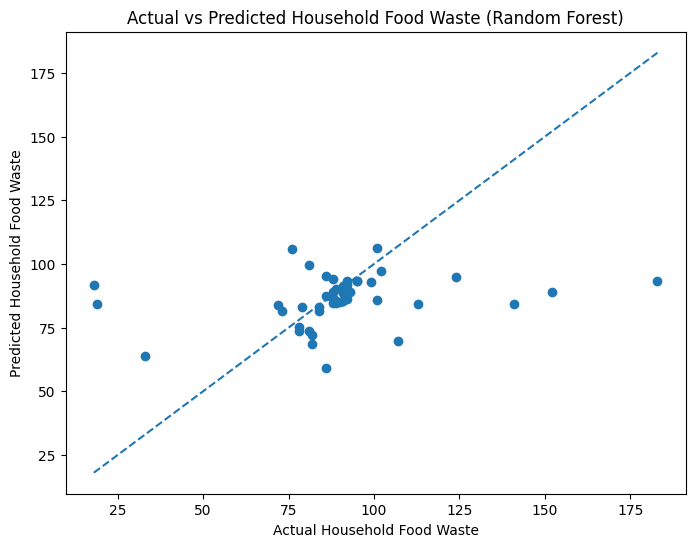

In [ ]:
# Step 19: Visualize the model performance
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Household Food Waste")
plt.ylabel("Predicted Household Food Waste")
plt.title("Actual vs Predicted Household Food Waste (Random Forest)")


# Save as PNG
plt.savefig(
    "actual_vs_predicted_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**MODEL EVALUATION**</br>
The Actual vs Predicted scatter plot indicates that the Random Forest model captured general trends in household food waste across countries.</br> 
Predictions for countries with average food waste levels were relatively accurate, while countries with exceptionally high or low food waste exhibited larger prediction errors.</br></br>
**INTERPRETATION**</br>
The model tended to produce predictions concentrated around the global average range, suggesting that the available explanatory variables were insufficient to fully explain extreme food waste behaviour.</br>
This finding is consistent with the relatively low R² value and indicates that additional behavioural, cultural, policy, and food consumption variables may be required to improve predictive performance.</br></br>
**CONCLUSION**</br>
Despite its limitations, the Random Forest model outperformed both the Baseline and Linear Regression models and was therefore selected as the final predictive model for this study.</br>

### <font color = green> **ONLINE DEMO TOOL**</br></font>